In [1]:
import numpy as np
import pandas as pd
import glob, os, subprocess, vcf, pysam, shutil, sparse, yaml, sys, pickle, itertools
from Bio import Entrez, Seq, SeqIO, SeqUtils
import scipy.stats as st
import evcouplings

# utils files are in a separate folder
sys.path.append("utils")
from saliency_utils import *
from inSilicoMut_utils import *
from analysis_utils import *
from data_utils import *

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")

BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
output_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# full_data = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
# drug_gene_mapping = pd.read_csv("~/who-analysis/data/drug_gene_mapping.csv")

# CETR_isolate_metadata = pd.read_csv("../data_cleaning/CETR_isolate_details.csv")
# isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
# print(set(h37Rv_genes.Symbol).symmetric_difference(h37Rv_full.query("Feature=='CDS'").Name))

amino_acid_biophysical_properties = pd.read_csv("./data_processing/protein_seqs/biophysical_properties_AA.csv", index_col=[0])

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Nov2024_Tier1.csv")
cc_df_who = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

isolates_who_catalog_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv")

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

df_MIC_ML = pd.read_csv("./MIC_data/MIC_ML.csv")
df_cryptic = pd.read_csv("./MIC_data/CRyPTIC_normalized.csv")

df_samples_geno = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
# df_samples_geno['log_F2'] = np.log2(df_samples_geno['F2'])

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

df_WHO_catalog = pd.read_csv("./MIC_data/2023_WHO_catalog_MIC.csv")
drugs_lst = ['EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)

In [14]:
df_run = df_samples_geno.query("DB_OF_ORIGIN != 'TRUST'")[['ROLLINGDB_ID', 'ROLLINGDB_ID']]
df_run.columns = ['ROLLINGDB_ID', 'RUN']
df_run['FQ'] = 0

In [16]:
df_run[['ROLLINGDB_ID', 'RUN']] = df_run[['ROLLINGDB_ID', 'RUN']].astype(str)

In [20]:
df_run.query("ROLLINGDB_ID=='SAMEA5569694'").to_csv("/home/sak0914/Mtb_Megapipe/samples_for_WHO_pred.tsv", sep='\t', header=None, index=False)

In [12]:
pd.read_csv("/home/sak0914/Mtb_Megapipe/samples_for_WHO_pred.tsv", sep='\t', header=None)

,0,1,2
0,20542,20542,0


In [24]:
ETO_R_variants_no_GR = who_variants.loc[who_variants['INITIAL CONFIDENCE GRADING'].isin(['1) Assoc w R', '2) Assoc w R - Interim'])].query("drug=='Ethionamide'").variant.unique()
len(ETO_R_variants_no_GR)

24

In [22]:
df_ETO = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv")

In [38]:
df_resistance_pred = pd.concat([isolate_variants.query("ROLLINGDB_ID in @df_ETO.ROLLINGDB_ID & variant in @ETO_R_variants_no_GR & AF > 0.75"),
           isolate_variants.loc[pd.isnull(isolate_variants['AF'])].query("ROLLINGDB_ID in @df_ETO.ROLLINGDB_ID & variant in @ETO_R_variants_no_GR")
          ])

In [40]:
df_ETO_test = df_ETO.query("category=='test_set'")

In [42]:
df_ETO_test['y_pred'] = df_ETO_test['ROLLINGDB_ID'].isin(df_resistance_pred.ROLLINGDB_ID).astype(int)

In [43]:
df_ETO_test.y_pred.value_counts()

y_pred
0    1664
1     430
Name: count, dtype: int64

In [50]:
df_ETO_test[['ROLLINGDB_ID', 'Binary', 'y_pred', 'Span_CC']].rename(columns={'Binary': 'y_test'}).to_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/ETO/catalog_test_predictions_V2_no_GR.csv", index=False)

In [53]:
df_resistance_pred.confidence.unique()

array(['1) Assoc w R', '2) Assoc w R - Interim'], dtype=object)

In [2]:
shandu_samples = pd.read_csv("~/shandu_binosnp_data.csv")

In [3]:
shandu_samples

,tag,accession_number,fastq1,fastq2
0,Mix-SR1a-rpoB531-10,ERS4339022,Mix-SR1a-rpoB531-10_lib5342_nextseq_n0042_151b...,Mix-SR1a-rpoB531-10_lib5342_nextseq_n0042_151b...
1,Mix-SR1a-rpoB531-1,ERS4339020,Mix-SR1a-rpoB531-1_lib5344_nextseq_n0042_151bp...,Mix-SR1a-rpoB531-1_lib5344_nextseq_n0042_151bp...
2,Mix-SR1a-rpoB531-5,ERS4339021,Mix-SR1a-rpoB531-5_lib5343_nextseq_n0042_151bp...,Mix-SR1a-rpoB531-5_lib5343_nextseq_n0042_151bp...
3,Mix-SR4k-rpoB526-10,ERS4339025,Mix-SR4k-rpoB526-10_lib5339_nextseq_n0042_151b...,Mix-SR4k-rpoB526-10_lib5339_nextseq_n0042_151b...
4,Mix-SR4k-rpoB526-1,ERS4339023,Mix-SR4k-rpoB526-1_lib5341_nextseq_n0042_151bp...,Mix-SR4k-rpoB526-1_lib5341_nextseq_n0042_151bp...
5,Mix-SR4k-rpoB526-5,ERS4339024,Mix-SR4k-rpoB526-5_lib5340_nextseq_n0042_151bp...,Mix-SR4k-rpoB526-5_lib5340_nextseq_n0042_151bp...


In [5]:
for sample in shandu_samples.tag.values:
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance/{sample}_pred_AF_thresh_25.csv"):
        print(sample)

Mix-SR1a-rpoB531-10
Mix-SR1a-rpoB531-1
Mix-SR1a-rpoB531-5
Mix-SR4k-rpoB526-10
Mix-SR4k-rpoB526-1
Mix-SR4k-rpoB526-5


In [23]:
len(df_depth.loc[df_depth[2] >= 20]) / len(df_depth)

0.9898078490646787

In [8]:
df = pd.DataFrame({'A': shandu_samples['tag'], 'B': shandu_samples['tag'], 'FQ': 0})

In [10]:
df.to_csv("../Mtb_Megapipe/shandu_samples.tsv", sep='\t', header=None, index=False)

In [ ]:
os.mkdir(f"/n/scratch/users/s/sak0914/")

In [7]:
# for i, row in shandu_samples.iterrows():
#     # os.mkdir(f"/n/scratch/users/s/sak0914/temp_FASTQ/{sample}")

#     sample = row['tag']
#     FQ1 = row['fastq1']
#     FQ2 = row['fastq2']

#     shutil.copy(f"/n/data1/hms/dbmi/farhat/shandu/projects/mixed_calls/benchmarking/comprehensive/binosnp_data/fastq/{FQ1}", f"/n/scratch/users/s/sak0914/temp_FASTQ/{sample}/{sample}_R1.fastq.gz")
#     shutil.copy(f"/n/data1/hms/dbmi/farhat/shandu/projects/mixed_calls/benchmarking/comprehensive/binosnp_data/fastq/{FQ2}", f"/n/scratch/users/s/sak0914/temp_FASTQ/{sample}/{sample}_R2.fastq.gz")

['Mix-SR1a-rpoB531-10_lib5342_nextseq_n0042_151bp_R1.fastq.gz',
 'Mix-SR1a-rpoB531-10_lib5342_nextseq_n0042_151bp_R2.fastq.gz',
 'Mix-SR1a-rpoB531-1_lib5344_nextseq_n0042_151bp_R1.fastq.gz',
 'Mix-SR1a-rpoB531-1_lib5344_nextseq_n0042_151bp_R2.fastq.gz',
 'Mix-SR1a-rpoB531-5_lib5343_nextseq_n0042_151bp_R1.fastq.gz',
 'Mix-SR1a-rpoB531-5_lib5343_nextseq_n0042_151bp_R2.fastq.gz',
 'Mix-SR4k-rpoB526-10_lib5339_nextseq_n0042_151bp_R1.fastq.gz',
 'Mix-SR4k-rpoB526-10_lib5339_nextseq_n0042_151bp_R2.fastq.gz',
 'Mix-SR4k-rpoB526-1_lib5341_nextseq_n0042_151bp_R1.fastq.gz',
 'Mix-SR4k-rpoB526-1_lib5341_nextseq_n0042_151bp_R2.fastq.gz',
 'Mix-SR4k-rpoB526-5_lib5340_nextseq_n0042_151bp_R1.fastq.gz',
 'Mix-SR4k-rpoB526-5_lib5340_nextseq_n0042_151bp_R2.fastq.gz']

In [6]:
MIC_ML_sources = df_MIC_ML.DB_OF_ORIGIN.unique()

In [55]:
all_internal_samples = np.concatenate([isolate_metadata.loc[pd.isnull(isolate_metadata['RUN'])].ROLLINGDB_ID.values,
                                       isolate_metadata.query("DB_OF_ORIGIN in @MIC_ML_sources").dropna(subset='RUN').ROLLINGDB_ID.values
                                      ])

print(len(all_internal_samples))

all_internal_samples = [sample for sample in all_internal_samples if os.path.isfile(f"{genomic_data_dir}/{sample}/pilon/{sample}_variants.vcf") or os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/{sample}")]

print(len(all_internal_samples))

6950
3155


In [50]:
need_variant_calling_samples = []

for sample in all_internal_samples:

    if not os.path.isfile(f"{genomic_data_dir}/{sample}/pilon/{sample}_variants.vcf") and os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/{sample}"):
        need_variant_calling_samples.append(sample)

len(need_variant_calling_samples)

613

In [43]:
df_WHO_variants = extract_WHO_variant_annotations(all_internal_samples)

In [66]:
df_WHO_variants.query("variant=='ddn_p.Trp88'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID


In [69]:
isolate_variants.query("ROLLINGDB_ID=='SAMN40566417'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence


In [75]:
for isolate in search_isolates:

    print(isolate, df_WHO_variants.query("ROLLINGDB_ID==@isolate & confidence == '1) Assoc w R'").drug.values)

JPN-R2012-0057 ['Rifampicin' 'Amikacin' 'Capreomycin' 'Kanamycin' 'Ethionamide'
 'Isoniazid' 'Ethambutol' 'Streptomycin']
KOR-K2016-0081 []
KOR-K2016-0148 ['Rifampicin' 'Isoniazid' 'Ethionamide']
KOR-K2016-0149 ['Rifampicin' 'Isoniazid' 'Pyrazinamide' 'Ethambutol' 'Streptomycin']
SAMN41418323 []
SAMN28552987 []
SAMN40566417 ['Rifampicin' 'Isoniazid']


In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --locus ethA --predict
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --locus ethR --predict
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --locus fabG1-inhA --predict
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --locus mshA --predict

In [ ]:
SAMD00117782 is genotypically resistant to RIF, INH, ETO, EMB, and the aminoglycosides
SAMN40566417 is genotypically resistant to RIF and INH

Korean samples: 1 drug-susceptible, 1 RIF/INH/ETO, 1 RIF/INH/EMB/PZA/STM

In [81]:
JATA_MIC = pd.read_csv("~/MtbQuantCNN/MIC_data/MIC_ML/JATA_KIT_Japan_MIC.csv")

In [59]:
search_isolates = df_WHO_variants.query("variant=='ddn_p.Gly81Ser'").ROLLINGDB_ID.values

df_WHO_variants.query("variant=='ddn_p.Gly81Ser'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
52,3987084,G,A,PASS,3049.0,False,1.0,91.0,34.0,60.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,JPN-R2012-0057
29,3987084,G,A,PASS,2864.0,False,1.0,82.0,35.0,60.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,KOR-K2016-0081
33,3987084,G,A,PASS,4635.0,False,1.0,139.0,34.0,58.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,KOR-K2016-0148
34,3987084,G,A,PASS,4765.0,False,1.0,138.0,35.0,59.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,KOR-K2016-0149
38,3987084,G,A,PASS,3452.0,False,1.0,100.0,35.0,60.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,SAMN41418323
29,3987084,G,A,PASS,2974.0,False,1.0,86.0,35.0,59.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,SAMN28552987
34,3987084,G,A,PASS,2750.0,False,1.0,80.0,34.0,60.0,0.0,0.0,missense_variant,ddn,c.241G>A,p.Gly81Ser,ddn_p.Gly81Ser,Delamanid,3) Uncertain significance,SAMN40566417


In [58]:
df_lineages = extract_lineages(all_internal_samples)

In [60]:
df_lineages.query("ROLLINGDB_ID in @search_isolates")

,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,ROLLINGDB_ID,F2,Lineage
0,2.2.2,2.2.2,"beijing,canetti,mungi","asia_ancestral_1,lin2.2",NaN,JPN-R2012-0057,0.012322,2
0,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,KOR-K2016-0081,0.009131,2
0,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,KOR-K2016-0148,0.012099,2
0,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,KOR-K2016-0149,0.011187,2
0,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,SAMN41418323,0.014350,2
0,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,SAMN28552987,0.013076,2
0,2.2.2,2.2.2,"beijing,canetti,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,SAMN40566417,0.013083,2


In [57]:
def extract_lineages(samples_lst):

    df_add = []
    
    for sample in samples_lst:

        if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/lineage/fast_lineage_caller_output.txt"):
        
            F2 = float(pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/lineage/F2_Coll2014.txt", sep='\t', header=None)[0].values[0])
    
            df_flc = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/lineage/fast_lineage_caller_output.txt", sep='\t')
    
            df_flc['ROLLINGDB_ID'] = df_flc['Isolate'].str.split('_').str[0]
            
            for col in df_flc.columns:
                if col not in ['Isolate', 'ROLLINGDB_ID']:
                    df_flc.rename(columns={col: col.capitalize()}, inplace=True)
    
            df_flc['Coll2014'] = df_flc['Coll2014'].str.replace('lineage', '')
            df_flc['F2'] = F2
    
            if df_flc['Coll2014'].values[0][0].isnumeric():
                df_flc['Lineage'] = df_flc['Coll2014'].values[0][0]
            else:
                df_flc['Lineage'] = df_flc['Coll2014'].values[0]
            
            df_add.append(df_flc)
    
    df_add = pd.concat(df_add)
    del df_add['Isolate']
    
    return df_add

In [40]:
len(all_internal_samples)

2542

In [42]:
def extract_WHO_variant_annotations(samples_lst):

    df_add = []
    
    for sample in samples_lst:

        fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance/{sample}_variants_annot.tsv"

        if os.path.isfile(fName):
        
            df_pred = pd.read_csv(fName, sep='\t')
            df_pred['ROLLINGDB_ID'] = sample
            df_add.append(df_pred)
    
    df_add = pd.concat(df_add)
    
    return df_add


In [37]:
pd.DataFrame({'A': samples_to_get_WHO_pred, 'B': samples_to_get_WHO_pred, 'FQ': 0}).to_csv("/home/sak0914/Mtb_Megapipe/redo_WHO_preds.tsv", sep='\t', header=None, index=False)

In [29]:
isolate_metadata.dropna(subset='OtherNames').query("OtherNames.str.contains('Peru')")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
3883,SAMN05919558,SAMN05919558,NaN,Peru4037,cetr,NaN,Peru,Peru,1.0,1.0,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,Peru4037
3884,SAMN05919560,SAMN05919560,NaN,Peru4039,cetr,NaN,Peru,Peru,1.0,1.0,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,Peru4039
44043,SAMN05825228,SAMN05825228,SRS20795585,SRR28394024,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 8:23,3/20/24 7:45,SRR28394024,1.0,"Peru4700,01-R0904"
44044,SAMN05830624,SAMN05830624,SRS20795587,SRR28394023,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 8:23,3/20/24 7:45,SRR28394023,1.0,"Peru4701,01-R1463"
44045,SAMN05830709,SAMN05830709,SRS20795589,SRR28394022,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 8:23,3/20/24 7:44,SRR28394022,1.0,"Peru4702,02-R1447"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46828,SAMN06094116,SAMN06094116,SRS20794722,SRR28393261,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 7:25,3/20/24 6:30,SRR28393261,1.0,"Peru5449,02-R0967"
46829,SAMN06094117,SAMN06094117,SRS20794723,SRR28393260,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 7:25,3/20/24 6:30,SRR28393260,1.0,"Peru5450,97-R337"
46830,SAMN06094120,SAMN06094120,SRS20794724,SRR28393259,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 7:25,3/20/24 6:30,SRR28393259,1.0,"Peru5453,99-02018"
46831,SAMN06094121,SAMN06094121,SRS20794725,SRR28393258,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 7:25,3/20/24 6:29,SRR28393258,1.0,"Peru5454,01-R0379"


In [136]:
isolate_metadata.query("ROLLINGDB_ID=='IDR1600034869'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames


In [138]:
isolate_metadata.query("ROLLINGDB_ID.str.contains('IDR1600034869')")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames


In [139]:
isolate_metadata.dropna(subset='OtherNames').query("OtherNames.str.contains('IDR1600034869')")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
58029,SAMN41418323,SAMN41418323,SRS21317971,SRR29053198,Wadsworth,2016,USA,USA,1.0,1.0,ILLUMINA,Illumina HiSeq 2000,Mycobacterium tuberculosis,1773.0,2024-05-18 01:42:50,2024-05-18 00:31:58,SRR29053198,1.0,IDR1600034869


In [130]:
for drug in ['ETO', 'INH', 'EMB']:
    kwargs = yaml.safe_load(open(f"./config_files/config_{drug.lower()}.yaml"))

    for locus in kwargs['tier1_loci']:
        print(f"python3 analysis/addl_data_predictions_regression.py -c config_files/config_{drug.lower()}.yaml --amino-acid --lineage --insilico-muts --locus {locus} --predict")
        print(f"python3 analysis/addl_data_predictions_regression.py -c config_files/config_{drug.lower()}.yaml --amino-acid --insilico-muts --locus {locus} --predict")

python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --lineage --insilico-muts --locus fabG1-inhA --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --insilico-muts --locus fabG1-inhA --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --lineage --insilico-muts --locus ethA --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --insilico-muts --locus ethA --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --lineage --insilico-muts --locus ethR --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --insilico-muts --locus ethR --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_eto.yaml --amino-acid --lineage --insilico-muts --locus mshA

In [133]:
for drug in ['INH', 'EMB']:
    print(f"python3 analysis/addl_data_predictions_regression.py -c config_files/config_{drug.lower()}.yaml --amino-acid --lineage --TRUST --predict")
    print(f"python3 analysis/addl_data_predictions_regression.py -c config_files/config_{drug.lower()}.yaml --amino-acid --TRUST --predict")

python3 analysis/addl_data_predictions_regression.py -c config_files/config_inh.yaml --amino-acid --lineage --TRUST --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_inh.yaml --amino-acid --TRUST --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_emb.yaml --amino-acid --lineage --TRUST --predict
python3 analysis/addl_data_predictions_regression.py -c config_files/config_emb.yaml --amino-acid --TRUST --predict


In [6]:
samples = [os.path.basename(fName).split('_')[0] for fName in fNames_with_variants]

In [56]:
df_PZA[['ROLLINGDB_ID']].to_csv("./PZA_samples.txt", sep='\t', header=None, index=False)

In [ ]:
# Read the TSV file line by line, skiping the header. IFS sets the field separator. Here, it is tab
while IFS=$'\t', read -r sample
do

    fName="/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/$sample/WHO_resistance/${sample}_variants_combinedCodons.eff.vcf"
    echo $fName

    bcftools filter -i "((POS >= 1389357 & POS <= 1393052) | (POS >= 2894893 & POS <= 2897003))" $fName | SnpSift extractFields '-' POS REF ALT FILTER QUAL AF DP BQ MQ ANN ANN[*].GENE ANN[*].EFFECT ANN[*].HGVS_C ANN[*].HGVS_P -e "" > "/n/scratch/users/s/sak0914/PZA_addl_variants/$sample.tsv"

    # exit

done < "./PZA_samples.txt"

In [70]:
df_variants = []

for fName in glob.glob("/n/scratch/users/s/sak0914/PZA_addl_variants/*.tsv"):

    df = pd.read_csv(fName, sep='\t')
    df['ROLLINGDB_ID'] = os.path.basename(fName).split('.')[0]
    df_variants.append(df)

df_variants = pd.concat(df_variants)

df_variants.columns = df_variants.columns.str.replace('ANN[*].', '')
df_variants['variant'] = df_variants['GENE'] + '_' + df_variants['HGVS_P']

In [71]:
df_variants.query("GENE=='Rv2571c'").EFFECT.value_counts()

EFFECT
missense_variant      45
frameshift_variant     8
synonymous_variant     4
stop_gained            3
Name: count, dtype: int64

In [72]:
df_variants.query("GENE=='Rv1248c'").EFFECT.value_counts()

EFFECT
synonymous_variant    497
missense_variant      404
Name: count, dtype: int64

In [74]:
df_variants.query("GENE=='Rv1248c' & EFFECT == 'missense_variant'").variant.value_counts()

variant
Rv1248c_p.Ser842Tyr     299
Rv1248c_p.Val764Met      90
Rv1248c_p.Ala61Thr        4
Rv1248c_p.Pro188Arg       2
Rv1248c_p.Asp533Asn       2
Rv1248c_p.Thr1072Met      2
Rv1248c_p.Pro762Arg       1
Rv1248c_p.Lys879Thr       1
Rv1248c_p.Val503Ile       1
Rv1248c_p.Ala665Thr       1
Rv1248c_p.Met645Val       1
Name: count, dtype: int64

In [12]:
isolate_variants.query("GENE=='sigE'").EFFECT.value_counts()

EFFECT
synonymous_variant    546
missense_variant      266
frameshift_variant      1
Name: count, dtype: int64

In [18]:
isolate_variants.query("GENE=='sigE' & EFFECT=='missense_variant'").variant.unique()

array(['sigE_p.Arg8Trp', 'sigE_p.Leu102Phe', 'sigE_p.Ile214Val',
       'sigE_p.Leu35Phe', 'sigE_p.Asp34Asn', 'sigE_p.Pro171Ser',
       'sigE_p.Val251Ile', 'sigE_p.Asp205Gly', 'sigE_p.Asp93Asn',
       'sigE_p.Ala79Val', 'sigE_p.Ser44Asn', 'sigE_p.Pro167Ser',
       'sigE_p.Pro244His', 'sigE_p.Asp179Asn', 'sigE_p.Asp64Gly',
       'sigE_p.Cys204Arg', 'sigE_p.Arg122Gln', 'sigE_p.Ser49Pro',
       'sigE_p.Asp20Tyr', 'sigE_p.Pro194Ser', 'sigE_p.Gly76Arg',
       'sigE_p.His107Tyr', 'sigE_p.Gly215Ala', 'sigE_p.Leu222Phe',
       'sigE_p.Phe144Leu', 'sigE_p.Thr80Ala', 'sigE_p.Thr116Ala',
       'sigE_p.Pro255Ser', 'sigE_p.Arg8Gln', 'sigE_p.Ser192Leu',
       'sigE_p.Asp169Asn', 'sigE_p.Ile229Val'], dtype=object)

In [15]:
df_PZA = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/data_for_model.csv")

In [75]:
df_variants.query("GENE=='Rv1248c' & EFFECT in ['missense_variant']").merge(df_PZA[['ROLLINGDB_ID', 'Lineage', 'PZA_lower_bound', 'PZA_upper_bound', 'category']]).query("ROLLINGDB_ID not in @variants_with_pncA_LoF")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,ANN,GENE,EFFECT,HGVS_C,HGVS_P,ROLLINGDB_ID,variant,Lineage,PZA_lower_bound,PZA_upper_bound,category
0,1390763,C,T,PASS,3769.0,1.00,109,35,60,T|missense_variant|MODERATE|Rv1248c|Rv1248c|tr...,Rv1248c,missense_variant,c.2290G>A,p.Val764Met,SAMEA3392628,Rv1248c_p.Val764Met,2,0.0,10.0,train_set
1,1390768,G,C,PASS,3810.0,1.00,117,33,60,C|missense_variant|MODERATE|Rv1248c|Rv1248c|tr...,Rv1248c,missense_variant,c.2285C>G,p.Pro762Arg,SAMEA3392628,Rv1248c_p.Pro762Arg,2,0.0,10.0,train_set
2,1390763,C,T,PASS,1558.0,0.96,53,35,60,T|missense_variant|MODERATE|Rv1248c|Rv1248c|tr...,Rv1248c,missense_variant,c.2290G>A,p.Val764Met,SAMEA3392667,Rv1248c_p.Val764Met,2,20.0,50.0,validation_set
3,1390527,CG,GT,PASS,1564.0,1.00,45,34,60,GT|missense_variant|MODERATE|Rv1248c|Rv1248c|t...,Rv1248c,missense_variant,c.2525_2526delCGinsAC,p.Ser842Tyr,SAMEA3400995,Rv1248c_p.Ser842Tyr,4,25.0,50.0,train_set
4,1390763,C,T,PASS,2865.0,1.00,85,34,60,T|missense_variant|MODERATE|Rv1248c|Rv1248c|tr...,Rv1248c,missense_variant,c.2290G>A,p.Val764Met,SAMEA3401009,Rv1248c_p.Val764Met,2,100.0,300.0,train_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,1390527,CG,GT,PASS,2540.0,1.00,65,39,60,GT|missense_variant|MODERATE|Rv1248c|Rv1248c|t...,Rv1248c,missense_variant,c.2525_2526delCGinsAC,p.Ser842Tyr,SAMN38210021,Rv1248c_p.Ser842Tyr,4,0.0,25.0,test_set
400,1390527,CG,GT,PASS,13416.0,1.00,347,39,60,GT|missense_variant|MODERATE|Rv1248c|Rv1248c|t...,Rv1248c,missense_variant,c.2525_2526delCGinsAC,p.Ser842Tyr,SAMN38210027,Rv1248c_p.Ser842Tyr,4,100.0,120.0,train_set
401,1390527,CG,GT,PASS,2838.0,1.00,74,38,60,GT|missense_variant|MODERATE|Rv1248c|Rv1248c|t...,Rv1248c,missense_variant,c.2525_2526delCGinsAC,p.Ser842Tyr,SAMN38210033,Rv1248c_p.Ser842Tyr,4,0.0,25.0,train_set
402,1390763,C,T,PASS,2853.0,1.00,73,39,60,T|missense_variant|MODERATE|Rv1248c|Rv1248c|tr...,Rv1248c,missense_variant,c.2290G>A,p.Val764Met,SAMN38210043,Rv1248c_p.Val764Met,2,0.0,25.0,train_set


In [76]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA3401009'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
82951,SAMEA3401009,7362,G,C,PASS,4028.0,False,1.00,119.0,34.0,60.0,0.0,0.0,missense_variant,gyrA,c.61G>C,p.Glu21Gln,gyrA_p.Glu21Gln,Levofloxacin,5) Not assoc w R
82952,SAMEA3401009,7362,G,C,PASS,4028.0,False,1.00,119.0,34.0,60.0,0.0,0.0,missense_variant,gyrA,c.61G>C,p.Glu21Gln,gyrA_p.Glu21Gln,Moxifloxacin,5) Not assoc w R
82953,SAMEA3401009,7585,G,C,PASS,3470.0,False,1.00,102.0,34.0,60.0,0.0,0.0,missense_variant,gyrA,c.284G>C,p.Ser95Thr,gyrA_p.Ser95Thr,Levofloxacin,5) Not assoc w R
82954,SAMEA3401009,7585,G,C,PASS,3470.0,False,1.00,102.0,34.0,60.0,0.0,0.0,missense_variant,gyrA,c.284G>C,p.Ser95Thr,gyrA_p.Ser95Thr,Moxifloxacin,5) Not assoc w R
82955,SAMEA3401009,9304,G,A,PASS,2782.0,False,1.00,88.0,32.0,60.0,0.0,0.0,missense_variant,gyrA,c.2003G>A,p.Gly668Asp,gyrA_p.Gly668Asp,Levofloxacin,5) Not assoc w R
82956,SAMEA3401009,9304,G,A,PASS,2782.0,False,1.00,88.0,32.0,60.0,0.0,0.0,missense_variant,gyrA,c.2003G>A,p.Gly668Asp,gyrA_p.Gly668Asp,Moxifloxacin,5) Not assoc w R
82957,SAMEA3401009,491742,T,C,PASS,3651.0,False,1.00,107.0,34.0,60.0,0.0,0.0,synonymous_variant,fgd1,c.960T>C,p.Phe320Phe,fgd1_c.960T>C,Clofazimine,5) Not assoc w R
82958,SAMEA3401009,491742,T,C,PASS,3651.0,False,1.00,107.0,34.0,60.0,0.0,0.0,synonymous_variant,fgd1,c.960T>C,p.Phe320Phe,fgd1_c.960T>C,Delamanid,4) Not assoc w R - Interim
82959,SAMEA3401009,575907,C,T,PASS,1476.0,False,1.00,49.0,30.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R
82960,SAMEA3401009,575907,C,T,PASS,1476.0,False,1.00,49.0,30.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Isoniazid,5) Not assoc w R


In [80]:
pd.read_csv("~/who-analysis/data/drug_gene_mapping.csv").query("Drug=='Pyrazinamide'")

,Drug,Gene,Tier
97,Pyrazinamide,Rv3236c,2
98,Pyrazinamide,Rv1258c,2
99,Pyrazinamide,rpsA,2
100,Pyrazinamide,sigE,2
101,Pyrazinamide,PPE35,2
102,Pyrazinamide,clpC1,1
103,Pyrazinamide,panD,1
104,Pyrazinamide,pncA,1


In [51]:
variants_with_pncA_LoF = isolate_variants.query("GENE=='pncA' & EFFECT.str.contains('|'.join(['frameshift', 'stop_gained', 'start_lost', 'ablation'])) & ROLLINGDB_ID in @df_PZA.ROLLINGDB_ID").ROLLINGDB_ID.unique()

len(variants_with_pncA_LoF)

73

In [53]:
df_variants.query("GENE=='Rv2571c' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_PZA[['ROLLINGDB_ID', 'Lineage', 'PZA_lower_bound', 'PZA_upper_bound', 'category']])

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,ANN,GENE,EFFECT,HGVS_C,HGVS_P,ROLLINGDB_ID,variant,Lineage,PZA_lower_bound,PZA_upper_bound,category
0,2894958,G,A,PASS,1474.0,0.98,46,35,60,A|stop_gained|HIGH|Rv2571c|Rv2571c|transcript|...,Rv2571c,stop_gained,c.1003C>T,p.Gln335*,SAMEA3416726,Rv2571c_p.Gln335*,2,0.0,10.0,train_set
1,2895520,G,GA,PASS,2764.0,1.03,69,40,59,GA|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.440dupT,p.Glu148fs,SAMN05916392,Rv2571c_p.Glu148fs,2,25.0,50.0,train_set
2,2895318,G,A,PASS,7698.0,1.00,192,40,60,A|stop_gained|HIGH|Rv2571c|Rv2571c|transcript|...,Rv2571c,stop_gained,c.643C>T,p.Arg215*,SAMN05916438,Rv2571c_p.Arg215*,2,0.0,25.0,validation_set
3,2895233,A,AC,PASS,2646.0,0.93,68,39,60,AC|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.727dupG,p.Val243fs,SAMN05918588,Rv2571c_p.Val243fs,4,0.0,25.0,train_set
4,2895233,A,AC,PASS,4614.0,0.96,128,36,60,AC|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.727dupG,p.Val243fs,SAMN05918704,Rv2571c_p.Val243fs,4,0.0,25.0,test_set
5,2895233,A,AC,PASS,2725.0,0.91,74,37,60,AC|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.727dupG,p.Val243fs,SAMN05918774,Rv2571c_p.Val243fs,4,175.0,200.0,train_set
6,2895940,G,GA,PASS,4440.0,1.00,122,36,60,GA|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.20dupT,p.Arg8fs,SAMN06010251,Rv2571c_p.Arg8fs,4,0.0,25.0,train_set
7,2895080,G,GT,PASS,9925.0,1.01,305,33,60,GT|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.880dupA,p.Thr294fs,SAMN06010353,Rv2571c_p.Thr294fs,4,0.0,25.0,train_set
8,2895233,A,AC,PASS,1432.0,1.02,44,33,60,AC|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.727dupG,p.Val243fs,SAMN06010359,Rv2571c_p.Val243fs,2,0.0,25.0,test_set
9,2895233,A,AC,PASS,6600.0,0.88,175,38,60,AC|frameshift_variant|HIGH|Rv2571c|Rv2571c|tra...,Rv2571c,frameshift_variant,c.727dupG,p.Val243fs,SAMN06094101,Rv2571c_p.Val243fs,4,100.0,120.0,train_set


In [52]:
df_variants.query("ROLLINGDB_ID in @variants_with_pncA_LoF")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,ANN,GENE,EFFECT,HGVS_C,HGVS_P,ROLLINGDB_ID,variant
0,2895473,A,G,PASS,1857.0,1.00,54,34,60,G|missense_variant|MODERATE|Rv2571c|Rv2571c|tr...,Rv2571c,missense_variant,c.488T>C,p.Phe163Ser,SAMEA3404190,Rv2571c_p.Phe163Ser
0,2895851,G,C,PASS,4277.0,1.00,118,36,60,C|missense_variant|MODERATE|Rv2571c|Rv2571c|tr...,Rv2571c,missense_variant,c.110C>G,p.Ala37Gly,SAMEA3416725,Rv2571c_p.Ala37Gly
0,2895768,T,C,PASS,16892.0,1.00,464,37,60,C|missense_variant|MODERATE|Rv2571c|Rv2571c|tr...,Rv2571c,missense_variant,c.193A>G,p.Asn65Asp,SAMN05916280,Rv2571c_p.Asn65Asp
0,2895028,G,T,PASS,3089.0,0.97,96,37,60,T|synonymous_variant|LOW|Rv2571c|Rv2571c|trans...,Rv2571c,synonymous_variant,c.933C>A,p.Ala311Ala,SAMN05916334,Rv2571c_p.Ala311Ala


In [2]:
df_LFX = pd.read_csv(f"{data_dir}/LFX/data_for_model.csv")
df_MXF = pd.read_csv(f"{data_dir}/MXF/data_for_model.csv")

In [3]:
LFX_train_isolates = df_LFX.query("category=='train_set'").ROLLINGDB_ID.unique()
MXF_train_isolates = df_MXF.query("category=='train_set'").ROLLINGDB_ID.unique()

LFX_low_freq_variants = isolates_who_catalog_variants.query("ROLLINGDB_ID in @LFX_train_isolates & AF > 0.25 & AF <= 0.75 & drug=='Levofloxacin' & GENE in ['gyrA', 'gyrB']")
MXF_low_freq_variants = isolates_who_catalog_variants.query("ROLLINGDB_ID in @MXF_train_isolates & AF > 0.25 & AF <= 0.75 & drug=='Moxifloxacin' & GENE in ['gyrA', 'gyrB']")

LFX_low_freq_variants.ROLLINGDB_ID.nunique(), len(LFX_train_isolates), MXF_low_freq_variants.ROLLINGDB_ID.nunique(), len(MXF_train_isolates)

(57, 5546, 95, 6700)

In [4]:
57/5546, 95/6700

(0.010277677605481428, 0.014179104477611941)

In [5]:
LFX_low_freq_variants.variant.nunique(), MXF_low_freq_variants.variant.nunique()

(25, 25)

In [6]:
MXF_low_freq_variants.variant.value_counts()

variant
gyrA_p.Asp94Gly     31
gyrA_p.Ala90Val     29
gyrA_p.Ser91Pro     14
gyrA_p.Asp94Ala     11
gyrA_p.Asp94Tyr     10
gyrB_p.Glu501Asp     9
gyrA_p.Asp89Asn      4
gyrA_p.Asp94Asn      3
gyrA_p.Gly88Ala      2
gyrB_p.Thr500Asn     2
gyrB_p.Asn499Lys     1
gyrA_p.Gly88Cys      1
gyrB_p.Arg446His     1
gyrA_p.Ala288Asp     1
gyrA_c.333C>T        1
gyrB_p.Asn499Thr     1
gyrB_p.Thr500Ala     1
gyrA_p.Ala126Ser     1
gyrA_p.Asp94His      1
gyrB_p.Ser447Tyr     1
gyrB_p.Ala504Val     1
gyrB_p.Glu501Val     1
gyrA_p.Ala384Val     1
gyrA_p.Ala74Ser      1
gyrB_p.Asp461Ala     1
Name: count, dtype: int64

In [5]:
LFX_low_freq_variants

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
159960,SAMEA104362277,7570,C,T,Amb,567.0,False,0.29,100.0,38.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R
162737,SAMEA104362356,7581,G,T,Amb,257.0,False,0.27,88.0,38.0,60.0,0.0,0.0,missense_variant,gyrA,c.280G>T,p.Asp94Tyr,gyrA_p.Asp94Tyr,Levofloxacin,1) Assoc w R
168382,SAMEA1101499,7582,A,C,Amb,512.0,False,0.34,43.0,33.0,60.0,0.0,0.0,missense_variant,gyrA,c.281A>C,p.Asp94Ala,gyrA_p.Asp94Ala,Levofloxacin,1) Assoc w R
171471,SAMEA1101589,7570,C,T,Amb,2766.0,False,0.45,101.0,35.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R
171473,SAMEA1101589,7582,A,C,Amb,3050.0,False,0.52,105.0,32.0,60.0,0.0,0.0,missense_variant,gyrA,c.281A>C,p.Asp94Ala,gyrA_p.Asp94Ala,Levofloxacin,1) Assoc w R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671939,SAMEA8741600,6738,C,A,Amb,2417.0,False,0.53,71.0,38.0,60.0,0.0,0.0,missense_variant,gyrB,c.1499C>A,p.Thr500Asn,gyrB_p.Thr500Asn,Levofloxacin,3) Uncertain significance
726344,SAMEA7545834,6579,C,A,Amb,2888.0,False,0.43,113.0,35.0,60.0,0.0,0.0,missense_variant,gyrB,c.1340C>A,p.Ser447Tyr,gyrB_p.Ser447Tyr,Levofloxacin,3) Uncertain significance
726346,SAMEA7545834,6734,A,G,Amb,1000.0,False,0.31,129.0,35.0,60.0,0.0,0.0,missense_variant,gyrB,c.1495A>G,p.Asn499Asp,gyrB_p.Asn499Asp,Levofloxacin,1) Assoc w R
752363,SAMN18498640,7572,T,C,Amb,1462.0,False,0.51,46.0,33.0,59.0,0.0,0.0,missense_variant,gyrA,c.271T>C,p.Ser91Pro,gyrA_p.Ser91Pro,Levofloxacin,1) Assoc w R


In [97]:
def extract_TRUST_WHO_variant_annotations(df, name_col):

    df_add = []
    
    for sample in df[name_col].unique():

        fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sample}/WHO_resistance/{sample}_variants_annot.tsv"

        if os.path.isfile(fName):
        
            df_pred = pd.read_csv(fName, sep='\t')
            df_pred[name_col] = sample
            df_add.append(df_pred)
    
    df_add = pd.concat(df_add)
    
    return df_add

In [98]:
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")

In [99]:
df_TRUST_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")
df_full = pd.read_csv("./analysis/TRUST/raw_data/20240826_metadata_MIC_method_updates.csv")

In [100]:
# df_TRUST_WGS[['pid', 'SampleID']].merge(df_full_WGS[['pid', 'Original_ID', 'SampleID']])

In [33]:
missing_IDs = list(set(df_TRUST_WGS.SampleID) - set(df_full_WGS.SampleID))

In [129]:
df_save = df_TRUST_variants.query("drug=='Isoniazid'").merge(df_full_WGS[['pid', 'Original_ID', 'SampleID']], on='SampleID').set_index(['pid', 'Original_ID', 'SampleID']).reset_index()

df_save = df_save[['pid', 'Original_ID', 'SampleID', 'GENE', 'variant', 'confidence']]

df_save['specimen_time_point'] = df_save['Original_ID'].str.replace('m5', '13').str.replace('A', '').str.split('-').str[-1].astype(int)

df_save.loc[df_save['confidence'].isin(['1) Assoc w R', '2) Assoc w R - Interim']), 'resistance_assoc'] = 1
df_save.loc[~df_save['confidence'].isin(['1) Assoc w R', '2) Assoc w R - Interim']), 'resistance_assoc'] = 0
df_save.loc[pd.isnull(df_save['confidence']), 'resistance_assoc'] = np.nan

df_save.to_csv("INH_variants_all_sequences.csv", index=False)

In [130]:
df_save.pid.nunique(), df_save.SampleID.nunique()

(314, 538)

In [136]:
df_old.dropna(subset='variant').pid.nunique(), df_old.dropna(subset='variant').SampleID.nunique()

(182, 182)

In [131]:
df_old = pd.read_csv("INH_variants_TRUST.csv")

In [125]:
df_save.specimen_time_point.unique()

array([ 1,  6,  8,  7,  5,  2,  4,  9, 11, 13,  3])

In [126]:
df_save.query("specimen_time_point==13")

,pid,Original_ID,SampleID,GENE,variant,confidence,specimen_time_point,resistance_assoc
1026,T0204,S0204-m5,MFS-632,mshA,mshA_p.Ala187Val,5) Not assoc w R,13,0.0
1027,T0204,S0204-m5,MFS-632,Rv1258c,Rv1258c_p.Glu194fs,5) Not assoc w R,13,0.0
1028,T0204,S0204-m5,MFS-632,katG,katG_p.Arg463Leu,5) Not assoc w R,13,0.0
1029,T0204,S0204-m5,MFS-632,katG,katG_p.Trp438Cys,3) Uncertain significance,13,0.0
1089,T0330,S0330-m5,MFS-660,ahpC,ahpC_c.18T>C,4) Not assoc w R - Interim,13,0.0


In [128]:
df_save.query("resistance_assoc==1")

,pid,Original_ID,SampleID,GENE,variant,confidence,specimen_time_point,resistance_assoc
98,T0239,239-01,MFS-148,Rv1482c-fabG1,inhA_c.-777C>T,1) Assoc w R,1,1.0
100,T0239,239-06,MFS-149,Rv1482c-fabG1,inhA_c.-777C>T,1) Assoc w R,6,1.0
202,T0322,S0322-01,MFS-198,katG,katG_p.Ser315Thr,1) Assoc w R,1,1.0
306,T0007,07-01,MFS-3,Rv1482c-fabG1,inhA_c.-777C>T,1) Assoc w R,1,1.0
334,T0305,S0305-01,MFS-313,inhA,inhA_p.Ser94Ala,2) Assoc w R - Interim,1,1.0
336,T0305,S0305-08,MFS-314,inhA,inhA_p.Ser94Ala,2) Assoc w R - Interim,8,1.0
465,T0108,S0108-01,MFS-360,Rv1482c-fabG1,inhA_c.-777C>T,1) Assoc w R,1,1.0
470,T0108,S0108-08,MFS-361,Rv1482c-fabG1,inhA_c.-777C>T,1) Assoc w R,8,1.0
511,T0322,S0322-05,MFS-387,katG,katG_p.Ser315Thr,1) Assoc w R,5,1.0
745,T0392,S0392-01,MFS-484,Rv1482c-fabG1,inhA_c.-777C>T,1) Assoc w R,1,1.0


In [2]:
df_MXF = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")

In [4]:
df_MXF.query("DB_OF_ORIGIN=='WHO_catalog'").Lineage.value_counts()

Lineage
4    133
2     45
3     24
1      2
Name: count, dtype: int64

In [10]:
search_samples = df_MXF.query("DB_OF_ORIGIN=='WHO_catalog'").ROLLINGDB_ID.values
len(search_samples)

204

In [16]:
df_MXF.query("DB_OF_ORIGIN!='WHO_catalog'").MEDIA.value_counts()

MEDIA
UKMYC                   7168
7H10                    1026
MGIT                     378
BMD                      316
MYCOTB                   306
NSW_sensititre_plate      17
LJ                        10
Name: count, dtype: int64

In [7]:
df_MXF.query("DB_OF_ORIGIN=='WHO_catalog'").MEDIA.value_counts()

MEDIA
7H10      91
MYCOTB    80
BMD       30
MGIT       3
Name: count, dtype: int64

In [14]:
len(df_WHO_catalog.query("name in @search_samples & drug_code=='MXF'")), df_WHO_catalog.query("name in @search_samples & drug_code=='MXF'").name.nunique()

(204, 204)

In [17]:
df_MXF.query("ROLLINGDB_ID=='SAMEA114089582'")

,ROLLINGDB_ID,MXF_MEDIA,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
9263,SAMEA114089582,7H10,0.5,0.75,1.0,MGIT,WHO_catalog,2.2.1,2.2.1.1.1.i3,beijing,"lin2.2.1,central_asia",NaN,0.012419,2,-6.331298,0,1.0,2-1,train_set


In [33]:
genotypically_R_samples = []

for sample in search_samples:
    df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t')
    if len(df_variants.query("drug=='Moxifloxacin' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")):
        genotypically_R_samples.append(sample)

len(genotypically_R_samples)

34

In [19]:
cc_df.query("antb=='MOXIFLOXACIN'")

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
11,MOXIFLOXACIN,0.5,0.5,1.0,0.25,MOXI,1.0


In [38]:
sample = 'SAMN41468132'
df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t')
df_variants.query("drug=='Moxifloxacin' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
1,6742,A,C,Amb,199.0,False,0.29,34,34,60,0,0,missense_variant,gyrB,c.1503A>C,p.Glu501Asp,gyrB_p.Glu501Asp,Moxifloxacin,1) Assoc w R
5,7572,T,C,Amb,131.0,False,0.73,60,32,60,0,0,missense_variant,gyrA,c.271T>C,p.Ser91Pro,gyrA_p.Ser91Pro,Moxifloxacin,1) Assoc w R


In [35]:
df_WHO_catalog.query("name in @genotypically_R_samples & drug_code=='MXF'")#.query("plate=='MYCOTB'")

,name,drug_code,range,plate,Medium
123952,SAMN18498611,MXF,"(4.0,)",Frozen Broth Microdilution Plate (PMID31969421),BMD
123965,SAMN18498612,MXF,"(4.0,)",Frozen Broth Microdilution Plate (PMID31969421),BMD
123991,SAMN18498614,MXF,"(2.0,4.0]",Frozen Broth Microdilution Plate (PMID31969421),BMD
124030,SAMN18498617,MXF,"(2.0,4.0]",Frozen Broth Microdilution Plate (PMID31969421),BMD
124056,SAMN18498619,MXF,"(2.0,4.0]",Frozen Broth Microdilution Plate (PMID31969421),BMD
124069,SAMN18498620,MXF,"(4.0,)",Frozen Broth Microdilution Plate (PMID31969421),BMD
124082,SAMN18498621,MXF,"(2.0,4.0]",Frozen Broth Microdilution Plate (PMID31969421),BMD
124134,SAMN18498625,MXF,"(0.25,0.5]",Frozen Broth Microdilution Plate (PMID31969421),BMD
124160,SAMN18498627,MXF,"(4.0,)",Frozen Broth Microdilution Plate (PMID31969421),BMD
124199,SAMN18498630,MXF,"(2.0,4.0]",Frozen Broth Microdilution Plate (PMID31969421),BMD


In [37]:
cc_df_who.query("Medium=='MYCOTB'")

,Medium,Value,Drug
76,MYCOTB,2.00,Ofloxacin
77,MYCOTB,0.50,Rifampicin
78,MYCOTB,4.00,Ethambutol
79,MYCOTB,1.00,Amikacin
80,MYCOTB,4.00,Kanamycin
81,MYCOTB,1.00,Moxifloxacin
82,MYCOTB,4.00,Ethionamide
83,MYCOTB,0.12,Rifabutin
84,MYCOTB,0.12,Isoniazid


In [8]:
df_WHO_catalog = pd.read_csv("./MIC_data/2023_WHO_catalog_MIC.csv")

In [46]:
sample = 'SAMN18498645'
isolate_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t')

In [50]:
f"{genomic_data_dir}/{sample}"

'/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMN18498645'

In [48]:
isolate_variants.query("drug=='Linezolid'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
23,801268,T,C,PASS,3007.0,False,1.00,83.0,36.0,60.0,0.0,0.0,missense_variant,rplC,c.460T>C,p.Cys154Arg,rplC_p.Cys154Arg,Linezolid,1) Assoc w R
33,1476358,T,C,Amb;LowCov,50.0,False,0.31,6.0,37.0,57.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2701T>C,NaN,rrl_n.2701T>C,Linezolid,3) Uncertain significance
35,1476359,C,G,Amb;LowCov,78.0,False,0.36,5.0,36.0,56.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2702C>G,NaN,rrl_n.2702C>G,Linezolid,3) Uncertain significance
37,1476369,C,T,Amb;LowCov,90.0,False,0.37,5.0,37.0,56.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2712C>T,NaN,rrl_n.2712C>T,Linezolid,3) Uncertain significance
39,1476381,G,C,Amb;LowCov,90.0,False,0.37,5.0,37.0,56.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2724G>C,NaN,rrl_n.2724G>C,Linezolid,3) Uncertain significance
41,1476382,A,G,Amb;LowCov,35.0,False,0.30,5.0,33.0,56.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2725A>G,NaN,rrl_n.2725A>G,Linezolid,3) Uncertain significance
45,1476408,G,A,Amb,217.0,False,0.54,7.0,37.0,55.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2751G>A,NaN,rrl_n.2751G>A,Linezolid,3) Uncertain significance
48,1476425,G,A,Amb;LowCov,4.0,False,0.74,4.0,37.0,55.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2768G>A,NaN,rrl_n.2768G>A,Linezolid,3) Uncertain significance
55,1476466,C,T,Amb,157.0,False,0.41,7.0,35.0,57.0,0.0,0.0,non_coding_transcript_exon_variant,rrl,n.2809C>T,NaN,rrl_n.2809C>T,Linezolid,3) Uncertain significance
59,1854300,T,C,PASS,3038.0,False,1.00,88.0,35.0,58.0,0.0,0.0,missense_variant,tsnR,c.695T>C,p.Leu232Pro,tsnR_p.Leu232Pro,Linezolid,5) Not assoc w R


In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --lineage --amino-acid --TRUST --predict
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --amino-acid --TRUST --predict

python3 analysis/addl_data_predictions.py -c config_files/config_rif.yaml --lineage --amino-acid --TRUST --predict

In [8]:
for drug in ['EMB', 'ETO', 'LFX', 'MXF', 'PZA']:

    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml"))

    for locus in kwargs['tier1_loci']:

        print(f"python3 analysis/addl_data_predictions.py -c config_files/config_{drug.lower()}.yaml --lineage --amino-acid --insilico-muts --predict --locus {locus}")

python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --lineage --amino-acid --insilico-muts --predict --locus aftA-embCAB
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --lineage --amino-acid --insilico-muts --predict --locus aftB-ubiA
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --predict --locus fabG1-inhA
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --predict --locus ethA
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --predict --locus ethR
python3 analysis/addl_data_predictions.py -c config_files/config_eto.yaml --lineage --amino-acid --insilico-muts --predict --locus mshA
python3 analysis/addl_data_predictions.py -c config_files/config_lfx.yaml --lineage --amino-acid --insilico-muts --predict --locus gyrBA
python3 analysis/addl_data_pr

In [37]:
lineages_matrix.loc['MFS-134'].sum()

5.0

In [39]:
df_samples.query("ROLLINGDB_ID=='MFS-134'")

,ROLLINGDB_ID,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
15208,MFS-134,TRUST,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.13867,2


In [16]:
df_TRUST_summary = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")

In [3]:
def get_all_sublineages_from_single_lineage(lineage_str):

    lineage_levels = lineage_str.split('.')

    all_lineages = []

    for i, _ in enumerate(lineage_levels):

        all_lineages.append('.'.join(lineage_levels[:i+1]))

    return all_lineages

In [17]:
lineage_str = '1.1.1.1'
all_sublineages = get_all_sublineages_from_single_lineage(lineage_str)
print(all_sublineages)

lineages.loc[lineage_str, coll_2014.query("lineage in @all_sublineages").position.values]

['1', '1.1', '1.1.1', '1.1.1.1']


position
615938     1.0
3021283    1.0
3216553    1.0
4404247    1.0
Name: 1.1.1.1, dtype: float64

In [18]:
coll_2014.query("lineage in @all_sublineages")

,position,allele_change,tag,lineage
9,615938,G/A,coll2014,1
39,3021283,G/A,coll2014,1.1.1
40,3216553,G/A,coll2014,1.1.1.1
61,4404247,G/A,coll2014,1.1


In [64]:
lineages.sum(axis=1).value_counts()

3    19
4    17
2    16
1     9
5     1
Name: count, dtype: int64

In [68]:
df_BAM_metrics = pd.read_csv("./data_processing/depth_summary.csv")

In [72]:
df_samples_geno = df_samples_geno.query("DB_OF_ORIGIN != 'Alland'").merge(df_BAM_metrics, how='left')
df_samples_geno['Prop_20x'] = np.round(df_samples_geno['Prop_20x'], 2)

In [139]:
# kept_samples = []

for drug in drugs_lst:

    df = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv")
    print(drug, len(df), len(df.query("ROLLINGDB_ID in @wtf_samples")))

#     kept_samples += list(df['ROLLINGDB_ID'].values)

# kept_samples = np.unique(kept_samples)
# len(kept_samples)

EMB 10254 0
ETO 10190 0
INH 12232 0
LFX 7800 0
MXF 9425 0
PZA 1021 0
RIF 11590 0


In [ ]:
python3 data_processing/02_clean_pheno_data.py RIF
python3 data_processing/02_clean_pheno_data.py INH

In [78]:
# whew
df_samples_geno.query("ROLLINGDB_ID in @kept_samples").loc[pd.isnull(df_samples_geno['Prop_20x'])]

,ROLLINGDB_ID,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log_F2,RUN,Mean_Depth,Median_Depth,Prop_20x,Prop_10x


In [98]:
high_quality_samples = []

for i, sample in enumerate(kept_samples):

    runs_lst = df_samples_geno.query("ROLLINGDB_ID==@sample").RUN.values

    num_pass_BAMs = len(df_samples_geno.query("RUN in @runs_lst & Prop_20x >= 0.95 & Median_Depth >= 15"))

    if num_pass_BAMs >= 1:

        high_quality_samples.append(sample)

    if i % 1000 == 0:
        print(i)

len(high_quality_samples)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000


13804

In [116]:
wtf_samples = list(set(kept_samples) - set(high_quality_samples))
len(wtf_samples)

378

In [107]:
df.query("ROLLINGDB_ID == 'SAMEA7545776'")

,ROLLINGDB_ID,RIF_MEDIA,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
5946,SAMEA7545776,7H10,0.25,0.375,0.5,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,"haarlem,ghana",NaN,4.1.2/Haarlem,0.01423,4,-6.134932,0,0.0,4-0,train_set


In [92]:
df_samples_geno.query("ROLLINGDB_ID=='SAMEA3558204'")

,ROLLINGDB_ID,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log_F2,RUN,Mean_Depth,Median_Depth,Prop_20x,Prop_10x
1898,SAMEA3558204,rollingDB,4.3.3,4.2.1.2.1.1.i4.1,"lam,ghana",NaN,4.3/LAM,0.005721,4,-7.449456,ERR1034671,112.064019,116.0,0.967423,0.973981
1899,SAMEA3558204,rollingDB,4.3.3,4.2.1.2.1.1.i4.1,"lam,ghana",NaN,4.3/LAM,0.005721,4,-7.449456,ERR1213919,9.678516,9.0,0.047780,0.461249


In [ ]:
ERR1034671  ERR1213919

In [83]:
exclude_samples = df_samples_geno.query("ROLLINGDB_ID in @kept_samples & Prop_20x < 0.95").ROLLINGDB_ID.values
len(exclude_samples)

581

In [84]:
df.query("ROLLINGDB_ID in @exclude_samples")

,ROLLINGDB_ID,RIF_MEDIA,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
14,SAMEA104362156,7H10,0.12,0.185,0.25,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.010115,4,-6.627304,0,0.0,4-0,test_set
15,SAMEA104362182,7H10,0.06,0.090,0.12,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.009848,4,-6.665915,0,0.0,4-0,test_set
16,SAMEA104362186,7H10,0.06,0.090,0.12,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.010113,4,-6.627586,0,0.0,4-0,test_set
17,SAMEA104362197,7H10,0.06,0.090,0.12,UKMYC,CRyPTIC,4.1.2,4.1.i1.1.1.1,haarlem,NaN,4,0.033309,4,-4.907959,0,0.0,4-0,test_set
18,SAMEA104362202,7H10,0.06,0.090,0.12,UKMYC,CRyPTIC,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3,0.009777,4,-6.676384,0,0.0,4-0,test_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11659,SAMN13813801,7H10,0.03,0.045,0.06,MYCOTB,CASS,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.022788,4,-5.455569,0,0.0,4-0,train_set
11728,SAMN18498642,7H10,16.00,16.000,inf,BMD,WHO_catalog,3,3.1.1,"east_african_indian,ghana",NaN,NaN,0.012029,3,-6.377317,0,1.0,3-1,train_set
11777,SAMN38209968,7H10,50.00,50.000,inf,7H10,WHO_catalog,4.3.4.1,4.2.1.2.1.1.i3.2,lam,NaN,4.3/LAM,0.015755,4,-5.988016,0,1.0,4-1,train_set
11818,SAMN41421890,7H10,0.00,0.060,0.12,MYCOTB,WHO_catalog,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,0.014355,4,-6.122273,0,0.0,4-0,train_set


In [64]:
# cryptic_genomes = pd.read_csv("./cryptic_genomes.csv")
# cryptic_samples = pd.read_csv("./cryptic_samples.csv")

# cryptic_samples_with_locations = cryptic_samples[['SUBJID', 'REGION', 'COUNTRY_WHERE_SAMPLE_TAKEN']].merge(cryptic_genomes[['SUBJID', 'ENA']]).dropna(subset='ENA').query("ENA != 'NO_ENA'")

# cryptic_samples_with_locations = cryptic_samples_with_locations.merge(isolate_metadata.query("DB_OF_ORIGIN=='cryptic'"), left_on='ENA', right_on='SAMPLE', how='right').drop_duplicates().reset_index(drop=True)

# cryptic_ZAF = cryptic_samples_with_locations.query("COUNTRY_WHERE_SAMPLE_TAKEN=='ZAF'").ROLLINGDB_ID.values

# print(len(cryptic_ZAF))

In [40]:
location_dict_discrepant = {'SAMEA1102416': 'Italy', # this one is not discrepant, it just has two rows listed: one with Lombardy and one without
                            'SAMEA7544584': 'China',
                            'SAMEA7544593': 'China',
                            'SAMEA7544645': 'China',
                            'SAMEA7544677': 'China',
                            'SAMEA7547352': 'Brazil',
                            'SAMEA7547376': 'Brazil',
                            'SAMEA7547377': 'Brazil',
                            'SAMEA7547378': 'Brazil',
                            'SAMEA7547379': 'Brazil',
                            'SAMEA7547380': 'Brazil',
                            'SAMEA7547381': 'Brazil',
                            'SAMEA7547382': 'Brazil',
                            'SAMEA7547383': 'Brazil',
                            }

region_dict_discrepant = {'SAMEA1102416': 'Lombardy', # this one is not discrepant, it just has two rows listed: one with Lombardy and one without
                            'SAMEA7544584': 'Hunan',
                            'SAMEA7544593': 'Hunan',
                            'SAMEA7544645': 'Hunan',
                            'SAMEA7544677': 'Hunan',
                            'SAMEA7547352': 'São Paulo',
                            'SAMEA7547376': 'São Paulo',
                            'SAMEA7547377': 'São Paulo',
                            'SAMEA7547378': 'São Paulo',
                            'SAMEA7547379': 'São Paulo',
                            'SAMEA7547380': 'São Paulo',
                            'SAMEA7547381': 'São Paulo',
                            'SAMEA7547382': 'São Paulo',
                            'SAMEA7547383': 'São Paulo',
                            }

In [107]:
# import pycountry

# for i, row in cryptic_samples_with_locations.iterrows():

#     if not pd.isnull(row['COUNTRY_WHERE_SAMPLE_TAKEN']):
#         cryptic_samples_with_locations.loc[i, 'ISOLATION_COUNTRY'] = pycountry.countries.get(alpha_3=row['COUNTRY_WHERE_SAMPLE_TAKEN']).name

# del cryptic_samples_with_locations['ISOLATION_REGION']
# cryptic_samples_with_locations.rename(columns={'REGION': 'ISOLATION_REGION'}, inplace=True)

In [28]:
cryptic_samples_with_locations = pd.read_csv("df_cryptic_with_locations_temp.csv")

In [29]:
cryptic_samples_with_locations[['ROLLINGDB_ID', 'ISOLATION_REGION', 'ISOLATION_COUNTRY']]

,ROLLINGDB_ID,ISOLATION_REGION,ISOLATION_COUNTRY
0,SAMEA104362043,Lima,Peru
1,SAMEA104362044,Lima,Peru
2,SAMEA104362045,Lima,Peru
3,SAMEA104362046,Lima,Peru
4,SAMEA104362047,Lima,Peru
...,...,...,...
12479,SAMEA8742644,NaN,NaN
12480,SAMEA8742645,NaN,NaN
12481,SAMEA8742646,NaN,NaN
12482,SAMEA8742647,NaN,NaN


In [32]:
# cryptic_samples_with_locations[isolate_metadata.columns]

In [41]:
cryptic_samples_with_locations.loc[cryptic_samples_with_locations["ROLLINGDB_ID"].isin(location_dict_discrepant.keys()), 'ISOLATION_COUNTRY'] = cryptic_samples_with_locations.loc[cryptic_samples_with_locations["ROLLINGDB_ID"].isin(location_dict_discrepant.keys())]['ROLLINGDB_ID'].map(location_dict_discrepant)

cryptic_samples_with_locations.loc[cryptic_samples_with_locations["ROLLINGDB_ID"].isin(location_dict_discrepant.keys()), 'ISOLATION_REGION'] = cryptic_samples_with_locations.loc[cryptic_samples_with_locations["ROLLINGDB_ID"].isin(location_dict_discrepant.keys())]['ROLLINGDB_ID'].map(region_dict_discrepant)

In [43]:
# cryptic_samples_with_locations.loc[cryptic_samples_with_locations["ROLLINGDB_ID"].isin(location_dict_discrepant.keys())][['ISOLATION_REGION', 'COUNTRY_WHERE_SAMPLE_TAKEN', 'ISOLATION_COUNTRY']]

In [53]:
# isolate_metadata = pd.concat([isolate_metadata.query("DB_OF_ORIGIN!='cryptic'"),
#            cryptic_samples_with_locations[isolate_metadata.columns].drop_duplicates()
#             ])

In [59]:
isolate_metadata.loc[~pd.isnull(isolate_metadata['ISOLATION_COUNTRY'])].query("DB_OF_ORIGIN=='cryptic'").ISOLATION_COUNTRY.value_counts()

ISOLATION_COUNTRY
Peru            2695
India           1468
Viet Nam        1288
China           1110
South Africa     555
Pakistan         490
Germany          461
Italy            342
Brazil           342
Nepal            197
Turkmenistan     118
Burkina Faso      78
Ukraine           30
Kyrgyzstan        28
Algeria           24
Tajikistan        20
Nigeria           15
Albania            7
Tunisia            2
Japan              1
Name: count, dtype: int64

In [61]:
isolate_metadata.loc[pd.isnull(isolate_metadata['ISOLATION_COUNTRY'])].query("DB_OF_ORIGIN=='cryptic'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
585,SAMEA1101600,SAMEA1101600,ERS2394646,ERR2510330,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,NextSeq 500,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:42,2021-10-23 14:08:07,ERR2510330,1.0,NaN
588,SAMEA1101603,SAMEA1101603,ERS2394649,ERR2510333,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,NextSeq 500,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:42,2021-10-23 14:06:17,ERR2510333,1.0,NaN
591,SAMEA1101606,SAMEA1101606,ERS2394652,ERR2510336,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:42,2021-10-23 14:05:29,ERR2510336,1.0,NaN
594,SAMEA1101610,SAMEA1101610,ERS2394656,ERR2510340,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:42,2021-10-23 14:05:37,ERR2510340,1.0,NaN
595,SAMEA1101611,SAMEA1101611,ERS2394657,ERR2510341,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:42,2021-10-23 14:05:45,ERR2510341,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12479,SAMEA8742644,SAMEA8742644,ERS6422225,ERR8686594,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina HiSeq 4000,Mycobacterium tuberculosis,1773.0,2022-03-01 02:47:43,2022-03-15 06:31:28,ERR8686594,1.0,NaN
12480,SAMEA8742645,SAMEA8742645,ERS6422226,ERR8686595,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina HiSeq 4000,Mycobacterium tuberculosis,1773.0,2022-03-01 02:47:43,2022-03-15 06:28:53,ERR8686595,1.0,NaN
12481,SAMEA8742646,SAMEA8742646,ERS6422227,ERR8686596,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina HiSeq 4000,Mycobacterium tuberculosis,1773.0,2022-03-01 02:47:43,2022-03-15 06:27:57,ERR8686596,1.0,NaN
12482,SAMEA8742647,SAMEA8742647,ERS6422228,ERR8686597,cryptic,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina HiSeq 4000,Mycobacterium tuberculosis,1773.0,2022-03-01 02:47:43,2022-03-15 06:31:29,ERR8686597,1.0,NaN


In [50]:
set(isolate_metadata.query("DB_OF_ORIGIN=='cryptic'").ROLLINGDB_ID).symmetric_difference(cryptic_samples_with_locations[isolate_metadata.columns].drop_duplicates().ROLLINGDB_ID)

set()

In [100]:
pycountry.countries.get(alpha_3=cryptic_samples_with_locations['COUNTRY_WHERE_SAMPLE_TAKEN'][0]).name

'Peru'

In [98]:
pycountry.countries.get?

Signature: pycountry.countries.get(*args, **kw)
Docstring: <no docstring>
File:      ~/anaconda3/lib/python3.9/site-packages/pycountry/db.py
Type:      method

In [33]:
cryptic_samples_with_locations.iloc[cryptic_samples_with_locations.index.values[cryptic_samples_with_locations.duplicated(subset='RUN', keep=False)]]

,SUBJID,ISOLATION_REGION,COUNTRY_WHERE_SAMPLE_TAKEN,ENA,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,...,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
917,06TB_0033,Lombardy,ITA,ERS2394989,SAMEA1102416,SAMEA1102416,ERS2394989,ERR2510673,cryptic,NaN,...,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:47,2021-10-23 14:10:30,ERR2510673,1.0,NaN
918,06TB_0033,NaN,ITA,ERS2394989,SAMEA1102416,SAMEA1102416,ERS2394989,ERR2510673,cryptic,NaN,...,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2018-09-25 07:51:47,2021-10-23 14:10:30,ERR2510673,1.0,NaN
4703,1068,Hunan,CHN,ERS5301242,SAMEA7544584,SAMEA7544584,ERS5301242,ERR4811527,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:41,2021-11-10 06:09:05,ERR4811527,1.0,NaN
4704,1068,São Paulo,BRA,ERS5301242,SAMEA7544584,SAMEA7544584,ERS5301242,ERR4811527,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:41,2021-11-10 06:09:05,ERR4811527,1.0,NaN
4713,1077,Hunan,CHN,ERS5301251,SAMEA7544593,SAMEA7544593,ERS5301251,ERR4811536,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:41,2021-11-10 06:10:35,ERR4811536,1.0,NaN
4714,1077,São Paulo,BRA,ERS5301251,SAMEA7544593,SAMEA7544593,ERS5301251,ERR4811536,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:41,2021-11-10 06:10:35,ERR4811536,1.0,NaN
4766,1130,Hunan,CHN,ERS5301303,SAMEA7544645,SAMEA7544645,ERS5301303,ERR4811588,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:43,2021-11-10 06:14:33,ERR4811588,1.0,NaN
4767,1130,São Paulo,BRA,ERS5301303,SAMEA7544645,SAMEA7544645,ERS5301303,ERR4811588,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:43,2021-11-10 06:14:33,ERR4811588,1.0,NaN
4797,1163,Hunan,CHN,ERS5301334,SAMEA7544677,SAMEA7544677,ERS5301334,ERR4811619,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:45,2021-11-10 06:12:36,ERR4811619,1.0,NaN
4798,1163,São Paulo,BRA,ERS5301334,SAMEA7544677,SAMEA7544677,ERS5301334,ERR4811619,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:45,2021-11-10 06:12:36,ERR4811619,1.0,NaN


In [2]:
all_predictions = glob.glob(f"{genomic_data_dir}/*/WHO_resistance/*_pred_AF_thresh_75.csv")
len(all_predictions)

44810

In [3]:
all_variants_files = glob.glob(f"{genomic_data_dir}/*/WHO_resistance/*_variants_annot.tsv")
len(all_variants_files)

44810

In [59]:
cryptic_samples_with_locations

,SUBJID,REGION,COUNTRY_WHERE_SAMPLE_TAKEN,ENA,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,...,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
0,0958,ChongQing,CHN,ERS5301054,SAMEA7544396,SAMEA7544396,ERS5301054,ERR4811336,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:36,2021-11-10 06:12:35,ERR4811336,1.0,NaN
1,0823,GuiZhou,CHN,ERS5301097,SAMEA7544439,SAMEA7544439,ERS5301097,ERR4811379,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-23 09:55:37,2021-11-10 06:02:42,ERR4811379,1.0,NaN
2,0359,ChongQing,CHN,ERS5298526,SAMEA7542074,SAMEA7542074,ERS5298526,ERR4810499,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-24 01:51:41,2021-11-11 02:00:46,ERR4810499,1.0,NaN
3,0224,ChongQing,CHN,ERS5300527,SAMEA7543868,SAMEA7543868,ERS5300527,ERR12119242,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2023-10-17 11:28:26,2023-10-30 20:36:35,"ERR12119242,ERR4810809",2.0,NaN
4,0224,ChongQing,CHN,ERS5300527,SAMEA7543868,SAMEA7543868,ERS5300527,ERR4810809,cryptic,NaN,...,1.0,ILLUMINA,HiSeq X Ten,Mycobacterium tuberculosis,1773.0,2021-10-24 01:51:48,2021-11-10 05:17:10,"ERR12119242,ERR4810809",2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9593,06TB_0561,NaN,ITA,ERS5318059,SAMEA7561424,SAMEA7561424,ERS5318059,ERR4828986,cryptic,NaN,...,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2021-10-26 07:18:50,2021-11-11 06:58:22,ERR4828986,1.0,NaN
9594,06TB_0562,NaN,ITA,ERS5318076,SAMEA7561441,SAMEA7561441,ERS5318076,ERR4829003,cryptic,NaN,...,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2021-10-26 07:18:50,2021-11-11 06:59:43,ERR4829003,1.0,NaN
9595,06TB_0564,NaN,ITA,ERS5318108,SAMEA7561473,SAMEA7561473,ERS5318108,ERR4829035,cryptic,NaN,...,1.0,ILLUMINA,Illumina MiniSeq,Mycobacterium tuberculosis,1773.0,2021-10-26 07:18:51,2021-11-11 06:59:15,ERR4829035,1.0,NaN
9596,ICK-1132,NaN,PAK,ERS5281875,SAMEA7525401,SAMEA7525401,ERS5281875,ERR4831506,cryptic,NaN,...,1.0,ILLUMINA,NextSeq 500,Mycobacterium tuberculosis,1773.0,2021-10-26 15:08:14,2021-11-11 11:57:27,ERR4831506,1.0,NaN


In [4]:
drug_gene_mapping = pd.read_csv("~/who-analysis/data/drug_gene_mapping.csv")

In [12]:
set(drug_gene_mapping.query("Drug in ['Delamanid'] & Tier==1").Gene).symmetric_difference(drug_gene_mapping.query("Drug in ['Pretomanid']").Gene)

set()

In [18]:
fName

'/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMEA1523354/WHO_resistance/SAMEA1523354_variants_annot.tsv'

In [17]:
df

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,ANN,ROLLINGDB_ID


In [19]:
df_variants = []

for i, fName in enumerate(all_variants_files):

    df = pd.read_csv(fName, sep='\t')
    df['ROLLINGDB_ID'] = os.path.basename(fName).replace('_variants_annot.tsv', '')

    if len(df) > 0:
        df_variants.append(df.query("drug in ['Moxifloxacin', 'Bedaquiline', 'Pyrazinamide', 'Delamanid', 'Linezolid']"))
    
    if i % 10000 == 0:
        print(i)

df_variants = pd.concat(df_variants)

0
10000
20000
30000
40000


In [20]:
df_variants.ROLLINGDB_ID.nunique()

44759

In [ ]:
df_variants.head()

In [ ]:
# LoF mutations in ddn, fbiA, fbiB, fbiC, fgd1 and Rv2983
df_variants.merge(df_lineages).query("Lineage in ['4', '3'] & drug=='Delamanid' & effect.str.contains('|'.join(['start_lost', 'stop_gained', 'frameshift', 'ablation']))")

In [3]:
df_genotypic_pred = []

for i, fName in enumerate(all_predictions):

    df = pd.read_csv(fName)
    df['ROLLINGDB_ID'] = os.path.basename(fName).replace('_pred_AF_thresh_75.csv', '')
    df_genotypic_pred.append(df.query("Phenotype=='R'"))

    if i % 10000 == 0:
        print(i)

df_genotypic_pred = pd.concat(df_genotypic_pred)

0
10000
20000
30000
40000


In [4]:
df_genotypic_pred.ROLLINGDB_ID.nunique()

19417

In [6]:
df_lineages = extract_lineages(df_genotypic_pred, 'ROLLINGDB_ID')
df_lineages.shape

(19417, 8)

In [16]:
# df_genotypic_pred.merge(df_lineages).query("Lineage in ['1', '3'] & Drug=='Bedaquiline'").merge(isolate_metadata[['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'ISOLATION_COUNTRY']], how='left')

In [25]:
df_genotypic_pred.merge(df_lineages).query("Lineage in ['3'] & Drug=='Linezolid'").merge(cryptic_samples_with_locations[['ROLLINGDB_ID', 'COUNTRY_WHERE_SAMPLE_TAKEN']], how='left')#.merge(isolate_metadata[['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'ISOLATION_COUNTRY']], how='left')#.query("ROLLINGDB_ID in @cryptic_ZAF")

,Drug,Phenotype,ROLLINGDB_ID,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,COUNTRY_WHERE_SAMPLE_TAKEN
0,Linezolid,R,SAMEA7524815,3,3.1.1,"east_african_indian,pinipedii,ghana,mungi",NaN,NaN,0.014185,3,IND
1,Linezolid,R,SAMEA7524959,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.011947,3,IND
2,Linezolid,R,SAMEA7525452,3.1.2.1,3.1.1.i2,"east_african_indian,ghana",NaN,NaN,0.015399,3,IND
3,Linezolid,R,SAMEA7525663,3.1.2,3.1.1.i2,"east_african_indian,mungi",NaN,NaN,0.012918,3,IND
4,Linezolid,R,SAMEA7526273,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.013365,3,IND
5,Linezolid,R,SAMEA7526306,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0.012512,3,IND
6,Linezolid,R,SAMN04396841,3,3.1.1,"east_african_indian,westafrican2,ghana",NaN,NaN,0.012679,3,NaN
7,Linezolid,R,SAMN18498645,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0.009207,3,NaN


In [28]:
df_genotypic_pred.merge(df_lineages).query("Lineage in ['4', '3'] & Drug=='Delamanid'").merge(isolate_metadata[['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'ISOLATION_COUNTRY']], how='left').DB_OF_ORIGIN.unique()

array(['NICD', 'JATA-KIT', nan, 'cryptic', 'Wadsworth', 'Gandhi'],
      dtype=object)

In [37]:
search_samples = df_genotypic_pred.merge(df_lineages).query("Lineage in ['4', '3'] & Drug=='Delamanid'").merge(isolate_metadata[['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'ISOLATION_COUNTRY']], how='left').query("DB_OF_ORIGIN in ['NICD', 'Gandhi']").ROLLINGDB_ID.values#.query("ROLLINGDB_ID in @cryptic_ZAF")

In [40]:
sample = 'BF01457875'
df_variants_found = []

for sample in search_samples:
    df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t').query("drug=='Delamanid'")

    # if '1) Assoc w R' in df_variants.confidence.values:
    #     print(sample)

    df_variants['ROLLINGDB_ID'] = sample
    df_variants_found.append(df_variants)

df_variants_found = pd.concat(df_variants_found)

In [42]:
df_variants_found.variant.value_counts()

variant
fbiC_p.Ala855fs     13
fbiB_p.Leu447Arg     2
fgd1_c.960T>C        1
Name: count, dtype: int64

In [55]:
df_MIC_ML.query("ROLLINGDB_ID=='TRL0115921'").columns #[['CFZ']]

Index(['ID', 'ROLLINGDB_ID', 'ISOLATION_LOCATION', 'DB_OF_ORIGIN',
       'TESTING_LOCATION', 'MEDIA', 'RIF', 'INH', 'RFB', 'BDQ', 'EMB', 'STR',
       'KAN', 'AMI', 'CAP', 'OFX', 'LEV', 'MXF', 'ETH', 'PAS', 'CYS', 'LIN',
       'CFZ', 'AMI_PHENOTYPE_QUALITY', 'CYS_PHENOTYPE_QUALITY',
       'EMB_PHENOTYPE_QUALITY', 'ETH_PHENOTYPE_QUALITY',
       'INH_PHENOTYPE_QUALITY', 'KAN_PHENOTYPE_QUALITY',
       'MXF_PHENOTYPE_QUALITY', 'OFX_PHENOTYPE_QUALITY',
       'PAS_PHENOTYPE_QUALITY', 'RFB_PHENOTYPE_QUALITY',
       'RIF_PHENOTYPE_QUALITY', 'STR_PHENOTYPE_QUALITY'],
      dtype='object')

In [46]:
df_variants_found.query("variant=='fbiC_p.Ala855fs'").drop_duplicates(['REF', 'ALT']).REF.values

array(['CGGCCTAGCCCCGGCGACGATGCCGGGTCGCGGGATGCGGCCCGTTGAGGAGCGGGGCAATCT'],
      dtype=object)

In [47]:
len('CGGCCTAGCCCCGGCGACGATGCCGGGTCGCGGGATGCGGCCCGTTGAGGAGCGGGGCAATCT')

63

In [ ]:
need Lin 3 resistant isolates to all drugs, for Lineage 4 to LIN, PMD, for Lineage 1 to MX, BDQ, LIN
all drugs: PZA, LIN, PMD, MX, BDQ

In [95]:
df_genotypic_pred.merge(df_lineages).query("Lineage in ['1', '3'] & Drug=='Linezolid'")

,Drug,Phenotype,ROLLINGDB_ID,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
32545,Linezolid,R,SAMEA7524815,3,3.1.1,"east_african_indian,pinipedii,ghana,mungi",NaN,NaN,0.014185,3
33043,Linezolid,R,SAMEA7524959,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.011947,3
34953,Linezolid,R,SAMEA7525452,3.1.2.1,3.1.1.i2,"east_african_indian,ghana",NaN,NaN,0.015399,3
35875,Linezolid,R,SAMEA7525663,3.1.2,3.1.1.i2,"east_african_indian,mungi",NaN,NaN,0.012918,3
37795,Linezolid,R,SAMEA7526273,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.013365,3
37869,Linezolid,R,SAMEA7526306,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0.012512,3
66396,Linezolid,R,SAMN04396841,3,3.1.1,"east_african_indian,westafrican2,ghana",NaN,NaN,0.012679,3
83978,Linezolid,R,SAMN18498645,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0.009207,3


In [96]:
df_genotypic_pred.merge(df_lineages).query("Lineage in ['1', '3'] & Drug=='Linezolid'").ROLLINGDB_ID.values

array(['SAMEA7524815', 'SAMEA7524959', 'SAMEA7525452', 'SAMEA7525663',
       'SAMEA7526273', 'SAMEA7526306', 'SAMN04396841', 'SAMN18498645'],
      dtype=object)

In [102]:
for sample in df_genotypic_pred.merge(df_lineages).query("Lineage in ['1', '3'] & Drug=='Linezolid'").ROLLINGDB_ID.values:

    df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t').query("drug=='Linezolid'")
    # print(df_variants)

    if '1) Assoc w R' in df_variants.confidence.values:
        print(f"{sample} has Group 1 variant")

SAMEA7524815 has Group 1 variant
SAMEA7525663 has Group 1 variant
SAMEA7526273 has Group 1 variant
SAMEA7526306 has Group 1 variant
SAMN04396841 has Group 1 variant
SAMN18498645 has Group 1 variant


In [107]:
sample = 'SAMEA7526306'

df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t').query("drug=='Linezolid'")

df_variants

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
26,801268,T,C,PASS,1718.0,False,1.0,48.0,36.0,60.0,0.0,0.0,missense_variant,rplC,c.460T>C,p.Cys154Arg,rplC_p.Cys154Arg,Linezolid,1) Assoc w R
35,1854300,T,C,PASS,1153.0,False,1.0,33.0,35.0,60.0,0.0,0.0,missense_variant,tsnR,c.695T>C,p.Leu232Pro,tsnR_p.Leu232Pro,Linezolid,5) Not assoc w R


In [110]:
who_variants.loc[who_variants['FINAL CONFIDENCE GRADING']=='1) Assoc w R'].query("drug=='Linezolid'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
31675,Linezolid,rplC,p.Cys154Arg,rplC_p.Cys154Arg,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,79.0,64.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1


In [2]:
df_Nabila = pd.read_csv("~/Mtb_Megapipe/Nabila_samples.tsv", sep='\t', header=None)
df_Nabila.columns = ['ROLLINGDB_ID', 'Combined_Runs', 'FQ']

In [3]:
df_fastlin_combined = pd.DataFrame(columns=['ROLLINGDB_ID', 'mixture', 'lineage', 'lineage_koccur'])

# split lineage from median k-mer occurrence
for i, row in df_Nabila.iterrows():

    sample = row['ROLLINGDB_ID']
    run_ids = row['Combined_Runs'].split(',')

    for run in run_ids:
        
        fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/{run}/fastlin/output.txt"
        
        if os.path.isfile(fName):
            
            df = pd.read_csv(fName, sep='\t')
    
            if len(df) > 0:
        
                fastlin_lineage = df['lineages'][0]
                mixture = df['mixture'][0]
    
                if mixture == 'yes':
                    print(f"{sample} is mixed")

                if not pd.isnull(fastlin_lineage):
            
                    if ',' not in fastlin_lineage:
                        df_fastlin_combined.loc[i, ['ROLLINGDB_ID', 'mixture', 'lineage', 'lineage_koccur']] = [sample, mixture, fastlin_lineage.split(' ')[0], fastlin_lineage.split(' ')[1].replace('(', '').replace(')', '')]
                    else:
                
                        fastlin_lineage_lst = []
                        fastlin_median_occur_lst = []
                        
                        for single_lineage in fastlin_lineage.split(', '):
                            fastlin_lineage_lst.append(single_lineage.split(' ')[0])
                            fastlin_median_occur_lst.append(single_lineage.split(' ')[1].replace('(', '').replace(')', ''))
                
                        # need indices to sort the k-mer occurrences too
                        sorted_idx = np.argsort(fastlin_lineage_lst)
                        sorted_koccur_lst = [fastlin_median_occur_lst[idx] for idx in sorted_idx]
                        
                        df_fastlin_combined.loc[i, ['ROLLINGDB_ID', 'mixture', 'lineage', 'lineage_koccur']] = [sample, mixture, ','.join(np.sort(fastlin_lineage_lst)), ','.join(sorted_koccur_lst)]

                else:
                    print(f"NA lineage for {sample}/{run}")
        
        else:
            print(f"No lineage file yet for {sample}/{run}")

df_fastlin_combined['primary_lineage'] = df_fastlin_combined['lineage'].str.split('.').str[0]

SAMEA11006706 is mixed
NA lineage for SAMEA2533665/ERR551055
NA lineage for SAMEA2533665/ERR551056
NA lineage for SAMEA2533665/ERR551057
NA lineage for SAMEA2533757/ERR551179
NA lineage for SAMEA2533757/ERR551180
NA lineage for SAMEA2533757/ERR551181
NA lineage for SAMEA2533757/ERR551182
NA lineage for SAMEA2534556/ERR552304
NA lineage for SAMEA2534556/ERR552305
NA lineage for SAMEA2534556/ERR552306
NA lineage for SAMEA2534556/ERR552307
NA lineage for SAMEA2534891/ERR552768
NA lineage for SAMEA2534891/ERR552769
NA lineage for SAMEA6086630/ERR7451300
NA lineage for SAMEA6086630/ERR7451301
NA lineage for SAMN07344637/SRR5818653
NA lineage for SAMN07344711/SRR5818567
SAMN11179704 is mixed
NA lineage for SAMN12838340/SRR10177263
NA lineage for SAMN12838341/SRR10177262
NA lineage for SAMN12838343/SRR10177260
NA lineage for SAMN12838344/SRR10177259
NA lineage for SAMN12838345/SRR10177258
TB_R47564_WGS_S29_L001 is mixed


In [6]:
cc_df = pd.read_csv("./MIC_data/drug_CC.csv")

drug = 'PMD'
df_PMD_norm = get_WHO_single_drug_MIC_normalized(df_WHO_catalog, drug)
# df_PMD_norm.loc[df_PMD_norm['PMD_lower_bound']==df_PMD_norm['PMD_upper_bound'], 'PMD_lower_bound'] = df_PMD_norm['PMD_upper_bound'] / 2
len(df_PMD_norm)

df_PMD_norm['Binary'] = (df_PMD_norm['PMD_lower_bound'] >= 1).astype(int)

In [7]:
df_PMD_norm_with_lineage = df_PMD_norm.merge(df_fastlin_combined, on='ROLLINGDB_ID')

In [69]:
df_PMD_norm_with_lineage.query("primary_lineage in ['3', '4'] & PMD_lower_bound_NORM >= 0.5")

,ROLLINGDB_ID,MEDIA,ORIG_CC,PMD_MEDIA_NORM,NORM_CC,PMD_lower_bound,PMD_midpoint,PMD_upper_bound,PMD_lower_bound_NORM,PMD_midpoint_NORM,PMD_upper_bound_NORM,Binary,mixture,lineage,lineage_koccur,primary_lineage


In [71]:
df_PMD_norm_with_lineage.query("primary_lineage in ['3', '4']").sort_values("PMD_upper_bound_NORM", ascending=False)

,ROLLINGDB_ID,MEDIA,ORIG_CC,PMD_MEDIA_NORM,NORM_CC,PMD_lower_bound,PMD_midpoint,PMD_upper_bound,PMD_lower_bound_NORM,PMD_midpoint_NORM,PMD_upper_bound_NORM,Binary,mixture,lineage,lineage_koccur,primary_lineage
24,SAMEA11006708,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.6.1.2,78,4
4,SAMEA11006573,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.3.4.2,107,4
27,SAMEA11006711,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.3.3,98,4
73,SAMN11179706,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.3.3,197,4
7,SAMEA11006576,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.9,106,4
29,SAMEA12320551,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.1.2.1,45,4
9,SAMEA11006578,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.1.2.1,40,4
25,SAMEA11006709,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.6.1.2,218,4
12,SAMEA11006581,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.1.2.1,37,4
14,SAMEA11006583,MGIT,1,MGIT,1,0.1250,0.18750,0.250,0.1250,0.18750,0.250,0,no,4.8,71,4


In [11]:
df_PMD_norm_with_lineage.query("Binary==1")

,ROLLINGDB_ID,MEDIA,ORIG_CC,PMD_MEDIA_NORM,NORM_CC,PMD_lower_bound,PMD_midpoint,PMD_upper_bound,PMD_lower_bound_NORM,PMD_midpoint_NORM,PMD_upper_bound_NORM,Binary,mixture,lineage,lineage_koccur,primary_lineage
1,SAMEA110037905,MGIT,1,MGIT,1,1.0,1.5,2.0,1.0,1.5,2.0,1,no,1.2.2.1,121,1
21,SAMEA11006705,MGIT,1,MGIT,1,1.0,1.5,2.0,1.0,1.5,2.0,1,no,1.2.2.2,62,1
38,SAMEA5854652,MGIT,1,MGIT,1,1.0,1.5,2.0,1.0,1.5,2.0,1,no,1.2.2.2,120,1
74,SAMN11179707,MGIT,1,MGIT,1,8.0,8.0,inf,8.0,8.0,inf,1,no,1.1.3.1,126,1
88,SAMN14396398,MGIT,1,MGIT,1,1.0,1.5,2.0,1.0,1.5,2.0,1,no,1.1.2,77,1


In [65]:
# df_PMD_lineages = extract_lineages(df_PMD_norm, 'ROLLINGDB_ID')
df_PMD_norm_with_lineages = pd.concat([df_PMD_lineages.merge(df_PMD_norm), df_PMD_norm.merge(df_fastlin_combined)[['ROLLINGDB_ID', 'Binary', 'primary_lineage']].rename(columns={'primary_lineage': 'Lineage'})])

NameError: name 'df_PMD_lineages' is not defined

In [128]:
df_PMD_norm_with_lineages.ROLLINGDB_ID.nunique(), df_PMD_norm.ROLLINGDB_ID.nunique()

(836, 933)

In [126]:
df_PMD_norm_with_lineages['L1'] = (df_PMD_norm_with_lineages['Lineage'] == '1').astype(int)

In [131]:
df_PMD_norm_with_lineages[['L1', 'Binary']].value_counts()

L1  Binary
0   0         703
1   0          99
0   1          22
1   1          12
Name: count, dtype: int64

In [43]:
# single_end_sequences = df_Nabila.query("fastlin != 1").SampleID.values

In [52]:
single_end_sequences

array(['SAMEA5232700', 'SAMEA5232701', 'SAMEA5232702', 'SAMEA5232703',
       'SAMEA5232704', 'SAMEA5232705', 'SAMEA5232706', 'SAMEA5232707',
       'SAMEA5232708', 'SAMEA5232709', 'SAMEA5232710', 'SAMEA5232711',
       'SAMEA5232712', 'SAMEA5232713', 'SAMEA5232714', 'SAMEA5232715',
       'SAMEA5232716', 'SAMEA5232717', 'SAMEA5232718', 'SAMEA5232719',
       'SAMEA6873575', 'SAMEA6873576', 'SAMEA6873577', 'SAMEA6873578',
       'SAMEA6873579', 'SAMEA6873580', 'SAMEA6873581', 'SAMEA6873582',
       'SAMEA6873583', 'SAMEA6873584', 'SAMEA6873585', 'SAMEA6873586',
       'SAMEA6873587', 'SAMEA6873588', 'SAMEA6873589', 'SAMEA6873590',
       'SAMEA6873591', 'SAMEA6873592', 'SAMEA6873593', 'SAMEA6873594',
       'SAMEA6873595', 'SAMEA6873596', 'SAMEA6873597', 'SAMEA6873598',
       'SAMEA6873599', 'SAMEA6873600', 'SAMEA6873601', 'SAMEA6873602'],
      dtype=object)

In [ ]:
L1: MXF, BDQ, LZD
L3: PZA, LZD, PMD, MXF, BDQ
L4: LZD, PMD

In [218]:
cc_df.query("antb in ['BEDAQUILINE', 'CLOFAZIMINE', 'DELAMANID', 'PRETOMANID']")

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
19,CLOFAZIMINE,1.0,NaN,NaN,NaN,CLO,0.25
20,BEDAQUILINE,NaN,0.250,NaN,1.6,BDQ,0.25
21,DELAMANID,NaN,0.016,NaN,NaN,DLM,0.12


In [2]:
drug = 'PZA'
cc = 100

if drug == 'PMD':
    df = df_WHO_catalog.query("drug_code=='PMD' & plate == 'MGIT'").rename(columns={'name': 'ROLLINGDB_ID'})#.drop_duplicates('ROLLINGDB_ID')
else:
    df = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv")

In [114]:
def get_single_drug_R_S_counts(drug, df_samples_geno):

    df_MIC = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv").query("Span_CC == 0")

    df_MIC['Binary'] = df_MIC['Binary'].astype(int)
    
    df_MIC['DB_OF_ORIGIN'] = df_MIC['DB_OF_ORIGIN'].fillna('WHO_Catalogue_2023')

    df_MIC['DB'] = df_MIC['DB_OF_ORIGIN']

    df_MIC.loc[df_MIC['DB_OF_ORIGIN']=='EXIT-RIF', 'DB'] = 'farhat_internal'
    df_MIC.loc[df_MIC['DB_OF_ORIGIN'].isin(['CASS', 'JATA-KIT', 'NICD', 'Wadsworth', 'JATA-Mongolia', 'NSW', 'Cox', 'Lizma', 'Kreiswirth', 'Gandhi']), 'DB'] = 'MIC_ML'

    return pd.DataFrame(df_MIC[['Binary', 'DB']].value_counts()).reset_index().sort_values(['DB', 'Binary']).reset_index(drop=True)

In [302]:
df_combined = []

for drug in ['BDQ', 'CFZ', 'LZD', 'DLM']:
    df = get_single_drug_R_S_counts(drug, df_samples_geno)
    df['Drug'] = abbr_drug_dict[drug]
    df_combined.append(df)

df_combined = pd.concat(df_combined)

# df_combined = pd.concat([df_combined, pd.DataFrame({'Binary': [0, 1], 'DB': 'WHO_catalog', 'count': [878, 55], 'Drug': 'Pretomanid'})])
#.to_csv("new_drug_R_S_counts.csv", index=False)

In [37]:
df_Nabila_MIC = pd.read_excel("./data_processing/new_drugs/MIC_03102024_WHO_NI.xlsx", sheet_name=None)
print(df_Nabila_MIC.keys())
df_Nabila_MIC = df_Nabila_MIC['MIC']
print(len(df_Nabila_MIC))

# remove contaminated samples: R29153, R43687, R52719
df_Nabila_MIC = df_Nabila_MIC.loc[~df_Nabila_MIC['Sample Id'].isin(['R29153', 'R43687', 'R52719'])]
df_Nabila_MIC['DB'] = 'Nabila_Ismail'
print(len(df_Nabila_MIC))

dict_keys(['Instructions of use', 'Accepted drug codes', 'MIC'])
35
34


In [59]:
df_DLM = split_mic_ranges(df_Nabila_MIC, 'DLM')
df_PMD = split_mic_ranges(df_Nabila_MIC, 'PMD')

[0.015, 0.03, 0.06, 0.12, 0.25]
[0.125, 0.25, 0.5, 2.0, 4.0]


In [60]:
df_DLM['Binary'] = (df_DLM['DLM_lower_bound'] >= 0.06).astype(int)
df_PMD['Binary'] = (df_PMD['PMD_lower_bound'] >= 1).astype(int)

In [61]:
df_DLM_Nabila_counts = pd.DataFrame(df_DLM[['DB', 'Binary']].value_counts()).reset_index()
df_DLM_Nabila_counts['Drug'] = 'Delamanid'

df_PMD_Nabila_counts = pd.DataFrame(df_PMD[['DB', 'Binary']].value_counts()).reset_index()
df_PMD_Nabila_counts['Drug'] = 'Pretomanid'

In [62]:
df_fastlin_combined['FASTQ prefix'] = df_fastlin_combined['ROLLINGDB_ID'].str.split('_').str[:-2].str.join('_')

In [73]:
df_fastlin_combined.merge(df_PMD, on='FASTQ prefix').sort_values("PMD_lower_bound", ascending=False)#[['Binary', 'primary_lineage']].value_counts()

,ROLLINGDB_ID,mixture,lineage,lineage_koccur,primary_lineage,FASTQ prefix,Sample Id,DST Method,DLM,PMD,DB,PMD_lower_bound,PMD_midpoint,PMD_upper_bound,Binary
6,TB_R41483GC_S49_L001,no,2.2.2,161,2,TB_R41483GC,R41483GC,MGIT,>0.25,>4,Nabila_Ismail,4.00,4.0000,inf,1
12,TB_TM2152_S7_L001,no,2.2.2,58,2,TB_TM2152,TM2152,MGIT,>0.25,>4,Nabila_Ismail,4.00,4.0000,inf,1
13,TB_TM946_S22_L001,no,2.2.2,57,2,TB_TM946,TM946,MGIT,>0.25,>4,Nabila_Ismail,4.00,4.0000,inf,1
10,TB_R49377_S11_L001,no,2.2.2,44,2,TB_R49377,R49377,MGIT,>0.25,>2,Nabila_Ismail,2.00,2.0000,inf,1
0,TB_R36431c_S5_L001,no,2.2.1,58,2,TB_R36431c,R36431c,MGIT,0.06,0.5,Nabila_Ismail,0.25,0.3750,0.500,0
1,TB_R37761c_S50_L001,no,2.2.1,179,2,TB_R37761c,R37761c,MGIT,0.12,0.5,Nabila_Ismail,0.25,0.3750,0.500,0
3,TB_R38565_S8_L001,no,2.2.2,59,2,TB_R38565,R38565,MGIT,0.03,0.5,Nabila_Ismail,0.25,0.3750,0.500,0
5,TB_R39661c_S8_L001,no,2.2.2,160,2,TB_R39661c,R39661c,MGIT,<0.015,0.5,Nabila_Ismail,0.25,0.3750,0.500,0
7,TB_R42385_S4_L001,no,2.2.2,55,2,TB_R42385,R42385,MGIT,0.03,0.5,Nabila_Ismail,0.25,0.3750,0.500,0
8,TB_R45555_S24_L001,no,2.2.2,227,2,TB_R45555,R45555,MGIT,<0.015,0.5,Nabila_Ismail,0.25,0.3750,0.500,0


In [31]:
df_PMD

,Sample Id,DST Method,FASTQ prefix,DLM,PMD,DB,PMD_lower_bound,PMD_midpoint,PMD_upper_bound,Binary
0,R31038,MGIT,TB_R31038,>0.25,>2,Nabila_Ismail,2.000,2.0000,inf,1
1,R37765GC,MGIT,TB_R37765GC,<0.015,<0.5,Nabila_Ismail,0.000,0.2500,0.500,0
2,R36431c,MGIT,TB_R36431c,0.06,0.5,Nabila_Ismail,0.250,0.3750,0.500,0
3,R39053,MGIT,TB_R39053,0.06,0.25,Nabila_Ismail,0.125,0.1875,0.250,0
4,R37769,MGIT,TB_R37769,<0.015,0.5,Nabila_Ismail,0.250,0.3750,0.500,0
5,R37761c,MGIT,TB_R37761c,0.12,0.5,Nabila_Ismail,0.250,0.3750,0.500,0
6,R38634,MGIT,TB_R38634,0.03,<0.5,Nabila_Ismail,0.000,0.2500,0.500,0
7,R37762,MGIT,TB_R37762,<0.015,0.5,Nabila_Ismail,0.250,0.3750,0.500,0
8,R42473,MGIT,TB_R42473,>0.25,>4,Nabila_Ismail,4.000,4.0000,inf,1
9,R39198,MGIT,TB_R39198,0.03,0.5,Nabila_Ismail,0.250,0.3750,0.500,0


In [30]:
tested_conc

array([0.125, 0.25 , 0.5  , 2.   , 4.   ])

In [313]:
# pd.concat([df_combined, pd.DataFrame({'Binary': [0, 1], 'DB': 'WHO_catalog', 'count': [878, 55], 'Drug': 'Pretomanid'}),
#           df_DLM_Nabila_counts, df_PMD_Nabila_counts]
#          ).sort_values(['Drug', 'DB', 'Binary']).to_csv("new_drugs_R_S_counts.csv", index=False)

In [58]:
def split_mic_ranges(df, drug):
    '''
    For ROLLINGDB data, most of it is already in bound form, so the upper and lower bounds are extracted, and the average becomes the midpoint. Isolates with only a single MIC (no range) recorded are removed. 
    
    MICs at the upper extreme have the same value for the lower and upper bounds and the midpoint. MICs at the lower extreme have lower = 0, upper = MIC, and midpoint = average. 
    '''

    df = df.dropna(subset=drug).reset_index(drop=True)
    drug = drug.upper()

    # get the tested concentrations
    tested_conc = list(np.unique(np.sort(df[drug].str.lstrip('<=').str.lstrip('>=').fillna(df[drug]).unique().astype(float))))
    print(tested_conc)

    for i, row in df.iterrows():

        raw_mic = str(row[f"{drug}"])
        
        if "<" in raw_mic:
            val = float(raw_mic.strip("<="))
            df.loc[i, f"{drug}_lower_bound"] = 0
            df.loc[i, f"{drug}_midpoint"] = val / 2
            df.loc[i, f"{drug}_upper_bound"] = val

        # for this case, put the value for everything because the error function should be computed normally
        elif ">" in raw_mic:
            val = float(raw_mic.strip(">"))
            df.loc[i, f"{drug}_lower_bound"] = val
            df.loc[i, f"{drug}_midpoint"] = val
            df.loc[i, f"{drug}_upper_bound"] = np.inf
                
        elif "-" in raw_mic:
            lower = float(raw_mic.split("-")[0])
            upper = float(raw_mic.split("-")[1])
            df.loc[i, f"{drug}_lower_bound"] = lower
            df.loc[i, f"{drug}_midpoint"] = np.mean([lower, upper])
            df.loc[i, f"{drug}_upper_bound"] = upper

        # the recorded value is the upper bound, and the lower bound is the next lowest tested concentration
        else:
            val = float(raw_mic)
            val_idx = tested_conc.index(val)

            # this shouldn't happpen (the MIC should be recorded as <val or <=val), but just in case
            if val_idx == 0:
                lb = 0
            else:
                lb = tested_conc[val_idx - 1] # lower bound will be the previous tested concentration
                
            df.loc[i, f"{drug}_lower_bound"] = lb
            df.loc[i, f"{drug}_midpoint"] = np.mean([lb, val])
            df.loc[i, f"{drug}_upper_bound"] = val
            
        i += 1

    # check that bounds make sense with the midpoints
    assert len(df.query(f"{drug}_lower_bound > {drug}_midpoint")) == 0
    assert len(df.query(f"{drug}_upper_bound < {drug}_midpoint")) == 0

    # there will be some NaNs (e.g. no MIC range, so drop them)
    return df#.loc[~pd.isnull(df[f'{drug}_midpoint'])]



def get_WHO_single_drug_MIC_normalized(df, drug_code):
        
    df_single_drug = df.query("drug_code==@drug_code")

    drug = abbr_drug_dict[drug_code]

    if drug != 'Pretomanid':
        keep_media = cc_df.query("Drug == @drug").Medium.unique()
    else:
        keep_media = ['MGIT']
    
    df_single_drug = df_single_drug.query("Medium in @keep_media").reset_index(drop=True)[['name', 'range', 'Medium']]

    # get a dictionary to map media to critical concentrations
    single_drug_media_dict = dict(zip(cc_df.query("Drug == @drug")['Medium'], cc_df.query("Drug == @drug")['Value']))

    if drug in ['Bedaquiline', 'Delamanid']:
        media_norm = '7H11'
    elif drug in ['Pyrazinamide', 'Pretomanid']:
        media_norm = 'MGIT'
    else:
        media_norm = '7H10'

    df_single_drug[f'{drug_code}_MEDIA_NORM'] = media_norm

    if drug != 'Pretomanid':
        df_single_drug['NORM_CC'] = cc_df.query("Drug==@drug & Medium==@media_norm").Value.values[0]
        df_single_drug['ORIG_CC'] = df_single_drug['Medium'].map(single_drug_media_dict)
    # only kept MGIT samples above for Pretomanid
    else:
        df_single_drug['NORM_CC'] = 1        
        df_single_drug['ORIG_CC'] = 1

    for i, row in df_single_drug.iterrows():
        df_single_drug.loc[i, [f"{drug_code}_lower_bound", f"{drug_code}_upper_bound"]] = row['range'].replace('[', '').replace('(', '').replace(']', '').replace(')', '').split(',')

    # left- and right-censoring will be missing values, replaced with the empty string
    df_single_drug[f"{drug_code}_lower_bound"] = df_single_drug[f"{drug_code}_lower_bound"].replace('', 0)
    df_single_drug[f"{drug_code}_upper_bound"] = df_single_drug[f"{drug_code}_upper_bound"].replace('', np.inf)
    
    df_single_drug[[f"{drug_code}_lower_bound", f"{drug_code}_upper_bound"]] = df_single_drug[[f"{drug_code}_lower_bound", f"{drug_code}_upper_bound"]].astype(float)

    # replace the cases where lower = upper with upper / 2 for the lower. This means that the bug died at the listed concentration, so at half that, it lived.
    df_single_drug.loc[df_single_drug[f'{drug_code}_lower_bound']==df_single_drug[f'{drug_code}_upper_bound'], f'{drug_code}_lower_bound'] = df_single_drug[f'{drug_code}_upper_bound'] / 2
    
    # add midpoint, but make sure to make the midpoint the same as the lower bound for cases where the upper bound is infinity
    df_single_drug[f"{drug_code}_midpoint"] = np.mean([df_single_drug[f"{drug_code}_lower_bound"], df_single_drug[f"{drug_code}_upper_bound"]], axis=0)
    df_single_drug.loc[df_single_drug[f"{drug_code}_upper_bound"]==np.inf, f"{drug_code}_midpoint"] = df_single_drug[f"{drug_code}_lower_bound"]
    
    # multiply by the ratio of NORM_CC to MEDIA_CC to get the MIC in MEDIA_NORM
    df_single_drug[f"{drug_code}_lower_bound_NORM"] = df_single_drug[f"{drug_code}_lower_bound"] * df_single_drug['NORM_CC'] / df_single_drug['ORIG_CC']
    df_single_drug[f"{drug_code}_upper_bound_NORM"] = df_single_drug[f"{drug_code}_upper_bound"] * df_single_drug['NORM_CC'] / df_single_drug['ORIG_CC']

    df_single_drug.rename(columns={'name': 'ROLLINGDB_ID', 'Medium': 'MEDIA'}, inplace=True)

    # add midpoint, but make sure to make the midpoint the same as the lower bound for cases where the upper bound is infinity
    df_single_drug[f"{drug_code}_midpoint_NORM"] = np.mean([df_single_drug[f"{drug_code}_lower_bound_NORM"], df_single_drug[f"{drug_code}_upper_bound_NORM"]], axis=0)
    df_single_drug.loc[df_single_drug[f"{drug_code}_upper_bound_NORM"]==np.inf, f"{drug_code}_midpoint_NORM"] = df_single_drug[f"{drug_code}_lower_bound_NORM"]

    # return df_single_drug[['ROLLINGDB_ID', 'MEDIA', 'ORIG_CC', f'{drug_code}_MEDIA_NORM', 'NORM_CC', f"{drug_code}_lower_bound", f"{drug_code}_midpoint", f"{drug_code}_upper_bound", f"{drug_code}_lower_bound_NORM", f"{drug_code}_midpoint_NORM", f"{drug_code}_upper_bound_NORM"]]

    # at this point, there shouldn't be any more cases of lower = upper. But there could be duplicates of the MICs themselves after we did the lower replacement. So drop one
    df_single_drug = df_single_drug.drop_duplicates(['ROLLINGDB_ID', f'{drug_code}_lower_bound_NORM', f'{drug_code}_upper_bound_NORM'], keep='first')

    # finally, we need to drop samples with multiple measured MICs
    return df_single_drug.drop_duplicates('ROLLINGDB_ID', keep=False).reset_index(drop=True)[['ROLLINGDB_ID', 'MEDIA', 'ORIG_CC', f'{drug_code}_MEDIA_NORM', 'NORM_CC', f"{drug_code}_lower_bound", f"{drug_code}_midpoint", f"{drug_code}_upper_bound", f"{drug_code}_lower_bound_NORM", f"{drug_code}_midpoint_NORM", f"{drug_code}_upper_bound_NORM"]]


In [35]:
'<a'.strip('<='), '<a'.strip('<')

('a', 'a')

In [202]:
for isolate in df_PMD_norm.ROLLINGDB_ID.values:

    fNames = glob.glob(f"{genomic_data_dir}/SAMN41685629/*/fastlin/output.txt")

    assert len(fNames) <= 1

    if len(fNames) > 0:
        df_fastlin = pd.read_csv(fNames[0], sep='\t')

In [205]:
f"{genomic_data_dir}/SAMN41685629/*/fastlin/output.txt"

'/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMN41685629/*/fastlin/output.txt'

In [180]:
df_PMD_norm.drop_duplicates(subset=['ROLLINGDB_ID', 'PMD_lower_bound', 'PMD_upper_bound'], keep='first').sort_values("ROLLINGDB_ID").drop_duplicates('ROLLINGDB_ID', keep=False)

,ROLLINGDB_ID,MEDIA,ORIG_CC,PMD_MEDIA_NORM,NORM_CC,PMD_lower_bound,PMD_midpoint,PMD_upper_bound,PMD_lower_bound_NORM,PMD_midpoint_NORM,PMD_upper_bound_NORM
0,SAMEA104394399,MGIT,1,MGIT,1,0.5000,0.75000,1.000,0.5000,0.75000,1.000
1,SAMEA104394489,MGIT,1,MGIT,1,0.0625,0.09375,0.125,0.0625,0.09375,0.125
2,SAMEA104394567,MGIT,1,MGIT,1,0.0625,0.09375,0.125,0.0625,0.09375,0.125
3,SAMEA110037905,MGIT,1,MGIT,1,1.0000,1.50000,2.000,1.0000,1.50000,2.000
4,SAMEA11006571,MGIT,1,MGIT,1,0.5000,0.75000,1.000,0.5000,0.75000,1.000
...,...,...,...,...,...,...,...,...,...,...,...
1056,SAMN13337526,MGIT,1,MGIT,1,0.2500,0.37500,0.500,0.2500,0.37500,0.500
1057,SAMN13337527,MGIT,1,MGIT,1,0.5000,0.75000,1.000,0.5000,0.75000,1.000
1058,SAMN14396398,MGIT,1,MGIT,1,1.0000,1.50000,2.000,1.0000,1.50000,2.000
1059,SAMN26553904,MGIT,1,MGIT,1,0.5000,0.75000,1.000,0.5000,0.75000,1.000


In [151]:
df_PMD.query("Medium=='MGIT'").ROLLINGDB_ID.nunique()

938

In [125]:
df_WHO_catalog = pd.read_csv("./MIC_data/2023_WHO_catalog_MIC.csv")
df_PMD = df_WHO_catalog.query("drug_code=='PMD' & plate == 'MGIT'").rename(columns={'name': 'ROLLINGDB_ID'}).reset_index(drop=True)

In [126]:
df_PMD.iloc[df_PMD.index.values[df_PMD.duplicated(subset='ROLLINGDB_ID', keep=False)]]

,ROLLINGDB_ID,drug_code,range,plate,Medium
20,SAMEA11006587,PMD,"(0.25,0.5]",MGIT,MGIT
21,SAMEA11006587,PMD,"[0.5,0.5]",MGIT,MGIT
22,SAMEA11006588,PMD,"(0.03,0.06]",MGIT,MGIT
23,SAMEA11006588,PMD,"[0.06,0.06]",MGIT,MGIT
24,SAMEA11006589,PMD,"(0.5,1]",MGIT,MGIT
...,...,...,...,...,...
1018,SAMN11035446,PMD,"(0.25,0.5]",MGIT,MGIT
1042,SAMN11978247,PMD,"(0.25,0.5]",MGIT,MGIT
1043,SAMN11978247,PMD,"(0.5,1]",MGIT,MGIT
1045,SAMN12838341,PMD,"(0.5,1]",MGIT,MGIT


555


In [15]:
df_samples_lineages = pd.read_csv("~/who-analysis/lineages/combined_lineages_samples.csv")

df_metadata = pd.concat([pd.read_csv(fName) for fName in glob.glob("./WHO_catalog_biosample_metadata/*.csv")])

df_WHO_catalog = pd.read_csv("./MIC_data/2023_WHO_catalog_MIC.csv")

2212

In [31]:
df_samples_lineages.Lineage.unique()

array(['2', '3', '4', '1', '1,2', 'BOV_AFRI', '2,4', '5', '2,3', '1,4',
       '6,BOV_AFRI', '3,4', 'BOV', '6', '1,3', 'canettii', '4,BOV_AFRI',
       '7', '2,BOV_AFRI', '4,5', '4,7', '2,6,BOV_AFRI', '1,2,3'],
      dtype=object)

In [87]:
lineage = '1'

df_select_lineage = df_samples_lineages.query("Lineage==@lineage")[['Sample_Name', 'Coll2014', 'Lineage', 'Sample_ID']]
df_select_lineage.shape

(4607, 4)

In [94]:
df_select_lineage_ZAF = pd.concat([df_select_lineage.merge(df_metadata[['BioSample', 'host_subject_id', 'Collection_Date',
       'geo_loc_name_country', 'geo_loc_name_country_continent',
       'geo_loc_name']], left_on='Sample_Name', right_on='host_subject_id').query("geo_loc_name_country=='South Africa'"),

                       df_select_lineage.merge(df_metadata[['BioSample', 'host_subject_id', 'Collection_Date',
       'geo_loc_name_country', 'geo_loc_name_country_continent',
       'geo_loc_name']], left_on='Sample_Name', right_on='BioSample').query("geo_loc_name_country=='South Africa'")
                      ]).drop_duplicates()

print(f"{len(df_select_lineage_ZAF)} South African L{lineage} samples")

10 South African L1 samples


In [89]:
drug = 'Bedaquiline'

df_phenos = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/phenos_binary.csv")

R_samples = df_phenos.query("phenotypic_category in ['WHO', 'ALL'] & phenotype == 1").sample_id.values
len(R_samples)

1037

In [90]:
df_select_lineage_ZAF.query("Sample_ID in @R_samples")

,Sample_Name,Coll2014,Lineage,Sample_ID,BioSample,host_subject_id,Collection_Date,geo_loc_name_country,geo_loc_name_country_continent,geo_loc_name
28,TB038060196,1.2.2,1,892558,SAMN43780674,TB038060196,2022-04-26,South Africa,Africa,South Africa


In [ ]:
L1, BDQ: SAMN43780674
L1, MXF: SAMEA7541723, SAMEA7541725, SAMEA7541841

L3, PZA: SAMN43780630
L3, MXF: SAMN43780630, SAMN43780560
L3, BDQ: SAMN43780562, SAMN43780560

L4, LZD: SAMEA7541600, SAMEA7541718, SAMEA7541778, SAMEA7541806

In [ ]:

L1: MXF, BDQ, LZD
L3: PZA, LZD, PMD, MXF, BDQ
L4: LZD, PMD

In [173]:
df_rollingDB.dropna(subset='LZD')[['BioSample', 'LZD']]

,BioSample,LZD
146,SAMEA3400995,<=0.25
164,SAMEA3401924,<=0.25
309,SAMEA3414466,0.25-0.5
330,SAMEA3416725,0.25-0.5
1310,SAMN05825228,<=0.25
...,...,...
2305,SAMN06094116,<=0.25
2306,SAMN06094117,1-2.0
2307,SAMN06094120,0.25-0.5
2308,SAMN06094121,<=0.25


In [150]:
df_MIC_ML_ZAF = df_MIC_ML.query("DB_OF_ORIGIN not in ['Wadsworth', 'JATA-KIT', 'JATA-Mongolia']")

In [167]:
drug_abbr = 'LIN'
cc = 1
lineage = '4'

MIC_ML_ZAF_lineage_samples = df_samples_geno.query("Lineage == @lineage").ROLLINGDB_ID.values

df_MIC_ML_ZAF.query(f"ROLLINGDB_ID in @MIC_ML_ZAF_lineage_samples")[['ROLLINGDB_ID', drug_abbr]].dropna().sort_values(drug_abbr, ascending=False)

,ROLLINGDB_ID,LIN
1309,TRL0085353,1.000
1157,CE01705388,1.000
1332,TRL0105148,1.000
1229,PM00152727,1.000
1204,OK00054059,0.500
...,...,...
1485,TRL0115868,0.062
1369,TRL0113476,0.062
1179,JG00224441,0.062
1416,TRL0114671,0.062


In [168]:
cc_df.query("antb=='LINEZOLID'")

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
10,LINEZOLID,1.0,NaN,NaN,NaN,LIN,1.0


In [155]:
lineage

'3'

In [143]:
drug = 'Bedaquiline'
drug_abbr = drug_abbr_dict[drug]
cc = 0.25 # in 7H10. They were normalized

lineage = '3'

cryptic_ZAF_lineage_samples = df_samples_geno.query("ROLLINGDB_ID in @cryptic_ZAF & Lineage == @lineage").ROLLINGDB_ID.values
print(len(cryptic_ZAF_lineage_samples))

df_cryptic.query(f"BioSample in @cryptic_ZAF_lineage_samples & {drug_abbr}_lower_bound >= @cc")[['BioSample', 'Combined_Runs', f'{drug_abbr}_BINARY_PHENOTYPE', f'{drug_abbr}_lower_bound', f'{drug_abbr}_upper_bound', f'{drug_abbr}_lower_bound_NORM', f'{drug_abbr}_upper_bound_NORM']]

15


,BioSample,Combined_Runs,BDQ_BINARY_PHENOTYPE,BDQ_lower_bound,BDQ_upper_bound,BDQ_lower_bound_NORM,BDQ_upper_bound_NORM


In [127]:
cc_df.query("antb=='LINEZOLID'")

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
10,LINEZOLID,1.0,NaN,NaN,NaN,LIN,1.0


In [145]:
drug = 'Pretomanid'

df_phenos = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/phenos_binary.csv")

R_samples = df_phenos.query("phenotypic_category in ['WHO', 'ALL'] & phenotype == 1").sample_id.values
len(R_samples)

14

In [147]:
df_samples_lineages.query("Sample_ID in @R_samples & Lineage in ['4', 4]")

,VCF_Dir,File_Name,Sample_Name,Sample_ID,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
6986,/n/scratch/users/s/sak0914/WHO_catalogue_data/...,PP063303A-freebayes.vcf,PP063303A,811128,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4
9948,/n/scratch/users/s/sak0914/WHO_catalogue_data/...,20010441-freebayes.vcf,20010441,811129,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,4


In [343]:
keep_isolates = df.query(f"{drug}_lower_bound >= @cc & Lineage in [3, '3'] & (ROLLINGDB_ID in @south_african_isolates | DB_OF_ORIGIN in ['NICD', 'Lizma', 'CASS', 'Cox', 'Gandhi', 'Kreiswirth', 'NSW'])").sort_values(f"{drug}_lower_bound").ROLLINGDB_ID.values

len(MXF_isolates)

0

In [344]:
df.query(f"Lineage in [3]")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,PZA_MEDIA,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
5,SAMEA3403853,farhat_internal,MGIT,MGIT,10.0,15.0,20.0,3.1.1,3.1.1.i1,east_african_indian,NaN,NaN,0.010908,3,-6.518471,0,0.0,3-0,test_set
218,SAMEA3402920,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,3,3.1.1,east_african_indian,NaN,NaN,0.007990,3,-6.967630,0,0.0,3-0,train_set
225,SAMEA3404190,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,3.1.1,3.1.1.i1,east_african_indian,NaN,NaN,0.013215,3,-6.241658,0,0.0,3-0,train_set
226,SAMEA3414201,farhat_internal,MGIT,MGIT,10.0,15.0,20.0,3,3.1.1,"east_african_indian,canetti",NaN,NaN,0.013323,3,-6.229950,0,0.0,3-0,train_set
227,SAMEA3414213,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,3,3.1.1,east_african_indian,NaN,NaN,0.009625,3,-6.698986,0,0.0,3-0,train_set
229,SAMEA3414402,farhat_internal,MGIT,MGIT,0.0,5.0,10.0,3,3.1.1,east_african_indian,NaN,NaN,0.009065,3,-6.785420,0,0.0,3-0,train_set


In [335]:
df.Lineage.value_counts()

Lineage
4    931
2     84
3      6
Name: count, dtype: int64

In [325]:
df.query(f"{drug}_lower_bound >= 0.5 & Lineage in ['1', '3'] & (ROLLINGDB_ID in @south_african_isolates | DB_OF_ORIGIN in ['NICD', 'Lizma', 'CASS', 'Cox', 'Gandhi', 'Kreiswirth', 'NSW'])").sort_values(f"{drug}_lower_bound")

,ROLLINGDB_ID,MXF_MEDIA,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
8660,TRL0113494,7H10,0.5,0.75,1.0,BMD,NICD,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.023838,1,-5.390572,0,1.0,1-1,train_set
431,SAMEA7541723,7H10,1.0,1.50,2.0,UKMYC,CRyPTIC,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.026800,1,-5.221607,0,1.0,1-1,test_set
3622,SAMEA7541725,7H10,1.0,1.50,2.0,UKMYC,CRyPTIC,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.019909,1,-5.650436,0,1.0,1-1,train_set
3691,SAMEA7541841,7H10,1.0,1.50,2.0,UKMYC,CRyPTIC,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.020968,1,-5.575673,0,1.0,1-1,train_set
8681,TRL0114477,7H10,1.0,1.50,2.0,BMD,NICD,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.024506,1,-5.350715,0,1.0,1-1,train_set


In [326]:
MXF_isolates

array(['TRL0113494', 'SAMEA7541723', 'SAMEA7541725', 'SAMEA7541841',
       'TRL0114477'], dtype=object)

In [309]:
df.DB_OF_ORIGIN.unique()

array(['CRyPTIC', 'farhat_internal', 'JATA-KIT', 'JATA-Mongolia', 'NICD',
       'NSW', 'Wadsworth', 'CASS'], dtype=object)

In [310]:
df_MIC_ML = pd.read_csv("./MIC_data/MIC_ML.csv")

In [312]:
df_MIC_ML.DB_OF_ORIGIN.unique()

array(['Cox', 'EXIT-RIF', 'Gandhi', 'JATA-KIT', 'JATA-Mongolia',
       'Kreiswirth', 'Lizma', 'NICD', 'NSW', 'Wadsworth', 'CASS'],
      dtype=object)

In [308]:
df.query(f"{drug}_lower_bound >= 0.5 & Lineage in ['1', '3'] & (ROLLINGDB_ID in @south_african_isolates | DB_OF_ORIGIN != 'CRyPTIC')").sort_values("MXF_lower_bound")

,ROLLINGDB_ID,MXF_MEDIA,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
1617,KOR-K2016-0052,7H10,0.5,0.75,1.0,MGIT,JATA-KIT,1.2.1,1.2.1.1.1,"indo_oceanic,mungi",NaN,NaN,0.020320,1,-5.620977,0,1.0,1-1,test_set
7488,SAMN02381049,7H10,0.5,0.75,1.0,7H10,farhat_internal,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0.007633,3,-7.033533,0,1.0,3-1,train_set
8660,TRL0113494,7H10,0.5,0.75,1.0,BMD,NICD,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.023838,1,-5.390572,0,1.0,1-1,train_set
431,SAMEA7541723,7H10,1.0,1.50,2.0,UKMYC,CRyPTIC,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.026800,1,-5.221607,0,1.0,1-1,test_set
3622,SAMEA7541725,7H10,1.0,1.50,2.0,UKMYC,CRyPTIC,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.019909,1,-5.650436,0,1.0,1-1,train_set
3691,SAMEA7541841,7H10,1.0,1.50,2.0,UKMYC,CRyPTIC,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.020968,1,-5.575673,0,1.0,1-1,train_set
7430,SAMEA5282468,7H10,1.0,1.50,2.0,LJ,farhat_internal,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.012550,3,-6.316192,0,1.0,3-1,train_set
7486,SAMN02381042,7H10,1.0,1.50,2.0,7H10,farhat_internal,3,3.1.1,east_african_indian,NaN,NaN,0.015125,3,-6.046924,0,1.0,3-1,train_set
8681,TRL0114477,7H10,1.0,1.50,2.0,BMD,NICD,1.2.2,1.2.2.1,"indo_oceanic,beijing,ghana,mungi",NaN,NaN,0.024506,1,-5.350715,0,1.0,1-1,train_set
8930,SAMN21895623,7H10,1.0,1.50,2.0,UKMYC,Wadsworth,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.014850,3,-6.073389,0,1.0,3-1,train_set


In [303]:
sample = 'SAMN02381049'
df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t')

df_variants.query("drug=='Moxifloxacin'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
1,7362,G,C,PASS,6820.0,False,1.0,189,36,60,0,0,missense_variant,gyrA,c.61G>C,p.Glu21Gln,gyrA_p.Glu21Gln,Moxifloxacin,5) Not assoc w R
3,7582,A,C,PASS,6339.0,False,1.0,191,33,60,0,0,missense_variant,gyrA,c.281A>C,p.Asp94Ala,gyrA_p.Asp94Ala,Moxifloxacin,1) Assoc w R
5,7585,G,C,PASS,6570.0,False,1.0,194,34,60,0,0,missense_variant,gyrA,c.284G>C,p.Ser95Thr,gyrA_p.Ser95Thr,Moxifloxacin,5) Not assoc w R
7,9304,G,A,PASS,4193.0,False,1.0,126,33,60,0,0,missense_variant,gyrA,c.2003G>A,p.Gly668Asp,gyrA_p.Gly668Asp,Moxifloxacin,5) Not assoc w R
23,1254056,T,G,PASS,4124.0,False,1.0,127,32,60,0,0,missense_variant,Rv1129c,c.479A>C,p.Asp160Ala,Rv1129c_p.Asp160Ala,Moxifloxacin,3) Uncertain significance
41,2782498,G,A,PASS,4140.0,False,1.0,122,34,60,0,0,synonymous_variant,Rv2477c,c.1545C>T,p.Asp515Asp,Rv2477c_c.1545C>T,Moxifloxacin,5) Not assoc w R
51,4138622,G,A,PASS,2206.0,False,1.0,88,25,60,0,0,synonymous_variant,glpK,c.1134C>T,p.Arg378Arg,glpK_c.1134C>T,Moxifloxacin,5) Not assoc w R
57,4139246,G,A,PASS,5435.0,False,1.0,160,34,60,0,0,synonymous_variant,glpK,c.510C>T,p.Asp170Asp,glpK_c.510C>T,Moxifloxacin,4) Not assoc w R - Interim


In [269]:
search_samples = df_WHO_catalog.query("drug_code=='BDQ' & plate=='Frozen Broth Microdilution Plate (PMID31969421)'").reset_index(drop=True)

for i, row in search_samples.iterrows():

    if os.path.isdir(f"{genomic_data_dir}/{row['name']}"):
        search_samples.loc[i, 'done'] = 1

In [283]:
for sample in search_samples.head(10).name.values:

    try:
        df_pred = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_pred_AF_thresh_25.csv")
        R_val = df_pred.query("Drug=='Bedaquiline'")['Phenotype'].values[0]
        print(f"{sample}: {R_val}")
    except:
        print(f"{sample} not found")

SAMN18498609: S
SAMN18498610: S
SAMN18498611: R
SAMN18498612: R
SAMN18498613 not found
SAMN18498614: S
SAMN18498615: S
SAMN18498616 not found
SAMN18498617: S
SAMN18498618: R


In [284]:
search_samples.query("name in ['SAMN18498611', 'SAMN18498612', 'SAMN18498618']")

,name,drug_code,range,plate,Medium,done
2,SAMN18498611,BDQ,"(0.25,0.5]",Frozen Broth Microdilution Plate (PMID31969421),BMD,1.0
3,SAMN18498612,BDQ,"(0.25,0.5]",Frozen Broth Microdilution Plate (PMID31969421),BMD,1.0
9,SAMN18498618,BDQ,"(0.25,0.5]",Frozen Broth Microdilution Plate (PMID31969421),BMD,1.0


In [290]:
for sample in ['SAMN18498611', 'SAMN18498612', 'SAMN18498618']:
    df_variants = pd.read_csv(f"{genomic_data_dir}/{sample}/WHO_resistance/{sample}_variants_annot.tsv", sep='\t')
    print(df_variants.query("drug=='Bedaquiline'").variant.values)

['mmpL5_p.Ile948Val' 'mmpL5_p.Thr794Ile' 'Rv0678_p.Ala110fs'
 'Rv1979c_c.-129A>G' 'mtrB_p.Met517Leu']
['mmpL5_p.Ile948Val' 'mmpL5_p.Thr794Ile' 'Rv0678_p.Ile67fs'
 'Rv1979c_c.-129A>G' 'mtrB_p.Met517Leu']
['mmpL5_p.Ile948Val' 'mmpL5_p.Thr794Ile' 'Rv0678_p.Val7fs'
 'Rv1979c_c.-129A>G' 'mtrB_p.Met517Leu']


In [215]:
# df_PMD_done = df.merge(df_samples_geno)

# df_PMD_done.query("Lineage in ['3', '4']")

,ROLLINGDB_ID,drug_code,range,plate,Medium,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log_F2
2,SAMEA11006588,PMD,"(0.03,0.06]",MGIT,MGIT,WHO_catalogue_2023,3.1.2.1,3.1.1.i2,"east_african_indian,ghana",NaN,NaN,0.030447,3,-5.037561
3,SAMEA11006588,PMD,"[0.06,0.06]",MGIT,MGIT,WHO_catalogue_2023,3.1.2.1,3.1.1.i2,"east_african_indian,ghana",NaN,NaN,0.030447,3,-5.037561
6,SAMEA11006590,PMD,"(0.0625,0.125]",MGIT,MGIT,WHO_catalogue_2023,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,0.006406,4,-7.286422
7,SAMEA11006590,PMD,"[0.125,0.125]",MGIT,MGIT,WHO_catalogue_2023,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,0.006406,4,-7.286422
9,SAMEA11006592,PMD,"(0.03,0.06]",MGIT,MGIT,WHO_catalogue_2023,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.009478,4,-6.721144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,SAMEA114090080,PMD,"[0.125,0.125]",MGIT,MGIT,WHO_catalogue_2023,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.024279,4,-5.364161
739,SAMEA114090081,PMD,"[0.06,0.06]",MGIT,MGIT,WHO_catalogue_2023,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0.005291,4,-7.562109
740,SAMEA114090082,PMD,"(16,)",MGIT,MGIT,WHO_catalogue_2023,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0.007968,4,-6.971544
747,SAMEA114090105,PMD,"[0.06,0.06]",MGIT,MGIT,WHO_catalogue_2023,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0.010299,4,-6.601288


In [105]:
df_WHO_catalog.query("drug_code=='PMD'").plate.unique()

array(['MGIT', 'REMA'], dtype=object)

In [180]:
df_WHO_catalog.query("name=='SAMEA2534556'")

,name,drug_code,range,plate,Medium
11398,SAMEA2534556,PMD,"(1,2]",MGIT,MGIT


In [164]:
missing_PMD_samples = []

for name in df_WHO_catalog.query("drug_code=='PMD' & plate=='MGIT'").name.unique():

    if not os.path.isdir(f"{genomic_data_dir}/{name}"):
        missing_PMD_samples.append(name)

In [167]:
isolate_metadata.query("ROLLINGDB_ID in @missing_PMD_samples")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
6689,SAMEA104394489,SAMEA104394489,ERS2012431,ERR2199880,NaN,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis complex sp.,1494075.0,2017-11-28 09:21:38,2017-11-28 15:19:56,"ERR2199880,ERR2199881",2.0,NaN
6690,SAMEA104394489,SAMEA104394489,ERS2012431,ERR2199881,NaN,NaN,NaN,NaN,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis complex sp.,1494075.0,2017-11-28 09:21:38,2017-11-28 15:23:19,"ERR2199880,ERR2199881",2.0,NaN
60724,SAMN07344637,SAMN07344637,SRS2348009,SRR5818653,NaN,6/30/14,Djibouti,Djibouti,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,2017-07-12 04:28:24,2017-07-12 04:23:55,SRR5818653,1.0,NaN


In [ ]:
def get_single_drug_R_S_counts(drug, df_samples_geno):

    df_MIC = pd.read_csv(f"{data_dir}/{drug}/combined_MIC.csv")

    df_MIC['Binary'] = df_MIC['Binary'].astype(int)
    
    df_MIC['DB_OF_ORIGIN'] = df_MIC['DB_OF_ORIGIN'].fillna('WHO_Catalogue_2023')

    df_MIC['DB'] = df_MIC['DB_OF_ORIGIN']

    df_MIC.loc[df_MIC['DB_OF_ORIGIN']=='EXIT-RIF', 'DB'] = 'farhat_internal'
    df_MIC.loc[df_MIC['DB_OF_ORIGIN'].isin(['CASS', 'JATA-KIT', 'NICD', 'Wadsworth', 'JATA-Mongolia', 'NSW', 'Cox', 'Lizma']), 'DB'] = 'MIC_ML'

    return pd.DataFrame(df_MIC[['Binary', 'DB']].value_counts()).reset_index().sort_values(['DB', 'Binary']).reset_index(drop=True)

In [168]:
!module load sratoolkit/2.10.7

In [170]:
all_data = []

for i, query_name in enumerate(missing_PMD_samples):
    
    command = f'esearch -db sra -query "Mycobacterium AND {query_name}" | efetch -format runinfo'
    
    try:
        res = subprocess.Popen(command, shell=True, encoding='utf8', stdout=subprocess.PIPE)
        
        res = res.communicate()[0]
    
        with open("/home/sak0914/data_cleaning/intermediate_res.txt", 'w+') as file:
            file.write(res)
    
        res_df = pd.read_csv("/home/sak0914/data_cleaning/intermediate_res.txt")
        res_df['Query'] = query_name
            
        all_data.append(res_df)

#         all_data.append(res_df[['Query', 'BioSample', 'Sample', 'SampleName', 'Run',
# 'ReleaseDate', 'LoadDate', 'CenterName', 'LibraryName',
# 'LibraryStrategy', 'LibrarySource', 'LibraryLayout', 'Platform',
# 'Model', 'TaxID', 'ScientificName']])
        
    except:
        all_data.append(pd.DataFrame({"Query": query_name}, index=[i]))

    if i % 10 == 0:
        print(i)
            
        # if i % 100 == 0:
        #     print(f"Finished {i}")
        #     pd.concat([results_df, pd.concat(all_data, axis=0)], axis=0).to_csv(out_file, index=False)

all_data = pd.concat(all_data)
# pd.concat([results_df, pd.concat(all_data, axis=0)], axis=0).to_csv(out_file, index=False)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150


In [199]:
df_Nabila = pd.read_csv("~/Mtb_Megapipe/Nabila_samples.tsv", sep='\t', header=None)
df_Nabila.columns = ['BioSample', 'Combined_Runs', 'FQ']

In [314]:
pd.read_csv("~/Mtb_Megapipe/Nabila_samples.tsv", sep='\t', header=None)

,0,1,2
0,SAMEA104394489,"ERR2199880,ERR2199881",1
1,SAMEA110037905,ERR9807021,1
2,SAMEA11006571,ERR7361908,1
3,SAMEA11006572,ERR7361909,1
4,SAMEA11006573,ERR7361910,1
...,...,...,...
195,TB_TM2152_S7_L001,TB_TM2152_S7_L001,0
196,TB_TM2379_WGS_S54_L001,TB_TM2379_WGS_S54_L001,0
197,TB_TM2857_WGS_S46_L001,TB_TM2857_WGS_S46_L001,0
198,TB_TM2993_WGS_S41_L001,TB_TM2993_WGS_S41_L001,0


In [194]:
all_data_keep['Combined_Runs'] = all_data_keep.groupby("BioSample")['Run'].transform(lambda x: ','.join(x))

In [198]:
df_add = all_data_keep[['BioSample', 'Combined_Runs']].drop_duplicates()
df_add['FQ'] = 1

In [201]:
pd.concat([df_add, df_Nabila]).to_csv("~/Mtb_Megapipe/Nabila_samples.tsv", sep='\t', header=None, index=False)

In [185]:
keep_samples = pd.DataFrame(all_data.groupby("Query")['Run'].nunique()).query("Run < 5").index.values
all_data_keep = all_data.query("Query in @keep_samples")

In [187]:
all_data_keep.CenterName.unique()

array(['FZB', 'UNIVERSITY OF ANTWERP',
       "ST GEORGE'S, UNIVERSITY OF LONDON",
       'PUBLIC HEALTH AGENCY OF SWEDEN',
       'DST/NRF CENTRE OF EXCELLENCE FOR BIOMEDICAL TB RES',
       'SAN RAFFAELE', 'NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY',
       'SAN RAFFAELE SCIENTIFIC INSTITUTE',
       'FIND, THE FOUNDATION FOR INNOVATIVE NEW DIAGNOSTICS'],
      dtype=object)

In [189]:
all_data_keep.query("CenterName=='NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY'")

,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Analyte_Type,Histological_Type,Body_Site,CenterName,Submission,dbgap_study_accession,Consent,RunHash,ReadHash,Query
0,SRR8758894,2019-03-20 21:57:12,2019-03-20 21:55:48,1804725,507220589,1804725,281,224,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,CF61095AF5AF8948F88989842BD5A3A3,D24DA970FBC40893C06B2D567E882DA5,SAMN11179693
0,SRR8758895,2019-03-20 22:07:11,2019-03-20 21:58:02,6189483,1659942404,6189483,268,772,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,956626B300BE9E434A65BFA9DE1C4947,C14D277E66FEC184A62AC1998ED6AD38,SAMN11179694
0,SRR8758893,2019-03-20 21:57:12,2019-03-20 21:56:08,3330397,957396103,3330397,287,422,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,4BB14DF08E606FBEB8F4C47482E897C4,45C2E90A38C9B5131C5FD374C7E23923,SAMN11179696
0,SRR8758890,2019-03-20 21:57:12,2019-03-20 21:56:10,3581447,926032300,3581447,258,431,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,F76FF7F5199A6135C4DFCE6AE6430FD4,843279DFFFB968B498E5AA7C14A7A23C,SAMN11179697
0,SRR8758891,2019-03-20 22:07:11,2019-03-20 21:57:55,5742368,1463002914,5742368,254,655,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,140B1FE9AD97FA6B07E015193F96D854,759DA0DED2709F16BFDDE21FA067F29F,SAMN11179698
0,SRR8758888,2019-03-20 21:57:12,2019-03-20 21:56:05,2603758,741104831,2603758,284,335,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,02319DAEAA97DCBE98465CA35F7A2745,2143374AE2DFFADFDC7087C22B387C3C,SAMN11179699
0,SRR8758889,2019-03-20 21:57:12,2019-03-20 21:55:27,1902552,574570704,1902552,302,232,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,CF28008C00F20A2766B2F3889C7734F3,74FC902026976FFC2848AB4CCD9F0940,SAMN11179700
0,SRR8758896,2019-03-20 22:01:12,2019-03-20 21:56:55,5249416,1326995204,5249416,252,616,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,7B2375B3C145313D71FDD8F281016E12,7B7F3554F7C457089C21D69611CDBC58,SAMN11179701
0,SRR8758897,2019-03-20 22:07:11,2019-03-20 21:58:37,6127311,1657004626,6127311,270,774,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,C0F33BD961B723C78AB5C110AE4378AC,226238FAE0ADEE5C3607774226F2B844,SAMN11179702
0,SRR8758886,2019-03-20 22:01:12,2019-03-20 21:56:28,4104885,1145104095,4104885,278,498,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NEW JERSEY MEDICAL SCHOOL-RUTGERS UNIVERSITY,SRA863365,NaN,public,7DAEA3758F9D0533ED64D1F709ACCA49,031A7FA2BB108DD32A0721F3FA277F48,SAMN11179703


In [176]:
all_data.groupby("Query")['BioSample'].nunique().unique()

array([1])

In [107]:
df_WHO_catalog.query("drug_code=='PMD'").plate.value_counts()

plate
MGIT    1061
REMA      86
Name: count, dtype: int64

In [110]:
df_WHO_catalog.query("drug_code=='PMD' & plate=='MGIT'").name.nunique()

938

In [ ]:
BDQ: 9900, CFZ: 9600, LZD: 9500, DLM: 9400, PMD: 900

In [162]:
new_drugs_lst = ['BDQ', 'CFZ', 'LZD', 'DLM']

todo_processing = []

for drug in new_drugs_lst:

    df = pd.read_csv(f"{data_dir}/{drug}/combined_MIC.csv")

    for sample in df.ROLLINGDB_ID.values:
        if not os.path.isdir(f"{genomic_data_dir}/{sample}"):

            if sample.startswith('SAM'):
                todo_processing.append(sample)
            else:
                if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/{sample}"):
                    todo_processing.append(sample)

todo_processing = np.unique(todo_processing)
len(todo_processing)

2

In [158]:
todo_processing

array(['SAMN29500382', 'SAMN41455340'], dtype='<U12')

In [156]:
isolate_metadata.query("ROLLINGDB_ID in @todo_processing")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames


In [157]:
isolate_metadata.dropna(subset='OtherNames').query("OtherNames.str.contains('|'.join(@todo_processing))")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames


In [172]:
# FQ_dir = "/n/data1/hms/dbmi/farhat/Sanjana/Nabila_FQ"
# samples = os.listdir(FQ_dir)
# len(samples), len(np.unique(samples))
# # FQ_names = glob.glob(f"{FQ_dir}/*.fastq.gz")

# df_fNames = pd.DataFrame(columns = ['fName', 'SampleID', 'R'])

# for i, name in enumerate(FQ_names):

#     if os.path.isfile(name) and '.DS_Store' not in name:

#         if '_R1_001' in name:
#             sample_id = os.path.basename(name).split('_R1_001')[0]
#             R_val = 1
#         elif '_R2_001' in name:
#             sample_id = os.path.basename(name).split('_R2_001')[0]
#             R_val = 2
#         else:
#             print(f"{name} is weird")
    
#         df_fNames.loc[i, :] = [name, sample_id, R_val]

# df_fNames = df_fNames.reset_index(drop=True)

In [48]:
df_Nabila_samples = pd.read_csv("/home/sak0914/Mtb_Megapipe/Nabila_samples.tsv", sep='\t', header=None)
df_Nabila_samples.columns = ['SampleID', 'Run', 'FQ']

In [49]:
df_Nabila_samples

,SampleID,Run,FQ
0,SAMEA104394489,"ERR2199880,ERR2199881",1
1,SAMEA110037905,ERR9807021,1
2,SAMEA11006571,ERR7361908,1
3,SAMEA11006572,ERR7361909,1
4,SAMEA11006573,ERR7361910,1
...,...,...,...
147,TB_TM2152_S7_L001,TB_TM2152_S7_L001,0
148,TB_TM2379_WGS_S54_L001,TB_TM2379_WGS_S54_L001,0
149,TB_TM2857_WGS_S46_L001,TB_TM2857_WGS_S46_L001,0
150,TB_TM2993_WGS_S41_L001,TB_TM2993_WGS_S41_L001,0


In [9]:
df_fastlin_combined.SampleID.nunique(), df_fastlin_combined.SampleID.nunique()

(47, 47)

In [38]:
def extract_kraken_reports(df, sample_id_col, run_id_col):

    df_add = pd.DataFrame(columns = [sample_id_col, run_id_col, 'Kraken_Unclassified_Percent'])
    k = 0

    for i, name in enumerate(df[sample_id_col].values):

        for run_id in np.sort(df.query(f"{sample_id_col}==@name")[run_id_col].values):
    
            if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/{run_id}/kraken/kraken_report"):
        
                df_kraken = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/{run_id}/kraken/kraken_report", sep='\t', header=None)

                kraken_unclassified = df_kraken.loc[df_kraken[3]=='U'][0].values[0]

                df_add.loc[k, :] = [name, run_id, kraken_unclassified]
                k += 1

            else:
                print(f"No kraken file for {name}")
    
    return df_add

In [28]:
def get_child_taxids(parent_taxid):
    Entrez.email = "skulkarni@g.harvard.edu"  # Replace with your email

    # Search for child taxids
    max_results = 10000
    
    search_handle = Entrez.esearch(db="taxonomy", term=f"txid{parent_taxid}[Subtree]", retmax=max_results)
    search_results = Entrez.read(search_handle)
    search_handle.close()

    # Fetch details for the found taxids
    id_list = search_results["IdList"]
    if not id_list:
        return []

    fetch_handle = Entrez.efetch(db="taxonomy", id=",".join(id_list), retmode="xml")
    fetch_results = Entrez.read(fetch_handle)
    fetch_handle.close()

    # Extract the taxids
    child_taxids = [taxon["TaxId"] for taxon in fetch_results]

    if len(child_taxids) == max_results:
        raise ValueError(f"Please raise the max_results variable. {max_results} results were found!")

    return np.array(child_taxids).astype(int)

# Example usage
parent_taxid = 77643
MTBC_child_taxids = get_child_taxids(parent_taxid)
# print(f"{len(child_taxids)} taxids of {parent_taxid}")

parent_taxid = 1763
mycobacterium_child_taxids = get_child_taxids(parent_taxid)

In [29]:
def get_kraken_contaminants_analysis(genomic_data_dir, samples_lst):

    df_kraken_contaminants = pd.DataFrame(columns = ['SampleID', 'Custom_DB_MTBC_percent', 'non_MTBC_mycobacteria', 'unclassified_percent', 'MTBC_percent', 'NTM_percent', 'NTM_mycobacteria_percent', 'Human_percent', 'Most_Common_Genus', 'Most_Common_Genus_percent', 'Second_Most_Common_Genus', 'Second_Most_Common_Genus_percent'])#, 'Most_Common_Species'])
    
    for i, sample in enumerate(samples_lst):
    
        fName = f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report_standard_DB"
    
        if os.path.isfile(fName):
    
            df_kraken_custom_DB = pd.read_csv(f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report", sep='\t', header=None)
            df_kraken_custom_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']
    
            kraken_custom_DB_MTBC_percent = 100 - df_kraken_custom_DB.query("TaxLevel=='U'")['Percent'].values[0]
    
            df_kraken_standard_DB = pd.read_csv(fName, sep='\t', header=None)
            df_kraken_standard_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']
    
            non_MTBC_mycobacteria = df_kraken_standard_DB.query("TaxID in @mycobacterium_child_taxids & TaxID not in @MTBC_child_taxids & TaxLevel == 'S'")['Percent'].sum()
    
            unclassified_percent = df_kraken_standard_DB.query("TaxLevel=='U'")['Percent'].values[0]
    
            MTBC_percent = df_kraken_standard_DB.query("TaxID==77643")['Percent'].values[0]
            
            try:
                # M. leprosy is in the genus Mycobacterium. NTM = all Mycobacteria that are not MTBC or M. leprae BUT some NTMs have been split into other genera, so also need to include those
                M_leprae_percent = df_kraken_standard_DB.query("TaxName.str.contains('leprae') & TaxLevel=='S'")['Percent'].sum()
            except:
                M_leprae_percent = 0
    
            human_percent = df_kraken_standard_DB.query("TaxName.str.contains('Homo sapiens')")['Percent'].values[0]
    
            try:
                # this is a G1 level
                unclassified_mycobacterium_percent = df_kraken_standard_DB.query("TaxName.str.contains('unclassified Mycobacterium')")['Percent'].values[0]
            except:
                unclassified_mycobacterium_percent = 0
    
            # Mycobacterium is the genus level. MTBC, M. avium complex, etc. are all G1 level
            mycobacterium_percent = df_kraken_standard_DB.query("TaxID==1763")['Percent'].values[0]
    
            # NTMs were recently split into some other genera: Mycobacteroides, Mycolicibacter, Mycolicibacterium and Mycolicibacillus
            other_NTM_genera_percent = df_kraken_standard_DB.query("TaxLevel=='G' & TaxName.str.contains('|'.join(['Mycobacteroides', 'Mycolicibacter', 'Mycolicibacterium', 'Mycolicibacillus']))")['Percent'].sum()
    
            # NTMs will be full mycobacterium - MTBC - M. leprae - unclassified mycobacterium + other NTM genera
            # full mycobacterium = G
            # MTBC, unclassified mycobacterium = G1
            # M. leprae is just a G and S
            NTM_mycobacteria_percent = mycobacterium_percent - MTBC_percent - M_leprae_percent - unclassified_mycobacterium_percent
            NTM_percent = mycobacterium_percent - MTBC_percent - M_leprae_percent - unclassified_mycobacterium_percent + other_NTM_genera_percent
    
            # get the most common contaminating genus and species. Remove spaces for ease
            most_common_genus = df_kraken_standard_DB.query("TaxLevel=='G'").sort_values('Percent', ascending=False)['TaxName'].str.lstrip().values[0]
            second_most_common_genus = df_kraken_standard_DB.query("TaxLevel=='G'").sort_values('Percent', ascending=False)['TaxName'].str.lstrip().values[1]
            # most_common_species = df_kraken_standard_DB.query("TaxLevel=='S'").sort_values('Percent', ascending=False)['TaxName'].str.lstrip().values[0]
    
            most_common_genus_percent = df_kraken_standard_DB.query("TaxLevel=='G'")['Percent'].values.max()
            second_most_common_genus_percent = df_kraken_standard_DB.query("TaxLevel=='G'").sort_values('Percent', ascending=False)['Percent'].values[1]
            
            df_kraken_contaminants.loc[i, :] = [sample, kraken_custom_DB_MTBC_percent, non_MTBC_mycobacteria, unclassified_percent, MTBC_percent, NTM_percent, NTM_mycobacteria_percent, human_percent, most_common_genus, most_common_genus_percent, second_most_common_genus, second_most_common_genus_percent]#, most_common_species]
    
        else:
            print(sample)
    
    
    return df_kraken_contaminants[['SampleID', 'unclassified_percent', 'MTBC_percent', 'NTM_percent', 'Human_percent', 'Most_Common_Genus', 'Most_Common_Genus_percent', 'Second_Most_Common_Genus', 'Second_Most_Common_Genus_percent']].sort_values("SampleID")

In [43]:
df_kraken_reports = extract_kraken_reports(df_Nabila_samples, 'SampleID', 'Run')

set(df_Nabila_samples.SampleID) - set(df_kraken_reports.SampleID)

set()

In [34]:
contam_samples = df_kraken_reports.query("Kraken_Unclassified_Percent > 5").SampleID.values

df_kraken_reports.query("SampleID in @contam_samples")

,SampleID,Run,Kraken_Unclassified_Percent
0,TB_R29153_GC_S25_L001,TB_R29153_GC_S25_L001,65.05
13,TB_R39661c_S8_L001,TB_R39661c_S8_L001,17.09
20,TB_R43687_WGS_S32_L001,TB_R43687_WGS_S32_L001,93.21
38,TB_R52719_WGS_S33_L001,TB_R52719_WGS_S33_L001,90.17


In [35]:
df_kraken_contaminants = get_kraken_contaminants_analysis(genomic_data_dir, contam_samples)

In [36]:
df_kraken_contaminants

,SampleID,unclassified_percent,MTBC_percent,NTM_percent,Human_percent,Most_Common_Genus,Most_Common_Genus_percent,Second_Most_Common_Genus,Second_Most_Common_Genus_percent
0,TB_R29153_GC_S25_L001,28.37,6.76,28.31,0.31,Mycobacterium,35.02,Bradyrhizobium,16.15
1,TB_R39661c_S8_L001,1.7,16.2,66.93,0.09,Mycobacterium,83.2,Methylobacterium,14.46
2,TB_R43687_WGS_S32_L001,0.36,0.68,95.84,2.48,Mycobacteroides,92.86,Mycobacterium,3.67
3,TB_R52719_WGS_S33_L001,0.34,1.35,95.38,2.33,Mycobacteroides,89.92,Mycobacterium,6.82


In [82]:
sample = 'TB_R29153_GC_S25_L001'

df_kraken_standard_DB = pd.read_csv(f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report_standard_DB", sep='\t', header=None)
df_kraken_standard_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']

In [ ]:
Rhizobiales (Bradyrhizobiaceae)

In [97]:
df_kraken_standard_DB.query("TaxLevel=='O' & Percent > 0.5")#.Percent.sum()

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
7,35.30,549740,143,O,85007,Corynebacteriales
1822,26.97,419987,12923,O,356,Rhizobiales
2810,1.97,30651,1745,O,80840,Burkholderiales
3378,0.51,7976,4,O,72274,Pseudomonadales


In [85]:
df_kraken_standard_DB.query("TaxLevel=='G1' & Percent > 0").sort_values("Percent", ascending=False)

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
10,6.76,105312,49073,G1,77643,Mycobacterium tuberculosis c...
1825,6.23,96955,17013,G1,2631580,unclassified Bradyrhizobium
1874,0.37,5739,443,G1,2653178,unclassified Bosea
2044,0.36,5665,774,G1,325217,unclassified Mesorhizobium
1888,0.35,5415,5301,G1,2631404,unclassified Tardiphaga
...,...,...,...,...,...,...
1210,0.01,221,15,G1,2593643,unclassified Nonomuraea
1201,0.01,107,0,G1,2626254,unclassified Actinomadura
1096,0.01,124,37,G1,2631981,unclassified Plantactinospora
2887,0.01,130,31,G1,2640874,unclassified Cupriavidus


In [67]:
df_kraken_standard_DB.query("TaxLevel=='S' & Percent > 0").sort_values("Percent", ascending=False)

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
10,89.68,1932772,1927738,S,36809,Mycobacteroides abscessus
582,2.33,50192,50192,S,9606,...
26,0.71,15364,11620,S,1773,Mycobacterium tuberculosis
155,0.06,1320,459,S,78331,Mycobacterium canettii
18,0.03,546,546,S,83262,Mycobacteroides immunogenum
170,0.01,108,23,S,1764,Mycobacterium avium
201,0.01,186,186,S,398694,Mycobacterium shinjukuense
202,0.01,160,160,S,169765,Mycobacterium lacus


In [5]:
# all variants in the 2023 WHO catalog regions, using their BED file
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)

# this contains the lineage designations from fast-lineage-caller and the F2 score
df_pass_QC = pd.read_csv("./data_processing/samples_pass_geno_QC.csv").query("~ROLLINGDB_ID.str.startswith('MFS')")# file of isolates that pass genotypic quality control and have a VCF file. Need to do F2 score filtering though
del df_pass_QC['DB_OF_ORIGIN']  # delete this column because it's already in combined_MIC.csv, but keep everything else

# convert to log-scale first
df_pass_QC['log2_F2'] = np.log2(df_pass_QC['F2'])

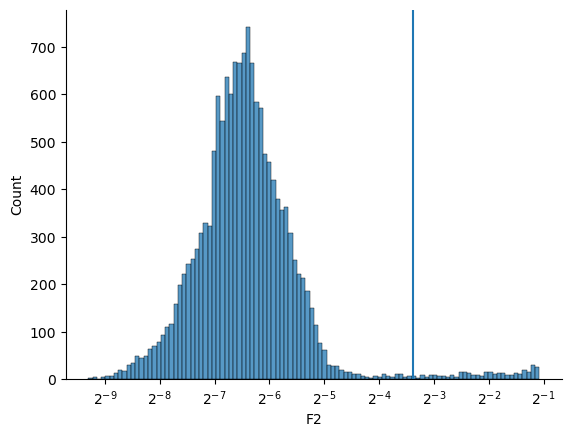

In [13]:
sns.histplot(data=df_pass_QC,
             x='F2',
             log_scale=2
            )

# plt.axvline(0.07966379079189777)
plt.axvline(np.exp2(df_pass_QC['log2_F2'].mean() + 3 * df_pass_QC['log2_F2'].std()))

sns.despine()
plt.show()

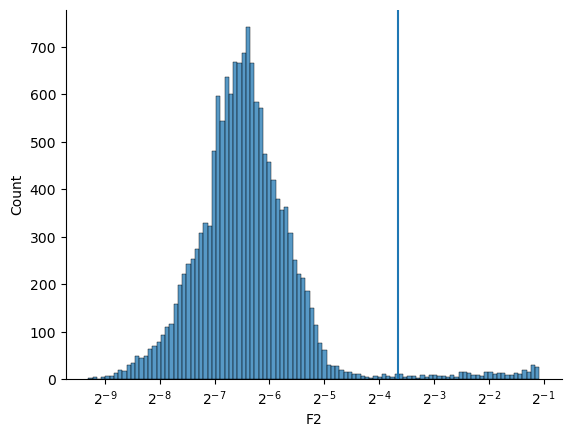

In [14]:
sns.histplot(data=df_pass_QC,
             x='F2',
             log_scale=2
            )

plt.axvline(0.07966379079189777)
# plt.axvline(np.exp2(df_pass_QC['log2_F2'].mean() + 3 * df_pass_QC['log2_F2'].std()))

sns.despine()
plt.show()

In [4]:
for drug in os.listdir(data_dir):
    print(f"python3 data_processing/02_clean_pheno_data.py {drug}")

python3 data_processing/02_clean_pheno_data.py BDQ
python3 data_processing/02_clean_pheno_data.py DLM
python3 data_processing/02_clean_pheno_data.py EMB
python3 data_processing/02_clean_pheno_data.py ETO
python3 data_processing/02_clean_pheno_data.py INH
python3 data_processing/02_clean_pheno_data.py LFX
python3 data_processing/02_clean_pheno_data.py MXF
python3 data_processing/02_clean_pheno_data.py PZA
python3 data_processing/02_clean_pheno_data.py RIF


In [46]:
# df_depth_summary = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/depth_summary.csv")
df_samples_geno = pd.read_csv("data_processing/samples_pass_geno_QC.csv")#.query("DB_OF_ORIGIN != 'TRUST'")
df_samples_geno_old = pd.read_csv("data_processing/samples_pass_geno_QC_old.csv")

# df_samples_geno_new = df_samples_geno_new.merge(df_depth_summary, how='inner', on='ROLLINGDB_ID')
# print(len(set(df_samples_geno_new.ROLLINGDB_ID).symmetric_difference(df_depth_summary.ROLLINGDB_ID)))

# df_samples_geno_keep = df_samples_geno_new.query("Median_Depth >= 15 & Prop_20x >= 0.95")
len(df_samples_geno), len(df_samples_geno_old)

(15902, 14741)

In [4]:
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)

In [9]:
missing_samples = list(set(df_samples_geno.ROLLINGDB_ID) - set(isolate_variants.ROLLINGDB_ID))
len(missing_samples)

2

In [10]:
missing_samples

['SAMEA8718614', 'SAMEA7562405']

In [6]:
df_samples_geno

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
0,20542,MICML,0.027387,4.1.1,4.1.i1.2.1,"xtype,pinipedii",NaN,4.0,4
1,21849,MICML,0.012577,4.3.4.2.1,4.2.1.2.1.1.i3.1,"lam,beijing",NaN,4.3/LAM,4
2,23768,MICML,0.015828,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3,4
3,24304,MICML,0.181536,4.1.1.1,4.1.i1.2.1,"xtype,lam",NaN,4,4
4,26243,MICML,0.013581,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4
...,...,...,...,...,...,...,...,...,...
15897,SAMEA112181557,WHO_catalogue_2023,0.018965,1.2.2,1.2.2.2,"indo_oceanic,ghana",NaN,NaN,1
15898,SAMEA112181558,WHO_catalogue_2023,0.013943,2.2.1,2.2.1.1.1,"beijing,canetti,indo_oceanic","lin2.2.1,asian_african_2",NaN,2
15899,SAMEA112181559,WHO_catalogue_2023,0.013549,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,4
15900,SAMEA112181561,WHO_catalogue_2023,0.019888,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4


In [11]:
# this contains the lineage designations from fast-lineage-caller and the F2 score
df_pass_QC = pd.read_csv("./data_processing/samples_pass_geno_QC.csv").query("~ROLLINGDB_ID.str.startswith('MFS')")# file of isolates that pass genotypic quality control and have a VCF file. Need to do F2 score filtering though
del df_pass_QC['DB_OF_ORIGIN']  # delete this column because it's already in combined_MIC.csv, but keep everything else

# convert to log-scale first
df_pass_QC['log2_F2'] = np.log2(df_pass_QC['F2'])

In [13]:
df_pass_QC.loc[pd.isnull(df_pass_QC['F2'])]

,ROLLINGDB_ID,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log2_F2
1755,SAMEA3558151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1761,SAMEA3558157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1786,SAMEA3558189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1788,SAMEA3558191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1789,SAMEA3558192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
14547,SAMEA8741511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14548,SAMEA8741514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14549,SAMEA8741562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14550,SAMEA8741565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [368]:
sample_id = 'SAMN27762236'

df_variants = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample_id}/WHO_resistance/{sample_id}_variants_annot.tsv", sep='\t')
df_variants['ROLLINGDB_ID'] = sample_id

df_variants.shape

(105, 20)

In [15]:
df_samples_geno = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/samples_pass_geno_QC.csv").query("DB_OF_ORIGIN != 'TRUST'")
df_samples_geno_old = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/samples_pass_geno_QC_old.csv").query("DB_OF_ORIGIN != 'TRUST'")

len(df_samples_geno), len(df_samples_geno_old)

(15169, 14135)

In [38]:
def get_single_drug_R_S_counts(drug, df_samples_geno):

    df_MIC = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv").query("Span_CC == 0")

    df_MIC['Binary'] = df_MIC['Binary'].astype(int)
    
    df_MIC['DB_OF_ORIGIN'] = df_MIC['DB_OF_ORIGIN'].fillna('WHO_Catalogue_2023')

    df_MIC['DB'] = df_MIC['DB_OF_ORIGIN']

    df_MIC.loc[df_MIC['DB_OF_ORIGIN']=='EXIT-RIF', 'DB'] = 'farhat_internal'
    df_MIC.loc[df_MIC['DB_OF_ORIGIN'].isin(['CASS', 'JATA-KIT', 'NICD', 'Wadsworth', 'JATA-Mongolia', 'NSW', 'Cox', 'Lizma']), 'DB'] = 'MIC_ML'

    return pd.DataFrame(df_MIC[['Binary', 'DB']].value_counts()).reset_index().sort_values(['DB', 'Binary']).reset_index(drop=True)

In [39]:
df_counts_combined = []

for drug in os.listdir(data_dir):

    if drug not in ['BDQ', 'DLM']:
        df_test = get_single_drug_R_S_counts(drug, df_samples_geno)
        df_test['Drug_abbr'] = drug
        df_test['Drug'] = abbr_drug_dict[drug]
        df_counts_combined.append(df_test)

df_counts_combined = pd.concat(df_counts_combined).rename(columns={'count': 'Num_Isolates'})
df_counts_combined['Binary_Phenotype'] = df_counts_combined['Binary'].map({0: 'S', 1: 'R'})

In [40]:
df_counts_combined.DB.unique()

array(['CRyPTIC', 'MIC_ML', 'WHO_catalog', 'farhat_internal'],
      dtype=object)

In [44]:
df_counts_combined[['Drug_abbr', 'Drug', 'DB', 'Binary_Phenotype', 'Num_Isolates']].to_csv("training_data_R_S_counts.csv", index=False)

In [45]:
df_counts_combined.groupby("Drug")['Num_Isolates'].sum()

Drug
Ethambutol       9984
Ethionamide     10120
Isoniazid       12069
Levofloxacin     7800
Moxifloxacin     9203
Pyrazinamide     1021
Rifampicin      11542
Name: Num_Isolates, dtype: int64

In [47]:
df_counts_combined.groupby(['Drug', 'DB'])['Num_Isolates'].sum()

Drug          DB             
Ethambutol    CRyPTIC            7520
              MIC_ML             1107
              WHO_catalog         228
              farhat_internal    1129
Ethionamide   CRyPTIC            8752
              WHO_catalog         220
              farhat_internal    1148
Isoniazid     CRyPTIC            9327
              MIC_ML             1230
              WHO_catalog         236
              farhat_internal    1276
Levofloxacin  CRyPTIC            7745
              WHO_catalog          54
              farhat_internal       1
Moxifloxacin  CRyPTIC            6945
              MIC_ML             1225
              farhat_internal    1033
Pyrazinamide  WHO_catalog          91
              farhat_internal     930
Rifampicin    CRyPTIC            8644
              MIC_ML             1238
              WHO_catalog         237
              farhat_internal    1423
Name: Num_Isolates, dtype: int64

In [46]:
df_samples_geno.DB_OF_ORIGIN.value_counts()

DB_OF_ORIGIN
CRyPTIC               10639
rollingDB              1616
MICML                  1458
WHO_catalogue_2023     1456
Name: count, dtype: int64

In [19]:
df_test

,Binary,DB,count
0,0,WHO_catalog,50
1,1,WHO_catalog,41
2,0,farhat_internal,443
3,1,farhat_internal,487


In [252]:
for drug in os.listdir(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"):
    
    df_MIC = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/data_for_model.csv")
    
    print(drug, df_MIC.query("ROLLINGDB_ID in @df_samples_geno.ROLLINGDB_ID").ROLLINGDB_ID.nunique(), df_MIC.query("ROLLINGDB_ID in @df_samples_geno_keep.ROLLINGDB_ID").ROLLINGDB_ID.nunique())

BDQ 9028 9015
DLM 8277 8054
EMB 9918 10422
ETO 10149 10164
INH 11747 12215
LFX 7975 7818
MXF 8994 9297
PZA 937 1029
RIF 11228 11815


In [228]:
drug = 'MXF'



Binary
0.0    7509
1.0    1697
Name: count, dtype: int64

9061

In [ ]:
df_samples_geno_keep

In [206]:
df_samples_geno_keep

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,RUN,Mean_Depth,Median_Depth,Prop_20x,Prop_10x
0,20542,MICML,0.027387,4.1.1,4.1.i1.2.1,"xtype,pinipedii",NaN,4.0,4,20542,72.053140,74.0,0.975917,0.982701
1,21849,MICML,0.012577,4.3.4.2.1,4.2.1.2.1.1.i3.1,"lam,beijing",NaN,4.3/LAM,4,21849,55.808687,57.0,0.967670,0.975856
2,23768,MICML,0.015828,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3,4,23768,88.600146,91.0,0.979706,0.985505
3,24304,MICML,0.181536,4.1.1.1,4.1.i1.2.1,"xtype,lam",NaN,4,4,24304,75.656802,78.0,0.974576,0.983042
4,26243,MICML,0.013581,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4,26243,103.009005,106.0,0.983944,0.987989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18933,SAMEA112181557,NaN,0.018965,1.2.2,1.2.2.2,"indo_oceanic,ghana",NaN,NaN,1,ERR10610111,132.167582,137.0,0.972750,0.977263
18934,SAMEA112181558,NaN,0.013943,2.2.1,2.2.1.1.1,"beijing,canetti,indo_oceanic","lin2.2.1,asian_african_2",NaN,2,ERR10610274,229.880759,242.0,0.967429,0.970662
18935,SAMEA112181559,NaN,0.013549,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,4,ERR10610277,203.904950,217.0,0.967898,0.971495
18936,SAMEA112181561,NaN,0.019888,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,ERR10610309,294.259781,309.0,0.975804,0.980081


In [169]:
df_samples_geno_new.loc[(df_samples_geno_new['Median_Depth'] < 15) | (df_samples_geno_new['Prop_20x'] < 0.95), 'Failed'] = 1
df_samples_geno_new['Failed'] = df_samples_geno_new['Failed'].fillna(0).astype(int)

In [175]:
# redo_samples = []

# for sample in df_samples_geno_new.ROLLINGDB_ID.unique():

#     if df_samples_geno_new.query("ROLLINGDB_ID==@sample")['RUN'].nunique() > 1:

#         # df_samples_geno_new
#         if len(df_samples_geno_new.query("ROLLINGDB_ID==@sample").query("Prop_20x >= 0.90 & Prop_20x < 0.95")) > 0:
#             redo_samples.append(sample)

In [176]:
len(redo_samples)

120

In [200]:
isolate_metadata.query("ROLLINGDB_ID in @redo_samples").ROLLINGDB_ID.nunique()

120

In [254]:
df_rerun = isolate_metadata.query("ROLLINGDB_ID in @redo_samples")[['ROLLINGDB_ID', 'Combined_Runs']].drop_duplicates()
df_rerun['FQ'] = 1

df_rerun.to_csv("~/Mtb_Megapipe/CNN_samples.tsv", sep='\t', header=None, index=False)

In [182]:
df_samples_geno_new.shape, df_samples_geno_new[['ROLLINGDB_ID', 'RUN']].drop_duplicates().shape

((18938, 15), (17033, 2))

In [193]:
df_samples_geno_new.query("ROLLINGDB_ID in @redo_samples").head(10)

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,RUN,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Failed
1790,SAMEA3558135,rollingDB,0.007782,3.1.2,3.1.1.i2,"east_african_indian,ghana,mungi",NaN,NaN,3,ERR1034602,287.557319,287.0,0.983259,0.984584,0
1791,SAMEA3558135,rollingDB,0.007782,3.1.2,3.1.1.i2,"east_african_indian,ghana,mungi",NaN,NaN,3,ERR1213850,46.214479,45.0,0.937834,0.966315,1
1822,SAMEA3558151,rollingDB,0.002087,4.7,4,NaN,NaN,4.10/PGG3,4,ERR1034618,47.272335,45.0,0.935865,0.965021,1
1823,SAMEA3558151,rollingDB,0.002087,4.7,4,NaN,NaN,4.10/PGG3,4,ERR1213866,222.752500,230.0,0.979631,0.982296,0
1834,SAMEA3558157,rollingDB,0.004786,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,haarlem",NaN,4.3/LAM,4,ERR1034624,195.154525,203.0,0.972652,0.975578,0
1835,SAMEA3558157,rollingDB,0.004786,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,haarlem",NaN,4.3/LAM,4,ERR1213872,49.367158,47.0,0.940299,0.968709,1
1836,SAMEA3558158,rollingDB,0.392634,"4.1.2,4.1.1.1","4.1.i1.1.1.1,4.1.i1.2.1","xtype,haarlem,canetti",NaN,4,4,ERR1034625,221.254972,230.0,0.979882,0.982445,0
1837,SAMEA3558158,rollingDB,0.392634,"4.1.2,4.1.1.1","4.1.i1.1.1.1,4.1.i1.2.1","xtype,haarlem,canetti",NaN,4,4,ERR1213873,46.853294,45.0,0.942138,0.965491,1
1840,SAMEA3558162,rollingDB,0.009706,2.2.1,2.2.1.1.1.i3,"beijing,mungi","lin2.2.1,central_asia",NaN,2,ERR1034629,38.119883,35.0,0.906186,0.974772,1
1841,SAMEA3558162,rollingDB,0.009706,2.2.1,2.2.1.1.1.i3,"beijing,mungi","lin2.2.1,central_asia",NaN,2,ERR1213877,219.617103,227.0,0.973077,0.976585,0


In [168]:
df_samples_geno_new.query("Median_Depth < 15 | Prop_20x < 0.95")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,RUN,Mean_Depth,Median_Depth,Prop_20x,Prop_10x
1461,SAMEA10029750,rollingDB,0.021899,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4,ERR7910844,32.451570,33.0,0.884983,0.952692
1463,SAMEA10029750,rollingDB,0.021899,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4,ERR7910844,32.451570,33.0,0.884983,0.952692
1937,SAMEA3558135,rollingDB,0.007782,3.1.2,3.1.1.i2,"east_african_indian,ghana,mungi",NaN,NaN,3,ERR1213850,46.214479,45.0,0.937834,0.966315
1939,SAMEA3558135,rollingDB,0.007782,3.1.2,3.1.1.i2,"east_african_indian,ghana,mungi",NaN,NaN,3,ERR1213850,46.214479,45.0,0.937834,0.966315
2000,SAMEA3558151,rollingDB,0.002087,4.7,4,NaN,NaN,4.10/PGG3,4,ERR1034618,47.272335,45.0,0.935865,0.965021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18883,SAMEA112181459,NaN,0.029300,2.2.1,2.2.1.1.1.i2,beijing,lin2.2.1,NaN,2,ERR10610363,39.449488,40.0,0.942037,0.963761
18884,SAMEA112181461,NaN,0.028689,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,ERR10610103,37.782770,39.0,0.934548,0.962473
18889,SAMEA112181491,NaN,0.024069,2.2.1,2.2.1.1.1,beijing,"lin2.2.1,asian_african_2",NaN,2,ERR10610132,53.752825,55.0,0.949126,0.960554
18890,SAMEA112181495,NaN,0.039071,4.4.1.1,4.2.1.2.2.1.1,"stype,canetti",NaN,4,4,ERR10610306,34.960635,35.0,0.910397,0.962756


In [238]:
new_samples = list(set(df_samples_geno_keep.ROLLINGDB_ID) - set(df_samples_geno.ROLLINGDB_ID))
len(new_samples)

1660

In [239]:
df_samples_geno_keep.ROLLINGDB_ID.nunique(), df_samples_geno.query("DB_OF_ORIGIN != 'TRUST'").ROLLINGDB_ID.nunique()

(15114, 14135)

In [240]:
15114-14135

979

In [162]:
df_samples_geno_keep.query("ROLLINGDB_ID in @new_samples").DB_OF_ORIGIN.value_counts(dropna=False)

DB_OF_ORIGIN
NaN      1248
MICML     417
Name: count, dtype: int64

In [164]:
df_samples_geno_keep.to_csv("data_processing/samples_pass_geno_QC_new.csv", index=False)

In [165]:
df_samples_geno_keep

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,RUN,Mean_Depth,Median_Depth,Prop_20x,Prop_10x
0,20542,MICML,0.027387,4.1.1,4.1.i1.2.1,"xtype,pinipedii",NaN,4.0,4,20542,72.053140,74.0,0.975917,0.982701
1,21849,MICML,0.012577,4.3.4.2.1,4.2.1.2.1.1.i3.1,"lam,beijing",NaN,4.3/LAM,4,21849,55.808687,57.0,0.967670,0.975856
2,23768,MICML,0.015828,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3,4,23768,88.600146,91.0,0.979706,0.985505
3,24304,MICML,0.181536,4.1.1.1,4.1.i1.2.1,"xtype,lam",NaN,4,4,24304,75.656802,78.0,0.974576,0.983042
4,26243,MICML,0.013581,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4,26243,103.009005,106.0,0.983944,0.987989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18933,SAMEA112181557,NaN,0.018965,1.2.2,1.2.2.2,"indo_oceanic,ghana",NaN,NaN,1,ERR10610111,132.167582,137.0,0.972750,0.977263
18934,SAMEA112181558,NaN,0.013943,2.2.1,2.2.1.1.1,"beijing,canetti,indo_oceanic","lin2.2.1,asian_african_2",NaN,2,ERR10610274,229.880759,242.0,0.967429,0.970662
18935,SAMEA112181559,NaN,0.013549,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,4,ERR10610277,203.904950,217.0,0.967898,0.971495
18936,SAMEA112181561,NaN,0.019888,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,ERR10610309,294.259781,309.0,0.975804,0.980081


In [21]:
for drug in os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"):
    if drug not in ['MXF', 'LFX', 'BDQ', 'DLM']:
        print(f"python3 -u analysis/create_insilico_VCFs.py -c config_files/config_{drug.lower()}.yaml")

python3 -u analysis/create_insilico_VCFs.py -c config_files/config_emb.yaml
python3 -u analysis/create_insilico_VCFs.py -c config_files/config_eto.yaml
python3 -u analysis/create_insilico_VCFs.py -c config_files/config_inh.yaml
python3 -u analysis/create_insilico_VCFs.py -c config_files/config_pza.yaml
python3 -u analysis/create_insilico_VCFs.py -c config_files/config_rif.yaml


In [91]:
TRUST_summary = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")
TRUST_summary_new = pd.read_csv("/home/sak0914/MtbQuantCNN/TRUST_depth_summary.csv")

len(TRUST_summary_new), len(TRUST_summary)

(733, 762)

In [128]:
TRUST_summary_new_new = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")

In [129]:
TRUST_summary_new_new

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_10x,Perc_Sites_20x,F2,Coll2014,Freschi2020,Lineage,Culture_Mixed_Infection,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
0,T0004,MFS-1,0.37,307.773105,314.0,98.643759,98.486308,0.011212,2.2.1.1,2.2.1.1.1,2,0,2.2.1.1.1,NaN,"beijing,mungi","lin2.2.1,pacific_RD150",NaN
1,T0021,MFS-10,0.37,332.305094,338.0,99.074517,98.966640,0.009122,4.3.2.1,4.2.1.2.1.1.i1,4,0,4.2.1.2.1.1.i1,NaN,lam,NaN,4.3/LAM
2,T0183,MFS-100,0.77,267.979292,273.0,98.973191,98.840403,0.008850,4.4.1.1,4.2.1.2.2.1.1,4,0,4.2.1.2.2.1.1,NaN,"stype,indo_oceanic",NaN,4
3,T0183,MFS-101,0.73,300.620813,307.0,98.987835,98.836595,0.008316,4.4.1.1,4.2.1.2.2.1.1,4,0,4.2.1.2.2.1.1,NaN,"stype,indo_oceanic",NaN,4
4,T0184,MFS-102,0.91,276.773151,282.0,98.829024,98.696394,0.018669,4.1.1.3,4.1.i1.2.1,4,0,4.1.i1.2.1,NaN,xtype,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,T0179,MFS-95,0.76,345.375614,354.0,99.028750,98.888731,0.019837,4.1.1.3,4.1.i1.2.1,4,0,4.1.i1.2.1,NaN,xtype,NaN,4
758,T0179,MFS-96,0.53,376.949171,384.0,99.018210,98.879936,0.020201,4.1.1.3,4.1.i1.2.1,4,0,4.1.i1.2.1,NaN,xtype,NaN,4
759,T0180,MFS-97,0.78,325.623465,333.0,98.534545,98.392826,0.010201,2.2.1.1,2.2.1.1.1,2,0,2.2.1.1.1,NaN,"beijing,mungi","lin2.2.1,pacific_RD150",NaN
760,T0181,MFS-98,0.52,371.939378,380.0,98.918652,98.799261,0.018668,4.1.1.3,4.1.i1.2.1,4,0,4.1.i1.2.1,NaN,xtype,NaN,4


In [92]:
df_Freschi_split = TRUST_summary['Freschi2020'].str.split(',', expand=True)
df_Freschi_split.columns = [f"Freschi_Lineage_{num+1}" for num in np.arange(df_Freschi_split.shape[1])]

# df_Coll_split = TRUST_summary['Coll2014'].str.split(',', expand=True)
# df_Coll_split.columns = [f"Coll_Lineage_{num+1}" for num in np.arange(df_Coll_split.shape[1])]

TRUST_summary = pd.concat([TRUST_summary, df_Freschi_split], axis=1)

In [93]:
TRUST_summary_new = TRUST_summary_new.merge(TRUST_summary[['SampleID', 'Kraken_Unclassified_Percent', 'F2', 'Coll2014', 'Lineage', 'Freschi2020', 'Freschi_Lineage_1', 'Freschi_Lineage_2', 'Lipworth2019', 'Shitikov2017', 'Stucki2016']], how='right')

del TRUST_summary_new['RUN']

In [127]:
TRUST_summary_new.to_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv", index=False)

In [125]:
TRUST_summary_new.SampleID.nunique(), TRUST_summary_new.pid.nunique()

(762, 416)

In [130]:
TRUST_summary_new_new.loc[pd.isnull(TRUST_summary_new_new['pid'])]

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_10x,Perc_Sites_20x,F2,Coll2014,Freschi2020,Lineage,Culture_Mixed_Infection,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
364,NaN,MFS-490,99.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
365,NaN,MFS-491,99.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
366,NaN,MFS-492,87.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
367,NaN,MFS-493,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
368,NaN,MFS-494,99.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
369,NaN,MFS-495,99.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
370,NaN,MFS-496,99.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
371,NaN,MFS-497,97.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
372,NaN,MFS-498,99.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
373,NaN,MFS-499,96.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN


In [94]:
TRUST_summary_new.loc[pd.isnull(TRUST_summary_new['Lineage'])].Kraken_Unclassified_Percent.min()

39.68

In [95]:
TRUST_summary_new.loc[TRUST_summary_new['SampleID']=='MFS-270', 'Lineage'] = '2,4'

In [96]:
TRUST_summary_new.loc[TRUST_summary_new['SampleID']=='MFS-270']

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
127,MFS-270,298.796325,306.0,0.989269,0.991434,0.57,0.245979,2.2.1.1,"2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN


In [97]:
TRUST_summary_new

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
0,MFS-1,307.773105,314.0,0.984863,0.986438,0.37,0.011212,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,mungi","lin2.2.1,pacific_RD150",NaN
1,MFS-10,332.305094,338.0,0.989666,0.990745,0.37,0.009122,4.3.2.1,4,4.2.1.2.1.1.i1,4.2.1.2.1.1.i1,None,lam,NaN,4.3/LAM
2,MFS-100,267.979292,273.0,0.988404,0.989732,0.77,0.008850,4.4.1.1,4,4.2.1.2.2.1.1,4.2.1.2.2.1.1,None,"stype,indo_oceanic",NaN,4
3,MFS-101,300.620813,307.0,0.988366,0.989878,0.73,0.008316,4.4.1.1,4,4.2.1.2.2.1.1,4.2.1.2.2.1.1,None,"stype,indo_oceanic",NaN,4
4,MFS-102,276.773151,282.0,0.986964,0.988290,0.91,0.018669,4.1.1.3,4,4.1.i1.2.1,4.1.i1.2.1,None,xtype,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,MFS-95,345.375614,354.0,0.988887,0.990288,0.76,0.019837,4.1.1.3,4,4.1.i1.2.1,4.1.i1.2.1,None,xtype,NaN,4
758,MFS-96,376.949171,384.0,0.988799,0.990182,0.53,0.020201,4.1.1.3,4,4.1.i1.2.1,4.1.i1.2.1,None,xtype,NaN,4
759,MFS-97,325.623465,333.0,0.983928,0.985345,0.78,0.010201,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,mungi","lin2.2.1,pacific_RD150",NaN
760,MFS-98,371.939378,380.0,0.987993,0.989187,0.52,0.018668,4.1.1.3,4,4.1.i1.2.1,4.1.i1.2.1,None,xtype,NaN,4


In [98]:
TRUST_summary = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")

In [100]:
TRUST_summary_new.loc[(~pd.isnull(TRUST_summary_new['Freschi2020'])) & (TRUST_summary_new['Freschi2020'].str.contains(',')), 'Culture_Mixed_Infection'] = 1

TRUST_summary_new['Culture_Mixed_Infection'] = TRUST_summary_new['Culture_Mixed_Infection'].fillna(0).astype(int)

TRUST_summary_new = TRUST_summary_new.merge(df_trust_patients[['pid', 'SampleID']], on='SampleID', how='left')

TRUST_summary_new['Perc_Sites_10x'] = TRUST_summary_new['Prop_10x']*100
TRUST_summary_new['Perc_Sites_20x'] = TRUST_summary_new['Prop_20x']*100

In [102]:
TRUST_summary_new['Culture_Mixed_Infection'].value_counts()

Culture_Mixed_Infection
0    751
1     11
Name: count, dtype: int64

In [111]:
TRUST_summary_new.query("Culture_Mixed_Infection==1").sort_values("pid")

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016,Culture_Mixed_Infection,pid
200,MFS-336,337.337377,337.0,0.991310,0.992756,0.34,0.458952,"4.1.1.1,2.2.1.1","2,4","4.1.i1.2.1,2.2.1.1.1",4.1.i1.2.1,2.2.1.1.1,"beijing,xtype,westafrican1","lin2.2.1,pacific_RD150",NaN,1,T0010
216,MFS-350,344.440217,340.0,0.993451,0.994736,0.42,0.408194,"4.1.2.1,4.8",4,"4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem,1,T0072
218,MFS-353,419.230392,404.0,0.993744,0.994829,0.36,0.415768,"4.1.2.1,4.8",4,"4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem,1,T0087
726,MFS-85,361.552929,369.0,0.992121,0.993726,0.80,0.259418,"2.2.1,4.1.1.3","2,4","4.1,2.2.1.1.1",4.1,2.2.1.1.1,"beijing,xtype,mungi","lin2.2.1,asian_african_2",NaN,1,T0167
515,MFS-631,269.194783,271.0,0.992001,0.993956,0.59,0.314259,"2.2.1,3.1.1","2,3","2.2.1.1.1,3.1.1.i1",2.2.1.1.1,3.1.1.i1,"beijing,east_african_indian,mungi",lin2.2.1,NaN,1,T0204
76,MFS-168,382.326083,392.0,0.992838,0.994269,1.35,0.477297,"4.1.1.3,2.2.1.1","2,4","4.1.i1.2.1,2.2.1.1.1",4.1.i1.2.1,2.2.1.1.1,"beijing,xtype","lin2.2.1,pacific_RD150",NaN,1,T0252
127,MFS-270,298.796325,306.0,0.989269,0.991434,0.57,0.245979,2.2.1.1,"2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN,1,T0267
175,MFS-313,322.862748,330.0,0.989468,0.990986,0.91,0.436810,"4.3.2.1,2.2.1.1","2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam","lin2.2.1,pacific_RD150",4.3/LAM,1,T0305
179,MFS-317,379.240440,388.0,0.989741,0.991347,0.69,0.369685,"4.3.2.1,2.2.1.1","2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam","lin2.2.1,pacific_RD150",4.3/LAM,1,T0311
356,MFS-483,265.043600,271.0,0.990705,0.992266,0.40,0.474464,"4.1.1.3,2.2.1.1","2,4","4.1.i1.2.1,2.2.1.1.1",4.1.i1.2.1,2.2.1.1.1,"beijing,xtype","lin2.2.1,pacific_RD150",NaN,1,T0391


In [119]:
TRUST_summary_new = TRUST_summary_new[['pid', 'SampleID', 'Kraken_Unclassified_Percent', 'Mean_Depth', 'Median_Depth', 'Perc_Sites_10x', 'Perc_Sites_20x', 'F2', 'Coll2014', 'Freschi2020', 'Lineage', 'Culture_Mixed_Infection', 'Freschi_Lineage_1', 'Freschi_Lineage_2', 'Lipworth2019', 'Shitikov2017', 'Stucki2016']]

In [123]:
TRUST_summary_new.dropna(subset='Lineage').query("Culture_Mixed_Infection==0 & Lineage.str.contains(',')")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_10x,Perc_Sites_20x,F2,Coll2014,Freschi2020,Lineage,Culture_Mixed_Infection,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016


In [124]:
TRUST_summary_new.query("SampleID=='MFS-270'")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_10x,Perc_Sites_20x,F2,Coll2014,Freschi2020,Lineage,Culture_Mixed_Infection,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
127,T0267,MFS-270,0.57,298.796325,306.0,99.143381,98.926881,0.245979,2.2.1.1,"2.2.1.1.1,4.2.1.2.1.1.i1","2,4",1,2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN


In [114]:
TRUST_summary

,SampleID,Kraken_Unclassified_Percent,Median_Depth,Prop_Sites_10x,Prop_Sites_20x,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
0,MFS-1,0.37,314.0,0.986438,0.984863,0.011212,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2
1,MFS-10,0.37,338.0,0.990745,0.989666,0.009122,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4
2,MFS-100,0.77,273.0,0.989732,0.988404,0.008850,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4
3,MFS-101,0.73,307.0,0.989878,0.988366,0.008316,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4
4,MFS-102,0.91,282.0,0.988290,0.986964,0.018669,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
757,MFS-95,0.76,354.0,0.990288,0.988887,0.019837,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4
758,MFS-96,0.53,384.0,0.990182,0.988799,0.020201,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4
759,MFS-97,0.78,333.0,0.985345,0.983928,0.010201,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2
760,MFS-98,0.52,380.0,0.989187,0.987993,0.018668,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4


In [74]:
TRUST_summary_new.dropna(subset='Freschi2020').query("Freschi2020.str.contains(',') & F2 <= 0.05")

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016


In [76]:
TRUST_summary_new.dropna(subset='Freschi2020').query("~Freschi2020.str.contains(',') & F2 > 0.05").sort_values("F2")

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
454,MFS-577,278.386917,284.0,0.985131,0.991050,0.46,0.052394,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,lam","lin2.2.1,pacific_RD150",NaN
104,MFS-198,319.509604,327.0,0.991368,0.993198,0.73,0.075920,4.1.1.3,4,4.1.i1.2.1,4.1.i1.2.1,None,xtype,NaN,4
358,MFS-485,249.628684,255.0,0.987018,0.991359,0.55,0.079214,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,mungi","lin2.2.1,pacific_RD150",NaN
320,MFS-450,256.561309,262.0,0.985621,0.987430,0.39,0.090001,2.2.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,mungi",lin2.2.1,NaN
243,MFS-377,286.652175,292.0,0.988399,0.990204,0.39,0.108434,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,beijing,"lin2.2.1,pacific_RD150",NaN
581,MFS-696,328.165475,336.0,0.987511,0.990015,0.45,0.108637,2.2.1,2,2.2.1.1.1.i2,2.2.1.1.1.i2,None,"beijing,mungi",lin2.2.1,NaN
252,MFS-39,263.706066,267.0,0.988429,0.991003,0.76,0.110925,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,lam","lin2.2.1,pacific_RD150",NaN
51,MFS-145,463.847369,473.0,0.993157,0.994411,1.31,0.122113,4.8,4,4.2.1.1.1.1.1.1.i1,4.2.1.1.1.1.1.1.i1,None,"beijing,canetti",NaN,4.10/PGG3
326,MFS-456,272.577049,279.0,0.990343,0.992174,0.51,0.130840,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,mungi","lin2.2.1,pacific_RD150",NaN
39,MFS-134,319.111396,326.0,0.985191,0.986645,0.57,0.138670,2.2.1.1,2,2.2.1.1.1,2.2.1.1.1,None,"beijing,mungi","lin2.2.1,pacific_RD150",NaN


In [11]:
mixed_lineage_samples = TRUST_summary_new.loc[(~pd.isnull(TRUST_summary_new['Coll_Lineage_2'])) | (~pd.isnull(TRUST_summary_new['Freschi_Lineage_2']))].SampleID.values
len(mixed_lineage_samples)

11

In [77]:
df_rerun = TRUST_summary_new.dropna(subset='Freschi2020').query("~Freschi2020.str.contains(',') & F2 > 0.05").sort_values("F2")[['SampleID']]
df_rerun['RUN'] = df_rerun['SampleID']
df_rerun['FQ'] = 0
df_rerun.to_csv( "/home/sak0914/Mtb_Megapipe/TRUST_samples.tsv", index=False, sep='\t', header=None)

In [78]:
len(df_rerun)

15

In [81]:
for sample in mixed_lineage_samples:

    df_minor_allele_fractions = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sample}/lineage/minor_allele_fractions.csv")
    # print(sample, TRUST_summary_new.query("SampleID==@sample")['F2'].values[0])
    lineages = TRUST_summary_new.query("SampleID==@sample")['Coll2014'].values[0].split(',')

    # if len(lineages) == 1:
    #     print(sample)
    #     break

    major_lineage = df_minor_allele_fractions.query("Lineage in @lineages").sort_values("Fraction", ascending=True)['Lineage'].values[0]
    minor_lineage = df_minor_allele_fractions.query("Lineage in @lineages").sort_values("Fraction", ascending=True)['Lineage'].values[-1]
    
    print(sample, major_lineage, minor_lineage)
    # TRUST_summary_new.loc[TRUST_summary_new['SampleID']==sample, ['Coll_Lineage_1', 'Coll_Lineage_2']] = [major_lineage, minor_lineage]

    if sample == 'MFS-707':
        print(lineages)
        break
    
    # print(df_minor_allele_fractions.head(2))
    # print(df_minor_allele_fractions.query("Lineage in @lineages"))

MFS-168 4.1.1.3 2.2.1.1
MFS-270 2.2.1.1 2.2.1.1
MFS-313 4.3.2.1 2.2.1.1
MFS-317 4.3.2.1 2.2.1.1
MFS-336 4.1.1.1 2.2.1.1
MFS-350 4.8 4.1.2.1
MFS-353 4.8 4.1.2.1
MFS-483 4.1.1.3 2.2.1.1
MFS-631 2.2.1 3.1.1
MFS-707 4.1.1.1 4.1.1.1
['4.3.4.2.1', '4.1.1.1']


In [82]:
TRUST_summary_new.query("SampleID == @sample")

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
594,MFS-707,454.523204,467.0,0.990434,0.991491,0.49,0.313857,"4.3.4.2.1,4.1.1.1",4,"4.1.i1.2,4.2.1.2.1.1.i3.1",4.1.i1.2,4.2.1.2.1.1.i3.1,"lam,xtype,westafrican1",NaN,4.3/LAM


In [83]:
TRUST_summary_new.query("SampleID in @mixed_lineage_samples")

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
76,MFS-168,382.326083,392.0,0.992838,0.994269,1.35,0.477297,"4.1.1.3,2.2.1.1","2,4","4.1.i1.2.1,2.2.1.1.1",4.1.i1.2.1,2.2.1.1.1,"beijing,xtype","lin2.2.1,pacific_RD150",NaN
127,MFS-270,298.796325,306.0,0.989269,0.991434,0.57,0.245979,2.2.1.1,"2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN
175,MFS-313,322.862748,330.0,0.989468,0.990986,0.91,0.436810,"4.3.2.1,2.2.1.1","2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam","lin2.2.1,pacific_RD150",4.3/LAM
179,MFS-317,379.240440,388.0,0.989741,0.991347,0.69,0.369685,"4.3.2.1,2.2.1.1","2,4","2.2.1.1.1,4.2.1.2.1.1.i1",2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam","lin2.2.1,pacific_RD150",4.3/LAM
200,MFS-336,337.337377,337.0,0.991310,0.992756,0.34,0.458952,"4.1.1.1,2.2.1.1","2,4","4.1.i1.2.1,2.2.1.1.1",4.1.i1.2.1,2.2.1.1.1,"beijing,xtype,westafrican1","lin2.2.1,pacific_RD150",NaN
216,MFS-350,344.440217,340.0,0.993451,0.994736,0.42,0.408194,"4.1.2.1,4.8",4,"4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem
218,MFS-353,419.230392,404.0,0.993744,0.994829,0.36,0.415768,"4.1.2.1,4.8",4,"4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem
356,MFS-483,265.043600,271.0,0.990705,0.992266,0.40,0.474464,"4.1.1.3,2.2.1.1","2,4","4.1.i1.2.1,2.2.1.1.1",4.1.i1.2.1,2.2.1.1.1,"beijing,xtype","lin2.2.1,pacific_RD150",NaN
515,MFS-631,269.194783,271.0,0.992001,0.993956,0.59,0.314259,"2.2.1,3.1.1","2,3","2.2.1.1.1,3.1.1.i1",2.2.1.1.1,3.1.1.i1,"beijing,east_african_indian,mungi",lin2.2.1,NaN
594,MFS-707,454.523204,467.0,0.990434,0.991491,0.49,0.313857,"4.3.4.2.1,4.1.1.1",4,"4.1.i1.2,4.2.1.2.1.1.i3.1",4.1.i1.2,4.2.1.2.1.1.i3.1,"lam,xtype,westafrican1",NaN,4.3/LAM


In [85]:
sample, lineages

('MFS-707', ['4.3.4.2.1', '4.1.1.1'])

In [86]:
df_minor_allele_fractions.query("Lineage in ['4', '4.1', '4.1.1', '4.1.1.1']")

,Lineage,Fraction
0,4.1,0.314185
2,4.1.1.1,0.311581
3,4.1.1,0.305950
26,4,0.001675


In [87]:
df_minor_allele_fractions.query("Lineage in ['4', '4.3', '4.3.4', '4.3.4.2', '4.3.4.2.1']")

,Lineage,Fraction
1,4.3,0.313572
4,4.3.4,0.305417
5,4.3.4.2,0.305411
26,4,0.001675


In [88]:
df_minor_allele_fractions

,Lineage,Fraction
0,4.1,0.314185
1,4.3,0.313572
2,4.1.1.1,0.311581
3,4.1.1,0.305950
4,4.3.4,0.305417
5,4.3.4.2,0.305411
6,4.2.2,0.006751
7,2.1,0.005081
8,4.3.2,0.004985
9,4.2,0.004824


In [30]:
df_trust_patients = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")

In [32]:
TRUST_summary_new.query("SampleID in ['MFS-350', 'MFS-353']")

,SampleID,Mean_Depth,Median_Depth,Prop_20x,Prop_10x,Kraken_Unclassified_Percent,F2,Coll2014,Coll_Lineage_1,Coll_Lineage_2,Lineage,Freschi2020,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
216,MFS-350,344.440217,340.0,0.993451,0.994736,0.42,0.408194,"4.1.2.1,4.8",4.1.2.1,4.8,4,"4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem
218,MFS-353,419.230392,404.0,0.993744,0.994829,0.36,0.415768,"4.1.2.1,4.8",4.1.2.1,4.8,4,"4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem


In [31]:
df_trust_patients.query("SampleID in ['MFS-350', 'MFS-353']")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
408,T0087,S0087-01,MFS-353,1.0,MFS-353_lib59077,NaN,NaN,1.0,422.31,1.0,...,0.614105,2.0,0.983607,1.000000,1,178,0.415768,"4.1.2.1,4.8","4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4
429,T0072,S0072-01,MFS-350,1.0,MFS-350_lib59074,NaN,NaN,1.0,346.84,1.0,...,0.285549,NaN,0.819549,0.833333,1,189,0.408194,"4.1.2.1,4.8","4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4


In [114]:
df_fastlin

,#sample,data_type,k_cov,mixture,lineages,log_barcodes,log_errors
0,MFS-85,paired,150,yes,"4.1.1.3 (35), 2.2.1 (103)","2 (132, 147, 110, 120, 85, 101, 102, 100, 161,...",NaN


In [115]:
sample_ID = 'MFS-85'

sample_dir = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sample_ID}"
# F2_fName = cmd_line_args.F2_fName
lineage_defining_SNPs_file = "/home/sak0914/Mtb_Megapipe/references/phylogeny/Coll2014_SNPs_all.csv"

In [134]:
depth_summary_all = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/depth_summary.csv")
len(depth_summary_all)

2315

In [20]:
TRUST_summary.loc[pd.isnull(TRUST_summary['Lineage'])].sort_values("Kraken_Unclassified_Percent").sort_values("SampleID")

,SampleID,Kraken_Unclassified_Percent,Median_Depth,Prop_Sites_10x,Prop_Sites_20x,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
88,MFS-179,95.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,MFS-183,45.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
165,MFS-304,52.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
289,MFS-422,77.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
290,MFS-423,39.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
292,MFS-425,85.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321,MFS-451,87.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323,MFS-453,96.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349,MFS-477,97.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,MFS-490,99.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
python3 -u analysis/create_insilico_VCFs.py -c config_files/config_rif.yaml --tier2

In [4]:
df_summary['Prop_Sites_20x'].min()

0.9783798462756248

In [8]:
df_summary.Median_Depth.min()

232.0

In [16]:
df_samples_geno.query("ROLLINGDB_ID in @df_summary.SampleID")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
14127,MFS-1,TRUST,0.011212,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2,-6.478834
14128,MFS-10,TRUST,0.009122,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4,-6.776415
14129,MFS-100,TRUST,0.008850,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4,-6.820039
14130,MFS-101,TRUST,0.008316,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4,-6.909893
14131,MFS-102,TRUST,0.018669,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.743249
...,...,...,...,...,...,...,...,...,...,...
14855,MFS-95,TRUST,0.019837,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.655653
14856,MFS-96,TRUST,0.020201,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.629449
14857,MFS-97,TRUST,0.010201,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2,-6.615190
14858,MFS-98,TRUST,0.018668,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.743267


In [18]:
df_summary.dropna(subset='F2')

,SampleID,Kraken_Unclassified_Percent,Median_Depth,Prop_Sites_10x,Prop_Sites_20x,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
0,MFS-1,0.37,314.0,0.986438,0.984863,0.011212,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2
1,MFS-10,0.37,338.0,0.990745,0.989666,0.009122,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4
2,MFS-100,0.77,273.0,0.989732,0.988404,0.008850,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4
3,MFS-101,0.73,307.0,0.989878,0.988366,0.008316,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4
4,MFS-102,0.91,282.0,0.988290,0.986964,0.018669,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
757,MFS-95,0.76,354.0,0.990288,0.988887,0.019837,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4
758,MFS-96,0.53,384.0,0.990182,0.988799,0.020201,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4
759,MFS-97,0.78,333.0,0.985345,0.983928,0.010201,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2
760,MFS-98,0.52,380.0,0.989187,0.987993,0.018668,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4


In [ ]:
isolates_who_catalog_variants.query("'dup' in row['HGVS_C'] and 'gid' not in row['GENE']")

In [14]:
isolates_who_catalog_variants.query("GENE=='gid-Rv3920c'").HGVS_C.unique()

array(['n.4408207delC', 'n.4408207C>G', 'n.4408210T>G', 'n.4408213G>A',
       'n.4408275C>G', 'n.4408252T>C', 'n.4408235delA', 'n.4408237G>A',
       'n.4408246G>C', 'n.4408254C>A', 'n.4408268C>T', 'n.4408246G>A',
       'n.4408280C>T', 'n.4408264G>C', 'n.4408203T>G', 'n.4408204A>C',
       'n.4408256C>T', 'n.4408227T>C', 'n.4408281G>T', 'n.4408258G>A',
       'n.4408216G>A', 'n.4408230G>C', 'n.4408272G>C', 'n.4408204A>T',
       'n.4408264G>A', 'n.4408217G>T', 'n.4408215C>A', 'n.4408209C>T',
       'n.4408273G>A', 'n.4408252T>G', 'n.4408255T>C', 'n.4408275C>T',
       'n.4408208A>G', 'n.4408281G>C'], dtype=object)

In [16]:
depth_summary = pd.read_csv("./data_processing/depth_summary.csv")

In [17]:
depth_summary

,ROLLINGDB_ID,RUN,Median_Depth,Prop_20x,Prop_10x
0,SAMEA112181562,ERR10610246,237.0,0.973135,0.976384


In [19]:
df_samples_geno.query("ROLLINGDB_ID=='SAMN12787859'")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
16257,SAMN12787859,NaN,0.014149,3,3.1.2,"east_african_indian,mungi",NaN,NaN,3,-6.143177


In [20]:
df_samples_geno.query("ROLLINGDB_ID in ['SAMN12787859', 'SAMN12787874', 'SAMN12787876', 'SAMN12787877', 'SAMN12787884']")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
16257,SAMN12787859,NaN,0.014149,3,3.1.2,"east_african_indian,mungi",NaN,NaN,3,-6.143177
16272,SAMN12787874,NaN,0.008949,4.5,4.2.1.1.2,NaN,NaN,4.5,4,-6.804068
16274,SAMN12787876,NaN,0.009319,4.5,4.2.1.1.2,NaN,NaN,4.5,4,-6.745575
16275,SAMN12787877,NaN,0.009310,3,3.1.1,"east_african_indian,mungi",NaN,NaN,3,-6.747008
16282,SAMN12787884,NaN,0.011461,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,3,-6.447171


In [27]:
df_samples_geno.query("DB_OF_ORIGIN=='TRUST'")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
14127,MFS-1,TRUST,0.011212,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2,-6.478834
14128,MFS-10,TRUST,0.009122,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,4,-6.776415
14129,MFS-100,TRUST,0.008850,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4,-6.820039
14130,MFS-101,TRUST,0.008316,4.4.1.1,4.2.1.2.2.1.1,"stype,indo_oceanic",NaN,4,4,-6.909893
14131,MFS-102,TRUST,0.018669,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.743249
...,...,...,...,...,...,...,...,...,...,...
14855,MFS-95,TRUST,0.019837,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.655653
14856,MFS-96,TRUST,0.020201,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.629449
14857,MFS-97,TRUST,0.010201,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2,-6.615190
14858,MFS-98,TRUST,0.018668,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,4,-5.743267


In [24]:
df_run = isolate_metadata.query("ROLLINGDB_ID in ['SAMN12787859', 'SAMN12787874', 'SAMN12787876', 'SAMN12787877', 'SAMN12787884']")[['ROLLINGDB_ID', 'Combined_Runs']]
df_run['FQ'] = 1

In [25]:
df_run

,ROLLINGDB_ID,Combined_Runs,FQ
69956,SAMN12787859,SRR10147700,1
69957,SAMN12787874,SRR10147703,1
69958,SAMN12787876,SRR10147701,1
69959,SAMN12787877,SRR10147699,1
69960,SAMN12787884,SRR10147692,1


In [33]:
df_going_on = pd.read_csv("/home/sak0914/Mtb_Megapipe/isolates_make_BAMs.tsv", sep='\t', header=None)
df_going_on.columns = df_run.columns
len(df_going_on)

4

In [47]:
pd.concat([df_going_on.merge(isolate_metadata[['ROLLINGDB_ID', 'Combined_Runs']]), df_run])[['ROLLINGDB_ID', 'Combined_Runs', 'FQ']].to_csv("/home/sak0914/Mtb_Megapipe/isolates_make_BAMs.tsv", sep='\t', header=None, index=False)

In [2]:
isolates_lst = pd.read_csv("/home/sak0914/Mtb_Megapipe/isolates_merge_bams.tsv", sep='\t', header=None)

In [4]:
finish_isolates = []

for name in isolates_lst[0].values:

    if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/bam/{name}.dedup.bam"):
        finish_isolates.append(name)

In [5]:
len(finish_isolates)

4

In [10]:
isolates_lst.loc[isolates_lst[0].isin(finish_isolates)].to_csv("/home/sak0914/Mtb_Megapipe/isolates_make_BAMs.tsv", sep='\t', header=None, index=False)

In [11]:
isolates_make_BAMs = pd.read_csv("/home/sak0914/Mtb_Megapipe/isolates_make_BAMs.tsv", sep='\t', header=None)

In [15]:
for name in isolates_make_BAMs[0].values:
    try:
        shutil.rmtree(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/bam")
    except:
        print(f"Already removed {name}")

Already removed SAMEA111556106


In [6]:
# should be 17,145 each
resR_fNames = glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_variants/*.vcf")
len(resR_fNames)

17145

In [7]:
# should be 17,145 each
resR_variants_fNames = glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_variants/*.variants.tsv")
len(resR_variants_fNames)

17145

In [9]:
resR_combined_variants = []

for fName in resR_variants_fNames:
    df = pd.read_csv(fName, sep='\t')
    df['ROLLINGDB_ID'] = os.path.basename(fName).split('.')[0]

    if len(df) > 0:
        resR_combined_variants.append(df)

resR_combined_variants = pd.concat(resR_combined_variants)
resR_combined_variants.ROLLINGDB_ID.nunique()

11766

In [11]:
resR_combined_variants.IMPRECISE.unique()

array([False,  True])

In [13]:
resR_combined_variants.query("IMPRECISE==True")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,ANN,IMPRECISE,ROLLINGDB_ID
2,2074847,CA,CTAGTGACAAGAGCGCGATCGGCGAGAGGAAGCACCTTGGGCGAGC...,PASS,0.0,NaN,NaN,NaN,NaN,TAGTGACAAGAGCGCGATCGGCGAGAGGAAGCACCTTGGGCGAGCA...,True,SAMEA7542186
1,2075052,G,GCCAGATCGCTGGGATCACCTACCGCCAGCTCGACTATTGGGCGCG...,PASS,0.0,NaN,NaN,NaN,NaN,GCCAGATCGCTGGGATCACCTACCGCCAGCTCGACTATTGGGCGCG...,True,SAMEA7562158


In [1]:
import numpy as np
import pandas as pd
import os

In [1]:
import pandas as pd

In [3]:
isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

In [9]:
df_samples = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")
df_samples_new = pd.read_csv("./data_processing/samples_pass_geno_QC_new.csv").query("DB_OF_ORIGIN not in ['TRUST']").reset_index(drop=True)

len(df_samples), len(df_samples_new)

(14741, 16406)

In [11]:
df_samples_new.DB_OF_ORIGIN.unique()

array(['MICML', 'rollingDB', 'CRyPTIC', 'Alland', nan], dtype=object)

In [12]:
df_samples_new.query("DB_OF_ORIGIN=='Alland'")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
14014,SAMEA5282520,Alland,0.015678,4.1.1.1,"4.1.i1.2.1,3.1.1.i1",xtype,NaN,4,4
14015,SAMEA5282326,Alland,0.017020,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,2
14016,SAMEA5282328,Alland,0.017058,4.5,4.2.1.1.2,NaN,NaN,4.5,4
14017,SAMEA5282330,Alland,0.018003,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,2
14018,SAMEA5282332,Alland,0.012873,4.5,4.2.1.1.2,NaN,NaN,4.5,4
...,...,...,...,...,...,...,...,...,...
14119,SAMEA5282325,Alland,0.013376,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4
14120,SAMEA5282381,Alland,0.010828,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4
14121,SAMEA5282382,Alland,0.010666,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4
14122,SAMN02402661,Alland,0.012836,4.1.1.3,4.1.i1.2.1,"xtype,ethiopian",NaN,4,4


In [4]:
missing_samples = set(df_samples_new.ROLLINGDB_ID) - set(isolate_metadata.ROLLINGDB_ID)
len(missing_samples)

3

In [5]:
df_samples_new.query("ROLLINGDB_ID in @missing_samples")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
14700,B13,NaN,0.011370,4.6.1.1,4.2.1.1.1.2.2.1.1.1.1,uganda,NaN,4.6.1/Uganda,4
14702,B61,NaN,0.010853,4.6.1.1,4.2.1.1.1.2.2.1.1.1.1,uganda,NaN,4.6.1/Uganda,4
14704,B94,NaN,0.012454,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,3


In [9]:
df_search = isolate_metadata.query("ROLLINGDB_ID in @df_samples_new.ROLLINGDB_ID")[['ROLLINGDB_ID', 'RUN']]
df_search['RUN'] = df_search['RUN'].fillna(df_search['ROLLINGDB_ID'])

In [ ]:
df_BAM_depths = compute_BAM_depth_metrics(df_search.iloc[:2], 'ROLLINGDB_ID', 'RUN')

In [ ]:
df_BAM_depths

In [45]:
df_samples_geno_with_metadata = df_samples_geno.merge(isolate_metadata[['ROLLINGDB_ID', 'RUN']], how='left')
df_samples_geno_with_metadata['RUN'] = df_samples_geno_with_metadata['RUN'].fillna(df_samples_geno_with_metadata['ROLLINGDB_ID'])

In [46]:
df_samples_geno_with_metadata.query("ROLLINGDB_ID==RUN & ROLLINGDB_ID.str.startswith('SAM')")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2,RUN


In [48]:
df_samples_geno_with_metadata.query("ROLLINGDB_ID!=RUN & ~ROLLINGDB_ID.str.startswith('SAM')")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2,RUN


In [51]:
df_samples_geno_with_metadata.iloc[df_samples_geno_with_metadata.index.values[df_samples_geno_with_metadata.duplicated('ROLLINGDB_ID', keep=False)]].sort_values("ROLLINGDB_ID")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2,RUN
1461,SAMEA10029750,rollingDB,0.021899,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4,-5.513005,ERR7910844
1462,SAMEA10029750,rollingDB,0.021899,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4,-5.513005,ERR7910845
1464,SAMEA10029753,rollingDB,0.036475,4.1.1,4.1.i1.2.1,xtype,NaN,4,4,-4.776936,ERR7910847
1465,SAMEA10029753,rollingDB,0.036475,4.1.1,4.1.i1.2.1,xtype,NaN,4,4,-4.776936,ERR7910848
3605,SAMEA104362063,CRyPTIC,0.022653,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,4,-5.464175,ERR2184222
...,...,...,...,...,...,...,...,...,...,...,...
1100,SAMN30962355,MICML,0.016059,2.2.1,2.2.1.1.1,"beijing,canetti,mungi","lin2.2.1,asian_african_2",NaN,2,-5.960485,SRR21675709
1189,SAMN31037321,MICML,0.012115,2.2.1,2.2.1.1.1,"beijing,canetti,mungi",lin2.2.1,NaN,2,-6.367026,SRR21726724
1188,SAMN31037321,MICML,0.012115,2.2.1,2.2.1.1.1,"beijing,canetti,mungi",lin2.2.1,NaN,2,-6.367026,SRR21726724
17386,SAMN41415592,NaN,0.016449,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,4,-5.925824,SRR29049030


In [ ]:
df_samples_geno_with_metadata

In [ ]:
bcftools merge --file-list ~/MtbQuantCNN/resR_fNames.txt -o /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_merged.vcf

bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t%FILTER\t%QUAL\t%AF\t%DP\t%BQ\t%MQ\t%IMPRECISE\n' /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_merged.vcf > /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_variant_matrix.tsv

In [ ]:
POS REF ALT FILTER QUAL AF DP BQ MQ

In [127]:
pd.Series(resR_fNames_small).to_csv("resR_fNames.txt", sep='\t', header=None, index=False)

In [125]:
resR_fNames_small = [fName for fName in resR_fNames if 'YA' in fName]

In [126]:
resR_fNames_small

['/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_variants/YA00086625.vcf.gz',
 '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/resR_variants/YA00086626.vcf.gz']

In [ ]:
for fName in *.vcf; do
    baseName=$(basename "$fName" .vcf)  # Extract file name without .vcf
    SnpSift extractFields "$fName" POS REF ALT FILTER QUAL AF DP BQ MQ ANN IMPRECISE -e "" > "${baseName}.variants.vcf"
done

In [86]:
fNames_with_variants = []

for i, fName in enumerate(resR_fNames):

    vcf_reader = vcf.Reader(filename=fName)

    num_records = 0

    for record in vcf_reader:
        num_records += 1

    if num_records > 0:
        fNames_with_variants.append(fName)

    if i % 5000 == 0:
        print(i)

len(fNames_with_variants), len(resR_fNames)

0
5000
10000
15000


(11766, 17145)

In [88]:
fNames_with_cds_variants = []

for i, fName in enumerate(fNames_with_variants):

    vcf_reader = vcf.Reader(filename=fName)

    num_cds_variants = 0

    for record in vcf_reader:
        if record.POS >= 2074841:
            num_cds_variants += 1

    if num_cds_variants > 0:
        fNames_with_cds_variants.append(fName)

    if i % 5000 == 0:
        print(i)

len(fNames_with_cds_variants), len(fNames_with_variants)

0
5000
10000


(796, 11766)

In [3]:
test_predictions = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/BDQ_lineage_tier2_amino_acid/cross_validation/test_predictions_1.csv")

In [5]:
test_predictions['y_pred_exp'] = np.exp2(test_predictions['y_pred'])

In [9]:
test_predictions.query("Span_CC == 0 & (y_pred_exp > upper | y_pred_exp < lower)")

,Isolate,y_test,lower,upper,Span_CC,y_pred,y_pred_exp
2,SAMEA104362058,-4.473931,0.030000,0.060000,0,-5.065458,0.029864
4,SAMEA104362062,-4.473931,0.030000,0.060000,0,-5.068115,0.029809
5,SAMEA104362077,-4.473931,0.030000,0.060000,0,-5.065425,0.029864
8,SAMEA104362091,-4.473931,0.030000,0.060000,0,-5.068414,0.029803
9,SAMEA104362092,-7.058894,0.000000,0.015000,0,-5.063277,0.029909
...,...,...,...,...,...,...,...
1974,SAMN18498615,-0.356144,0.520833,1.041667,0,-5.050989,0.030165
1975,SAMN18498631,-2.415037,0.125000,0.250000,0,-5.050158,0.030182
1976,SAMN18498637,-3.415037,0.062500,0.125000,0,-5.050633,0.030172
1978,SAMN18498640,-2.415037,0.125000,0.250000,0,-5.050989,0.030165


In [36]:
df_samples_geno.query("Coll2014.str.startswith('BOV')")

,ROLLINGDB_ID,DB_OF_ORIGIN,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
2076,SAMN05830624,rollingDB,0.017068,BOV_AFRI,NaN,"bovis,canetti,mungi",NaN,NaN,BOV_AFRI,-5.872557
4687,SAMEA7524961,CRyPTIC,0.023328,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,BOV_AFRI,-5.421807
4696,SAMEA7524971,CRyPTIC,0.025668,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,BOV_AFRI,-5.283883
5916,SAMEA7526289,CRyPTIC,0.020153,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,BOV_AFRI,-5.632834
6028,SAMEA7526880,CRyPTIC,0.022968,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,BOV_AFRI,-5.444230
8463,SAMEA7546453,CRyPTIC,0.017127,BOV_AFRI,NaN,"bovis,canetti,ghana,westafrican1,mungi",NaN,NaN,BOV_AFRI,-5.867586
9909,SAMEA7561476,CRyPTIC,0.016542,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,BOV_AFRI,-5.917735
10181,SAMEA7561982,CRyPTIC,0.016419,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,BOV_AFRI,-5.928518
10194,SAMEA7561996,CRyPTIC,0.024102,BOV_AFRI,NaN,"caprae,ghana,mungi",NaN,NaN,BOV_AFRI,-5.374677
10242,SAMEA7562072,CRyPTIC,0.017794,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,BOV_AFRI,-5.812468


In [37]:
df_PZA = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/combined_MIC.csv")
df_ETO = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETO/combined_MIC.csv")

In [43]:
search_samples = df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Coll2014.str.contains('BOV_AFRI')").ROLLINGDB_ID.values
len(search_samples)

22

In [48]:
df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Coll2014.str.contains('BOV_AFRI')").ETO_upper_bound_NORM.max()

8.0

In [63]:
fastlin_search = df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Coll2014.str.contains('6')").ROLLINGDB_ID.values

df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Coll2014.str.contains('6,BOV_AFRI')")

,ROLLINGDB_ID,ETO_PHENOTYPE_QUALITY,ETO_upper_bound,ETO_lower_bound,ETO_midpoint,ETO_MEDIA_NORM,ETO_lower_bound_NORM,ETO_midpoint_NORM,ETO_upper_bound_NORM,MEDIA,DB_OF_ORIGIN_x,DB_OF_ORIGIN_y,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
4001,SAMEA7544444,MEDIUM,0.50,0.25,0.375,7H10,0.3125,0.46875,0.6250,UKMYC,CRyPTIC,CRyPTIC,0.021375,"6,BOV_AFRI",6,"westafrican2,canetti,mungi",NaN,NaN,6,-5.547911
6536,SAMEA7561937,HIGH,0.50,0.25,0.375,7H10,0.3125,0.46875,0.6250,UKMYC,CRyPTIC,CRyPTIC,0.021607,"6,BOV_AFRI",6,"westafrican2,mungi",NaN,NaN,6,-5.532387
6586,SAMEA7562003,HIGH,0.50,0.25,0.375,7H10,0.3125,0.46875,0.6250,UKMYC,CRyPTIC,CRyPTIC,0.013421,"6,BOV_AFRI",6,"westafrican2,mungi",NaN,NaN,6,-6.219375
6620,SAMEA7562077,HIGH,0.25,0.00,0.125,7H10,0.0000,0.15625,0.3125,UKMYC,CRyPTIC,CRyPTIC,0.016511,"6,BOV_AFRI",6,"westafrican2,mungi",NaN,NaN,6,-5.920393
7812,SAMEA7563704,HIGH,0.25,0.00,0.125,7H10,0.0000,0.15625,0.3125,UKMYC,CRyPTIC,CRyPTIC,0.018039,"6,BOV_AFRI",6,"westafrican2,mungi",NaN,NaN,6,-5.792751


In [58]:
df_combined = []

for name in fastlin_search:

    run_id = isolate_metadata.query("ROLLINGDB_ID == @name")['RUN'].values[0]

    fastlin_output = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/{run_id}/fastlin/output.txt", sep='\t')
    df_combined.append(fastlin_output)

df_combined = pd.concat(df_combined)

In [61]:
df_combined

,#sample,data_type,k_cov,mixture,lineages,log_barcodes,log_errors
0,ERR4811384,paired,65,no,6.3.1 (57),"6 (44, 66, 62, 65, 57, 38, 62, 66, 68, 83), 6....",NaN
0,ERR4829498,paired,61,no,6.3.1 (63),"6 (36, 55, 58, 55, 78, 84, 59, 58, 46, 65), 6....",NaN
0,ERR4829564,paired,74,no,6.1.2 (70),"6 (64, 52, 66, 71, 95, 60, 77, 115, 48, 74), 6...",NaN
0,ERR4829638,paired,100,no,6.1.1 (95),"6 (74, 124, 93, 131, 106, 95, 68, 85, 99, 132)...",NaN
0,ERR4831263,paired,100,no,6.2.2 (85),"6 (117, 107, 85, 80, 94, 81, 102, 75, 105, 102...",NaN


In [76]:
fastlin_search = df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Lineage=='6'").ROLLINGDB_ID.values
len(fastlin_search)
# df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Coll2014.str.contains('BOV')")

5

In [77]:
df_combined = []

for name in fastlin_search:

    run_id = isolate_metadata.query("ROLLINGDB_ID == @name")['RUN'].values[0]

    try:
        fastlin_output = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/{run_id}/fastlin/output.txt", sep='\t')
        df_combined.append(fastlin_output)
    except:
        print(f"failed {name}")

df_combined = pd.concat(df_combined)

In [78]:
df_combined

,#sample,data_type,k_cov,mixture,lineages,log_barcodes,log_errors
0,ERR4811384,paired,65,no,6.3.1 (57),"6 (44, 66, 62, 65, 57, 38, 62, 66, 68, 83), 6....",NaN
0,ERR4829498,paired,61,no,6.3.1 (63),"6 (36, 55, 58, 55, 78, 84, 59, 58, 46, 65), 6....",NaN
0,ERR4829564,paired,74,no,6.1.2 (70),"6 (64, 52, 66, 71, 95, 60, 77, 115, 48, 74), 6...",NaN
0,ERR4829638,paired,100,no,6.1.1 (95),"6 (74, 124, 93, 131, 106, 95, 68, 85, 99, 132)...",NaN
0,ERR4831263,paired,100,no,6.2.2 (85),"6 (117, 107, 85, 80, 94, 81, 102, 75, 105, 102...",NaN


In [50]:
df_ETO.merge(df_samples_geno, on='ROLLINGDB_ID').query("Coll2014.str.contains('BOV_AFRI')").query("ETO_upper_bound_NORM >= 2")

,ROLLINGDB_ID,ETO_PHENOTYPE_QUALITY,ETO_upper_bound,ETO_lower_bound,ETO_midpoint,ETO_MEDIA_NORM,ETO_lower_bound_NORM,ETO_midpoint_NORM,ETO_upper_bound_NORM,MEDIA,DB_OF_ORIGIN_x,DB_OF_ORIGIN_y,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
6571,SAMEA7561982,HIGH,2.0,1.0,1.5,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,CRyPTIC,0.016419,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,BOV_AFRI,-5.928518
10079,SAMN05830624,NaN,8.0,6.0,7.0,7H10,6.00,7.000,8.0,7H10,farhat_internal,rollingDB,0.017068,BOV_AFRI,NaN,"bovis,canetti,mungi",NaN,NaN,BOV_AFRI,-5.872557


In [51]:
isolates_who_catalog_variants.query("ROLLINGDB_ID in ['SAMEA7561982', 'SAMN05830624'] & drug=='Ethionamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
109489,SAMN05830624,575663,G,A,PASS,2725.0,False,1.0,73.0,37.0,60.0,0.0,0.0,missense_variant,mshA,c.316G>A,p.Gly106Arg,mshA_p.Gly106Arg,Ethionamide,3) Uncertain significance
109536,SAMN05830624,3448783,G,A,PASS,2758.0,False,1.0,74.0,37.0,60.0,0.0,0.0,missense_variant,Rv3083,c.280G>A,p.Val94Ile,Rv3083_p.Val94Ile,Ethionamide,3) Uncertain significance
513825,SAMEA7561982,2102106,C,G,PASS,3951.0,False,1.0,114.0,35.0,60.0,0.0,0.0,missense_variant,ndh,c.937G>C,p.Gly313Arg,ndh_p.Gly313Arg,Ethionamide,3) Uncertain significance
513844,SAMEA7561982,3448745,T,G,PASS,2776.0,False,1.0,78.0,36.0,60.0,0.0,0.0,missense_variant,Rv3083,c.242T>G,p.Ile81Ser,Rv3083_p.Ile81Ser,Ethionamide,3) Uncertain significance
513845,SAMEA7561982,3448783,G,A,PASS,2983.0,False,1.0,85.0,35.0,60.0,0.0,0.0,missense_variant,Rv3083,c.280G>A,p.Val94Ile,Rv3083_p.Val94Ile,Ethionamide,3) Uncertain significance


In [49]:
isolates_who_catalog_variants.query("ROLLINGDB_ID in @search_samples & drug=='Ethionamide'")[['variant', 'confidence']].drop_duplicates()

,variant,confidence
109489,mshA_p.Gly106Arg,3) Uncertain significance
109536,Rv3083_p.Val94Ile,3) Uncertain significance
228063,mshA_c.795G>A,4) Not assoc w R - Interim
228136,ethA_p.Asp144Asn,3) Uncertain significance
384755,Rv0565c_p.Gly347Ser,3) Uncertain significance
384771,inhA_p.Val78Ala,3) Uncertain significance
384784,ndh_p.Val117Ile,3) Uncertain significance
384797,Rv3083_c.1278G>A,4) Not assoc w R - Interim
384833,ethA_p.Ile337Val,3) Uncertain significance
425513,ndh_p.Ile269Val,3) Uncertain significance


In [34]:
df_PZA.merge(df_samples_geno, on='ROLLINGDB_ID').Lineage.unique()

array(['2', '4', '1', 'BOV_AFRI', '3'], dtype=object)

In [35]:
df_PZA.merge(df_samples_geno, on='ROLLINGDB_ID').query("Lineage=='BOV_AFRI'")

,ROLLINGDB_ID,DB_OF_ORIGIN_x,MEDIA,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,PZA_MEDIA_NORM,PZA_lower_bound_NORM,PZA_midpoint_NORM,PZA_upper_bound_NORM,DB_OF_ORIGIN_y,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,log_F2
76,SAMEA3402913,farhat_internal,MGIT,100.0,100.0,inf,MGIT,100.0,100.0,inf,NaN,0.014176,BOV_AFRI,NaN,"bovis,canetti",NaN,NaN,BOV_AFRI,-6.140425
184,SAMN05830624,farhat_internal,MGIT,500.0,500.0,inf,MGIT,500.0,500.0,inf,rollingDB,0.017068,BOV_AFRI,NaN,"bovis,canetti,mungi",NaN,NaN,BOV_AFRI,-5.872557


In [25]:
df_PZA.Lineage.unique()

array([4, 2, 3])

In [18]:
df_samples_geno.query("Coll2014.str.startswith('B')").shape

(24, 10)

In [9]:
len(df_samples_geno)

17145

In [12]:
test_predictions.query("y_test >= 0.25")

,Isolate,y_test,lower,upper,Span_CC,y_pred,y_pred_exp
292,SAMEA7524903,0.584963,1.0,2.0,0,-5.119451,0.028767
339,SAMEA7525201,1.000000,2.0,inf,0,-5.105858,0.029039


In [ ]:
bcftools filter -i "POS==1461227" /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMEA7524903/WHO_resistance/SAMEA7524903_variants_combinedCodons.eff.vcf

In [29]:
sample = 'SAMEA7524903'

df_variants = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance/{sample}_variants.tsv" , sep='\t')

In [30]:
# who_variants.query("variant=='atpE_p.Glu61Asp'").T.head(30)

In [31]:
os.listdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance")

['SAMEA7524903_variants.tsv', 'SAMEA7524903_variants_combinedCodons.eff.vcf']

In [32]:
df_variants.head(50)

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,ANN
0,7362,G,C,PASS,3285.0,False,1.00,94,35,60,0,0,C|missense_variant|MODERATE|gyrA|Rv0006|transc...
1,7582,A,G,PASS,2418.0,False,0.99,71,35,60,0,0,G|missense_variant|MODERATE|gyrA|Rv0006|transc...
2,7585,G,C,PASS,2664.0,False,1.00,76,35,60,0,0,C|missense_variant|MODERATE|gyrA|Rv0006|transc...
3,9304,G,A,PASS,3522.0,False,1.00,105,34,60,0,0,A|missense_variant|MODERATE|gyrA|Rv0006|transc...
4,491742,T,C,PASS,3021.0,False,1.00,88,35,60,0,0,C|synonymous_variant|LOW|fgd1|Rv0407|transcrip...
5,575907,C,T,PASS,3439.0,False,0.98,111,34,60,0,0,T|missense_variant|MODERATE|mshA|Rv0486|transc...
6,620625,A,G,PASS,3973.0,False,1.00,112,35,60,0,0,G|missense_variant|MODERATE|ccsA|Rv0529|transc...
7,657081,C,T,PASS,2931.0,False,1.00,83,35,60,0,0,T|synonymous_variant|LOW|Rv0565c|Rv0565c|trans...
8,657142,C,T,PASS,2867.0,False,1.00,86,33,60,0,0,T|missense_variant|MODERATE|Rv0565c|Rv0565c|tr...
9,761155,C,T,PASS,3047.0,False,1.00,90,34,60,0,0,T|missense_variant|MODERATE|rpoB|Rv0667|transc...


<Axes: xlabel='y_pred_exp', ylabel='Count'>

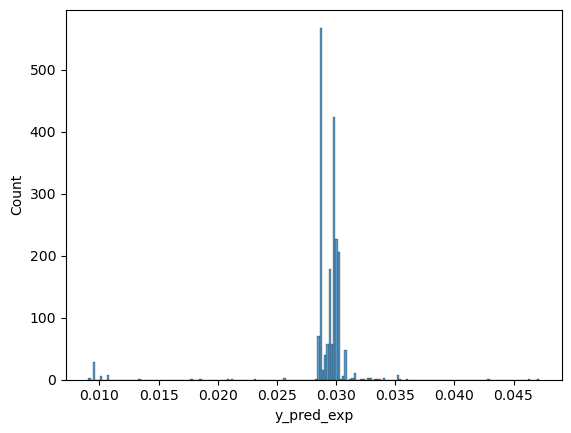

In [10]:
sns.histplot(data=test_predictions,
             x='y_pred_exp'
            )

In [8]:
len(test_predictions)

1991

In [30]:
for name in df_samples_geno.query("DB_OF_ORIGIN!='TRUST'").ROLLINGDB_ID.values:

    fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon/{name}_variants.vcf"

    assert os.path.isfile(fName)

    shutil.copy(fName, f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/{name}.vcf")

In [58]:
all_samples_MIC_models = pd.concat([pd.read_csv(fName, header=None) for fName in glob.glob("/home/sak0914/all_full_VCFs_*.csv")])

In [73]:
all_samples_MIC_models.iloc[100:].to_csv("all_samples_MIC_models.csv", header=None, index=False)

In [72]:
len(all_samples_MIC_models)/100*5/60

13.49

In [65]:
all_samples_MIC_models[1].values

array(['/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/29846/pilon/29846_variants.vcf',
       '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/30544/pilon/30544_variants.vcf',
       '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/30571/pilon/30571_variants.vcf',
       ...,
       '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/WG00050823/pilon/WG00050823_variants.vcf',
       '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/YA00086625/pilon/YA00086625_variants.vcf',
       '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/YA00086626/pilon/YA00086626_variants.vcf'],
      dtype=object)

In [24]:
df_combined = pd.read_csv(f"{out_dir}/data_for_model.csv").query("DB_OF_ORIGIN != 'Alland'")
len(df_combined)

8847

In [35]:
# for drug in ['EMB', 'ETO', 'LFX', 'MXF', 'RIF', 'PZA', 'DLM']:

#     my_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF"

#     out_dir = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}"

#     df_combined = pd.read_csv(f"{out_dir}/data_for_model.csv").query("DB_OF_ORIGIN != 'Alland'")

#     # create a new txt file of paths, adding the validation file paths to the original file
#     with open(os.path.join(out_dir, "combined_paths_for_aln.txt"), "w+") as file:
    
#         # already reset the index above and previously checked that all files exist
#         for sample in df_combined.ROLLINGDB_ID.values:
            
#             og_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/pilon/{sample}_variants.vcf"
#             new_fName = f"{my_dir}/{sample}.vcf"
            
#             if os.path.isfile(og_fName):
                
#                 if not os.path.isfile(new_fName):
#                     shutil.copy(og_fName, new_fName)
                    
#                 file.write(new_fName + "\n")

In [43]:
for drug in os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"):
    print(f"python3 data_processing/03_get_seq_alns.py -c config_files/config_{drug.lower()}.yaml")

python3 data_processing/03_get_seq_alns.py -c config_files/config_bdq.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_dlm.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_emb.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_eto.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_inh.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_lfx.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_mxf.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_pza.yaml
python3 data_processing/03_get_seq_alns.py -c config_files/config_rif.yaml


In [74]:
16088*3

48264

In [92]:
files_lst = os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF")
len(files_lst)

46958

In [4]:
# remove Alland samples from MICs
fNames = glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/*/combined_MIC.csv")

In [31]:
for fName in fNames:
    df = pd.read_csv(fName)
    drug = os.path.basename(os.path.dirname(fName))
    # df.query("DB_OF_ORIGIN=='Alland'")
    num_alland = len(df.query("DB_OF_ORIGIN=='Alland'"))
    num_WHO = len(df.query("DB_OF_ORIGIN=='WHO_catalog'"))
    print(drug, num_alland, num_WHO)
    break

BDQ 91 781


In [42]:
df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

In [44]:
df.DB_OF_ORIGIN.unique()

array(['CRyPTIC', 'farhat_internal', 'PATRIC_20191206', 'TDR_TB', 'Cox',
       'EXIT-RIF', 'JATA-KIT', 'JATA-Mongolia', 'NICD', 'NSW',
       'Wadsworth', 'CASS', 'WHO_catalog', 'IS-1007_reseqTB'],
      dtype=object)

In [15]:
df.query("DB_OF_ORIGIN=='Alland'").sort_values("BDQ_upper_bound_NORM", ascending=False)

,ROLLINGDB_ID,BDQ_PHENOTYPE_QUALITY,BDQ_upper_bound,BDQ_lower_bound,BDQ_midpoint,MEDIA_NORM,BDQ_lower_bound_NORM,BDQ_midpoint_NORM,BDQ_upper_bound_NORM,MEDIA,DB_OF_ORIGIN
10475,SAMEA5282514,NaN,NaN,NaN,NaN,NaN,0.011110,0.016665,0.022220,NaN,Alland
10483,SAMEA5282528,NaN,NaN,NaN,NaN,NaN,0.011110,0.016665,0.022220,NaN,Alland
10501,SAMEA5282341,NaN,NaN,NaN,NaN,NaN,0.005555,0.008332,0.011110,NaN,Alland
10530,SAMEA5282429,NaN,NaN,NaN,NaN,NaN,0.005555,0.008332,0.011110,NaN,Alland
10520,SAMEA5282393,NaN,NaN,NaN,NaN,NaN,0.005555,0.008332,0.011110,NaN,Alland
...,...,...,...,...,...,...,...,...,...,...,...
10480,SAMEA5282523,NaN,NaN,NaN,NaN,NaN,0.000000,0.000694,0.001389,NaN,Alland
10464,SAMEA5282479,NaN,NaN,NaN,NaN,NaN,0.000000,0.000694,0.001389,NaN,Alland
10531,SAMEA5282431,NaN,NaN,NaN,NaN,NaN,0.000000,0.000694,0.001389,NaN,Alland
10503,SAMEA5282349,NaN,NaN,NaN,NaN,NaN,0.000000,0.000694,0.001389,NaN,Alland


In [30]:
isolate_metadata.dropna(subset='OtherNames').query("OtherNames.str.contains('TDR')").query("OtherNames in ['TDR_148']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
30518,SAMEA5282376,SAMEA5282376,ERS3089644,ERR3132126,TDR,NaN,Nepal,Nepal,1,1,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,2019-05-31 11:07:43,2019-05-31 13:39:20,ERR3132126,1.0,TDR_148


In [33]:
cc_df

,antb,ABBR,m7h10,m7h11,lj,mgit960/mgit7h9,UKMYC,MYCOTB,BMD,nsw_sensititre
0,AMIKACIN,AMI,4.0,NaN,30.0,1.00,1.00,5.0,4.000,1.0
1,CAPREOMYCIN,CAP,4.0,10.000,40.0,2.50,NaN,NaN,8.000,NaN
2,CIPROFLOXACIN,CIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CYCLOSERINE,CYS,NaN,NaN,30.0,NaN,32.00,25.0,NaN,200.0
4,ETHAMBUTOL,EMB,5.0,7.500,2.0,5.00,4.00,5.0,4.000,5.0
5,ETHIONAMIDE,ETA,5.0,10.000,40.0,5.00,4.00,5.0,NaN,5.0
6,GATIFLOXACIN,GATI,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ISONIAZID,INH,0.2,0.200,0.2,0.10,0.10,0.2,0.250,0.1
8,KANAMYCIN,KAN,5.0,6.000,30.0,2.50,4.00,5.0,8.000,NaN
9,LEVOFLOXACIN,LEVO,1.0,NaN,NaN,1.50,1.00,NaN,2.000,NaN


In [39]:
cc_df

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
0,AMIKACIN,4.0,NaN,30.0,1.00,AMI,1.00
1,CAPREOMYCIN,4.0,10.000,40.0,2.50,CAP,NaN
2,CIPROFLOXACIN,NaN,NaN,NaN,NaN,CIP,NaN
3,CYCLOSERINE,NaN,NaN,30.0,NaN,CYS,NaN
4,ETHAMBUTOL,5.0,7.500,2.0,5.00,EMB,4.00
5,ETHIONAMIDE,5.0,10.000,40.0,5.00,ETA,4.00
6,GATIFLOXACIN,1.0,NaN,NaN,NaN,GATI,NaN
7,ISONIAZID,0.2,0.200,0.2,0.10,INH,0.10
8,KANAMYCIN,5.0,6.000,30.0,2.50,KAN,4.00
9,LEVOFLOXACIN,1.0,NaN,NaN,1.50,LEVO,1.00


In [36]:
cc_df_who.query("Drug=='Rifampicin'")

,Medium,Value,Drug
2,UKMYC5,0.5,Rifampicin
3,UKMYC6,0.5,Rifampicin
59,7H10,0.5,Rifampicin
61,LJ,40.0,Rifampicin
63,MGIT,0.5,Rifampicin
68,7H11,1.0,Rifampicin
77,MYCOTB,0.5,Rifampicin


In [38]:
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")

In [32]:
df.query("ROLLINGDB_ID=='SAMEA5282376'")

,ROLLINGDB_ID,BDQ_PHENOTYPE_QUALITY,BDQ_upper_bound,BDQ_lower_bound,BDQ_midpoint,MEDIA_NORM,BDQ_lower_bound_NORM,BDQ_midpoint_NORM,BDQ_upper_bound_NORM,MEDIA,DB_OF_ORIGIN
10512,SAMEA5282376,NaN,NaN,NaN,NaN,NaN,0.005555,0.008332,0.01111,NaN,Alland


In [23]:
df.query("ROLLINGDB_ID in @df_BDQ.ROLLINGDB_ID").DB_OF_ORIGIN.unique()

array(['WHO_catalog'], dtype=object)

In [20]:
df_BDQ = pd.read_csv("MIC_data/BDQ_WHO_addl_MIC.csv")

In [26]:
set(df_BDQ.ROLLINGDB_ID) - set(df.ROLLINGDB_ID)

set()

In [ ]:
all_samples = os.listdir("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data")
len(all_samples)

In [ ]:
no_VCF_samples = []
to_merge_bams = []

for sample in all_samples:

    if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/bam/{sample}.dedup.bam") and os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/bam/pass_BAMs.txt"):
        
        if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/pilon/{sample}_full.vcf.gz"):
            to_merge_bams.append(sample)
        else:
            no_VCF_samples.append(sample)

# 13239 previously
len(to_merge_bams), len(no_VCF_samples)

In [ ]:
pd.DataFrame({'A': to_merge_bams, 'B': to_merge_bams, 'FQ': 1}).to_csv("~/Mtb_Megapipe/isolates_merge_bams.tsv", sep='\t', header=None, index=False)